In [1]:
# ==============================================================================
# CELL 1 — DATA INGESTION  (reads from data/bronze/)
#
# Reads bronze tables from data/bronze/*.csv — the same way a production
# pipeline would read an ECM system extract. The data itself is procedurally
# generated (deterministic, RANDOM_SEED=42) by src/generate_source_data.py —
# re-run that script any time you want a fresh scenario; this cell just loads
# whatever it last produced.
#
# TABLES LOADED
#   fact_table                - one row per ChangeID (the change-request fact table)
#   contract_dim               - SystemCode -> Contract (seed table)
#   commissioning_milestones   - Milestone_ID -> target dates (dimension)
#   systems_master              - SystemCode -> Milestone_ID (dimension)
#   date_dim                    - full date spine 2021-2027
#   building_dim                 - 10 buildings covering the project site
#   zone_dim                     - zones within buildings
#   system_location_bridge       - SystemCode -> Building -> Zone
# ==============================================================================

import sqlite3
from datetime import date
from pathlib import Path

import pandas as pd
from IPython.display import display

conn = sqlite3.connect(":memory:")

# find project root: notebook lives in notebooks/, data is one level up
ROOT = Path.cwd()
while not (ROOT / "data" / "bronze").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SRC = ROOT / "data" / "bronze"

TABLES = [
    "fact_table", "contract_dim", "commissioning_milestones", "systems_master",
    "date_dim", "building_dim", "zone_dim", "system_location_bridge",
]

loaded = {}
for name in TABLES:
    df = pd.read_csv(SRC / f"{name}.csv")
    df.to_sql(name, conn, index=False, if_exists="replace")
    loaded[name] = df
    print(f"loaded {name:26s} {len(df):>6,} rows  <- data/bronze/{name}.csv")

fact_table     = loaded["fact_table"]
contract_dim   = loaded["contract_dim"]
df_milestones  = loaded["commissioning_milestones"]
systems_master = loaded["systems_master"]
df_date        = loaded["date_dim"]

# ── date typing (CSV round-trip loses dtype) ──────────────────────────────────
for col in ["DateOpened", "DateValidated", "DateClosed", "TargetClosureDate"]:
    fact_table[col] = pd.to_datetime(fact_table[col])
fact_table.to_sql("fact_table", conn, index=False, if_exists="replace")

df_milestones["Project_Target_Date"] = pd.to_datetime(df_milestones["Project_Target_Date"])
df_milestones.to_sql("commissioning_milestones", conn, index=False, if_exists="replace")

df_date["Date"] = pd.to_datetime(df_date["Date"])

# ── scenario "today" — must match SIM_TODAY in src/generate_source_data.py ────
SIM_TODAY    = date(2026, 2, 2)
ts_sim_today = pd.Timestamp(SIM_TODAY)
PROJECT_END  = date(2027, 12, 31)

# ── coverage checks ────────────────────────────────────────────────────────────
all_master_systems   = set(systems_master["SystemCode"])
all_contract_systems = set(contract_dim["SystemCode"])
missing_from_contract = all_master_systems - all_contract_systems
missing_from_master   = all_contract_systems - all_master_systems
if missing_from_contract:
    print(f"⚠️  WARNING: systems_master systems missing from contract_dim: {missing_from_contract}")
if missing_from_master:
    print(f"⚠️  WARNING: contract_dim systems missing from systems_master: {missing_from_master}")
if not missing_from_contract and not missing_from_master:
    print(f"✅ Coverage check passed: contract_dim and systems_master agree on {len(all_master_systems)} systems")

unlocated = all_master_systems - set(loaded["system_location_bridge"]["SystemCode"])
if unlocated:
    print(f"⚠️  WARNING: {len(unlocated)} systems in systems_master have no location: {unlocated}")
else:
    print("✅ All systems have at least one location assigned")

# ── quality checks ─────────────────────────────────────────────────────────────
print(f"\n✅ fact_table: {len(fact_table):,} records")
print(f"   SIM_TODAY : {SIM_TODAY}")
print(f"   Systems   : {contract_dim['SystemCode'].nunique()} across {contract_dim['Contract'].nunique()} contracts")

print("\n── Status split ──")
print(fact_table["Status"].value_counts().to_string())

print("\n── DateOpened spread ──")
print(f"Min: {fact_table['DateOpened'].min().date()}  "
      f"Max: {fact_table['DateOpened'].max().date()}")

print("\n── AssumedMilestone distribution ──")
print(fact_table.groupby("AssumedMilestone")["ChangeID"].count().to_string())
print("\nDriving milestone will be derived below from systems_master.")

display(fact_table.head(10))


loaded fact_table                 15,000 rows  <- data/bronze/fact_table.csv
loaded contract_dim                   26 rows  <- data/bronze/contract_dim.csv
loaded commissioning_milestones        4 rows  <- data/bronze/commissioning_milestones.csv
loaded systems_master                 26 rows  <- data/bronze/systems_master.csv
loaded date_dim                    2,556 rows  <- data/bronze/date_dim.csv
loaded building_dim                   10 rows  <- data/bronze/building_dim.csv
loaded zone_dim                       16 rows  <- data/bronze/zone_dim.csv
loaded system_location_bridge         36 rows  <- data/bronze/system_location_bridge.csv


✅ Coverage check passed: contract_dim and systems_master agree on 26 systems
✅ All systems have at least one location assigned

✅ fact_table: 15,000 records
   SIM_TODAY : 2026-02-02
   Systems   : 26 across 6 contracts

── Status split ──
Status
Closed       14292
Validated      605
Open           103

── DateOpened spread ──
Min: 2023-01-01  Max: 2025-12-31

── AssumedMilestone distribution ──
AssumedMilestone
M1    2994
M2    4498
M3    4451
M4    3057

Driving milestone will be derived below from systems_master.


,ChangeID,AssumedMilestone,Level,DateOpened,DateValidated,DateClosed,TargetClosureDate,Status,SystemsImpacted,Reason,PotentialConsequences
0,C00001,M2,3,2023-11-24,2023-12-03,2024-02-19,2024-01-23,Closed,"DEF, ABC",Client Requirement Change,Equipment Replacement Required
1,C00002,M1,3,2023-05-06,2023-05-28,2023-11-08,2023-06-17,Closed,"LMN, GHP",Material Availability Issue,Documentary Only
2,C00003,M1,3,2023-10-07,2023-10-21,2024-07-10,2023-12-06,Closed,ABB,Client Requirement Change,Installation Modification Required
3,C00004,M1,3,2023-01-17,2023-01-18,2023-01-20,2023-02-28,Closed,ABC,Vendor Deviation,Documentary Only
4,C00005,M3,3,2024-10-14,2024-11-06,2025-05-14,2024-11-25,Closed,XYZ,Late Engineering Input,Documentary Only
5,C00006,M3,3,2024-10-06,2024-10-07,2024-10-10,2024-11-17,Closed,"FGH, LMN",Design Optimization,Documentary Only
6,C00007,M3,2,2024-03-22,2024-03-29,2024-07-03,2024-07-25,Closed,"XYA, FGH, VWX",Risk Mitigation Measure,Documentary Only
7,C00008,M4,2,2025-06-22,2025-07-04,2025-10-11,2025-10-25,Closed,"DEF, ABB",Late Engineering Input,Documentary Only
8,C00009,M1,2,2023-06-26,2023-07-11,2023-09-03,2023-10-29,Closed,"TUV, PQR, DEH",Site Condition Variation,Documentary Only
9,C00010,M3,3,2024-10-01,2024-10-04,2024-10-05,2024-11-12,Closed,"DEF, CDE",Client Requirement Change,Documentary Only


In [2]:
# ==============================================================================
# CELL 3 — BRIDGE TABLE (fact_table <-> systems_master)
# ==============================================================================

def build_bridge(df):
    """
    Normalises SystemsImpacted into a bridge table.
    Handles comma-separated lists and slash-expansion.

    Slash expansion uses base[:-1] as prefix (not hardcoded [:2]),
    which correctly handles both 2-char and 3-char system code roots.
      'ABC/D' -> base='ABC', prefix='AB' -> ['ABC', 'ABD']  correct
      'GHP/X' -> base='GHP', prefix='GH' -> ['GHP', 'GHX']  correct
    """
    bridge = df[['ChangeID', 'SystemsImpacted']].copy()
    bridge['SystemCode'] = bridge['SystemsImpacted'].str.split(',')
    bridge = bridge.explode('SystemCode')
    bridge['SystemCode'] = bridge['SystemCode'].str.strip()

    def expand_slash(s):
        if not isinstance(s, str):
            return [s]
        s = s.strip()
        if '/' not in s:
            return [s]
        parts  = s.split('/')
        base   = parts[0]
        prefix = base[:-1]  # Correct prefix: all chars except the last
        return [base] + [prefix + p.strip() for p in parts[1:]]

    bridge['SystemCode'] = bridge['SystemCode'].apply(expand_slash)
    bridge = bridge.explode('SystemCode')
    bridge['SystemCode'] = bridge['SystemCode'].str.strip()
    return bridge[['ChangeID', 'SystemCode']].drop_duplicates()

systems_bridge = build_bridge(fact_table)
systems_bridge.to_sql('systems_bridge', conn, index=False, if_exists='replace')

# --- Orphan Check ---
orphaned = systems_bridge[~systems_bridge['SystemCode'].isin(systems_master['SystemCode'])]
if len(orphaned) > 0:
    print(f'⚠️  WARNING: {len(orphaned)} orphaned bridge rows (SystemCode not in systems_master):')
    print(orphaned['SystemCode'].value_counts())
else:
    print('✅ Orphan check passed: all bridge SystemCodes resolve to systems_master')

print(f'✅ Cell 3: Bridge table normalised ({len(systems_bridge):,} relational rows)')

systems_bridge.head(10)

✅ Orphan check passed: all bridge SystemCodes resolve to systems_master
✅ Cell 3: Bridge table normalised (26,957 relational rows)


,ChangeID,SystemCode
0,C00001,DEF
0,C00001,ABC
1,C00002,LMN
1,C00002,GHP
2,C00003,ABB
3,C00004,ABC
4,C00005,XYZ
5,C00006,FGH
5,C00006,LMN
6,C00007,XYA


In [3]:
# ==============================================================================
# CELL 4 — ENRICHMENT QUERY
# ==============================================================================

query = f"""
WITH

-- CTE 1: Classify each change as documentary-only (0) or physical (1)
ImpactClassification AS (
    SELECT
        ChangeID,
        CASE
            WHEN PotentialConsequences IN (
                'Documentary Only',
                'Drawing Update Only',
                'Specification Clarification',
                'Calculation Revision Only',
                'Procedure Update Only'
            ) THEN 0
            ELSE 1
        END AS Physical_Impacts
    FROM fact_table
),

-- CTE 2: Pick the earliest milestone deadline per change (The "Driving" Milestone)
MilestoneMapping AS (
    SELECT
        sb.ChangeID,
        sb.SystemCode,
        sm.Milestone_ID,
        cm.Milestone_Name,
        cm.Project_Target_Date AS Milestone_Deadline,
        ROW_NUMBER() OVER (
            PARTITION BY sb.ChangeID
            ORDER BY cm.Project_Target_Date ASC
        ) AS Rank
    FROM systems_bridge sb
    LEFT JOIN systems_master sm ON sb.SystemCode = sm.SystemCode
    LEFT JOIN commissioning_milestones cm ON sm.Milestone_ID = cm.Milestone_ID
)

SELECT
    f.*,
    ic.Physical_Impacts,

    -- Milestone fields
    mm.SystemCode         AS Driving_System,
    mm.Milestone_ID       AS Driving_Milestone,
    mm.Milestone_Name,
    mm.Milestone_Deadline AS Milestone_Need_Date,

    -- Define Actual_Need_Date (Internal engineering buffer)
    CASE
        WHEN ic.Physical_Impacts = 0
        THEN date(mm.Milestone_Deadline, '-3 months')
        ELSE date(mm.Milestone_Deadline, '-1 year')
    END AS Actual_Need_Date,

    -- Timing metrics
    CASE
        WHEN f.DateClosed IS NOT NULL
        THEN (julianday(f.DateClosed) - julianday(f.DateOpened))
        ELSE NULL
    END AS Days_to_Close,

    CASE
        WHEN f.DateClosed IS NULL
        THEN (julianday('{SIM_TODAY}') - julianday(f.DateOpened))
        ELSE NULL
    END AS Current_Age_Days,

    CASE
        WHEN f.DateClosed IS NULL
        THEN (
            julianday(
                CASE
                    WHEN ic.Physical_Impacts = 0
                    THEN date(mm.Milestone_Deadline, '-3 months')
                    ELSE date(mm.Milestone_Deadline, '-1 year')
                END
            ) - julianday('{SIM_TODAY}')
        )
        ELSE NULL
    END AS Days_Until_Need,

    -- Days Overdue = DateClosed - Actual_Need_Date
    -- Negative = closed BEFORE need date (on track)
    -- Positive = closed AFTER need date (delayed)
    CASE
        WHEN f.DateClosed IS NOT NULL
        THEN (
            julianday(f.DateClosed) -
            julianday(
                CASE
                    WHEN ic.Physical_Impacts = 0
                    THEN date(mm.Milestone_Deadline, '-3 months')
                    ELSE date(mm.Milestone_Deadline, '-1 year')
                END
            )
        )
        ELSE NULL
    END AS Days_Overdue

FROM fact_table f
LEFT JOIN ImpactClassification ic ON f.ChangeID = ic.ChangeID
LEFT JOIN MilestoneMapping mm
    ON f.ChangeID = mm.ChangeID
    AND mm.Rank = 1
"""

fact_enriched = pd.read_sql(query, conn)

# ── TYPE CASTING ──────────────────────────────────────────────────────────────
date_cols = ['DateOpened', 'DateClosed', 'DateValidated',
             'TargetClosureDate', 'Milestone_Need_Date', 'Actual_Need_Date']

for col in date_cols:
    fact_enriched[col] = pd.to_datetime(fact_enriched[col], errors='coerce')

fact_enriched['Physical_Impacts'] = fact_enriched['Physical_Impacts'].astype(bool)
fact_enriched = fact_enriched.sort_values(by='DateOpened', ascending=False)

# ── FIX: WRITE fact_enriched TO SQLite BEFORE location query ─────────────────
# location_explode_query references fact_enriched as a SQL table.
# Must be written here before that query runs.
fact_enriched.to_sql('fact_enriched', conn, index=False, if_exists='replace')
print(f'✅ fact_enriched written to SQLite: {len(fact_enriched):,} rows')

# ── EXPLODED LOCATION TABLE ───────────────────────────────────────────────────
# Grain: ChangeID × SystemCode × Building × Zone
# Anchored on fact_enriched so Current_Age_Days and Days_to_Close
# are available for downstream building and zone analysis.

location_explode_query = """
    SELECT
        f.ChangeID,
        f.Status,
        f.Level,
        f.Physical_Impacts,
        f.AssumedMilestone,
        f.DateOpened,
        f.DateClosed,
        f.Current_Age_Days,
        f.Days_to_Close,
        sb.SystemCode,
        slb.Building_ID,
        bd.Building_Name,
        bd.Building_Type,
        slb.Zone_ID,
        zd.Zone_Name,
        zd.Zone_Type
    FROM fact_enriched f
    LEFT JOIN systems_bridge          sb  ON f.ChangeID   = sb.ChangeID
    LEFT JOIN system_location_bridge  slb ON sb.SystemCode = slb.SystemCode
    LEFT JOIN building_dim            bd  ON slb.Building_ID = bd.Building_ID
    LEFT JOIN zone_dim                zd  ON slb.Zone_ID    = zd.Zone_ID
"""

fact_location_exploded = pd.read_sql(location_explode_query, conn)

# Cast dates
fact_location_exploded['DateOpened'] = pd.to_datetime(fact_location_exploded['DateOpened'])
fact_location_exploded['DateClosed'] = pd.to_datetime(fact_location_exploded['DateClosed'])

# Write exploded table to SQLite
fact_location_exploded.to_sql('fact_location_exploded', conn, index=False, if_exists='replace')

# ── persist silver layer ─────────────────────────────────────────────────────
import sys
sys.path.insert(0, str(ROOT / "src"))
from lineage import write_layer

write_layer(fact_enriched, "fact_enriched", ROOT / "data" / "silver",
            sources=["fact_table", "contract_dim", "commissioning_milestones", "systems_master"])
write_layer(fact_location_exploded, "fact_location_exploded", ROOT / "data" / "silver",
            sources=["fact_enriched", "system_location_bridge", "building_dim", "zone_dim"])

# ── POST-ENRICHMENT CHECKS ────────────────────────────────────────────────────
null_driving  = fact_enriched['Driving_Milestone'].isna().sum()
mismatch_rate = (fact_enriched['AssumedMilestone'] != fact_enriched['Driving_Milestone']).mean()
overdue_count = len(fact_enriched[fact_enriched['Days_Overdue'] > 0])

print(f'✅ Cell 4: Enrichment complete | SIM_TODAY = {SIM_TODAY}')
print(f'   Items physically overdue (Closed > Need Date) : {overdue_count:,}')
print(f'   Assumed vs Driving mismatch rate              : {mismatch_rate:.1%}')
print(f'   Exploded location rows                        : {len(fact_location_exploded):,} '
      f'(vs {len(fact_enriched):,} base)')
print(f'   fact_location_exploded columns                : {fact_location_exploded.columns.tolist()}')

if null_driving > 0:
    print(f'⚠️  WARNING: {null_driving} records have no Driving_Milestone assignment')

display(fact_enriched.head(5))

display(fact_location_exploded.head(5))

✅ fact_enriched written to SQLite: 15,000 rows


wrote fact_enriched          15,000 rows -> data/silver/fact_enriched.parquet  (from: fact_table, contract_dim, commissioning_milestones, systems_master)
wrote fact_location_exploded 37,435 rows -> data/silver/fact_location_exploded.parquet  (from: fact_enriched, system_location_bridge, building_dim, zone_dim)
✅ Cell 4: Enrichment complete | SIM_TODAY = 2026-02-02
   Items physically overdue (Closed > Need Date) : 671
   Assumed vs Driving mismatch rate              : 74.5%
   Exploded location rows                        : 37,435 (vs 15,000 base)
   fact_location_exploded columns                : ['ChangeID', 'Status', 'Level', 'Physical_Impacts', 'AssumedMilestone', 'DateOpened', 'DateClosed', 'Current_Age_Days', 'Days_to_Close', 'SystemCode', 'Building_ID', 'Building_Name', 'Building_Type', 'Zone_ID', 'Zone_Name', 'Zone_Type']


,ChangeID,AssumedMilestone,Level,DateOpened,DateValidated,DateClosed,TargetClosureDate,Status,SystemsImpacted,Reason,...,Physical_Impacts,Driving_System,Driving_Milestone,Milestone_Name,Milestone_Need_Date,Actual_Need_Date,Days_to_Close,Current_Age_Days,Days_Until_Need,Days_Overdue
4794,C04795,M4,3,2025-12-31,2026-01-01,2026-01-01,2026-02-11,Closed,"XYB, DEH",Site Condition Variation,...,False,XYB,M3,Verification,2026-12-30,2026-09-30,1.0,NaN,NaN,-272.0
2168,C02169,M4,3,2025-12-31,2026-01-19,2026-01-28,2026-02-11,Closed,NOP,Client Requirement Change,...,False,NOP,M2,Initial Testing,2026-06-15,2026-03-15,28.0,NaN,NaN,-46.0
3722,C03723,M4,3,2025-12-31,2026-01-07,2026-02-01,2026-02-11,Closed,NOP,Calculation Revision,...,False,NOP,M2,Initial Testing,2026-06-15,2026-03-15,32.0,NaN,NaN,-42.0
1444,C01445,M4,3,2025-12-31,2026-01-15,NaT,2026-02-11,Validated,QRS,Scope Clarification,...,False,QRS,M2,Initial Testing,2026-06-15,2026-03-15,NaN,33.0,41.0,NaN
3486,C03487,M4,3,2025-12-31,NaT,NaT,2026-03-01,Open,DEH,Design Optimization,...,True,DEH,M3,Verification,2026-12-30,2025-12-30,NaN,33.0,-34.0,NaN


,ChangeID,Status,Level,Physical_Impacts,AssumedMilestone,DateOpened,DateClosed,Current_Age_Days,Days_to_Close,SystemCode,Building_ID,Building_Name,Building_Type,Zone_ID,Zone_Name,Zone_Type
0,C04795,Closed,3,0,M4,2025-12-31,2026-01-01,NaN,1.0,DEH,B07,Water Treatment Plant,Civil,B07-Z2,Filter Hall,Operational
1,C04795,Closed,3,0,M4,2025-12-31,2026-01-01,NaN,1.0,XYB,B02,Turbine Hall,Generation,B02-Z3,Feed Water Area,Operational
2,C02169,Closed,3,0,M4,2025-12-31,2026-01-28,NaN,28.0,NOP,B02,Turbine Hall,Generation,B02-Z1,Turbine Deck,Operational
3,C03723,Closed,3,0,M4,2025-12-31,2026-02-01,NaN,32.0,NOP,B02,Turbine Hall,Generation,B02-Z1,Turbine Deck,Operational
4,C01445,Validated,3,0,M4,2025-12-31,NaT,33.0,NaN,QRS,B05,Auxiliary Building,Auxiliary,B05-Z1,HVAC Plant Room,Operational


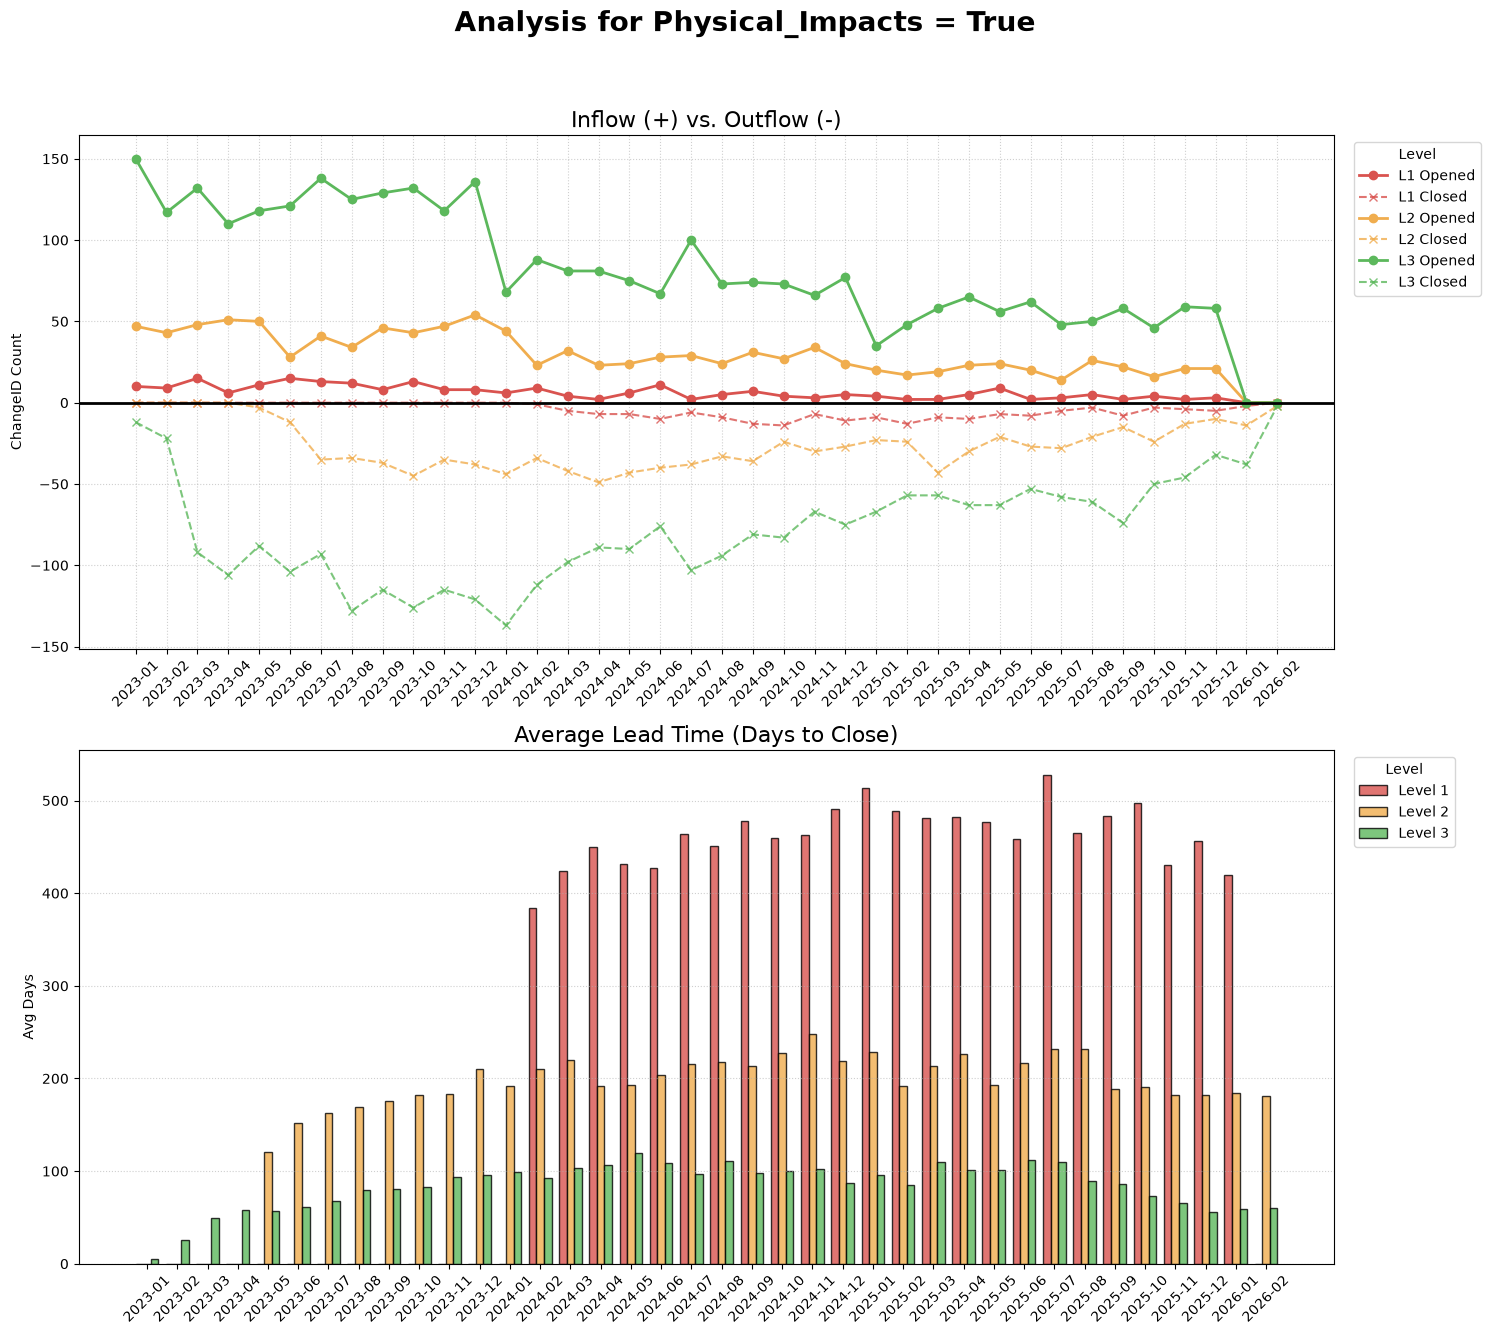

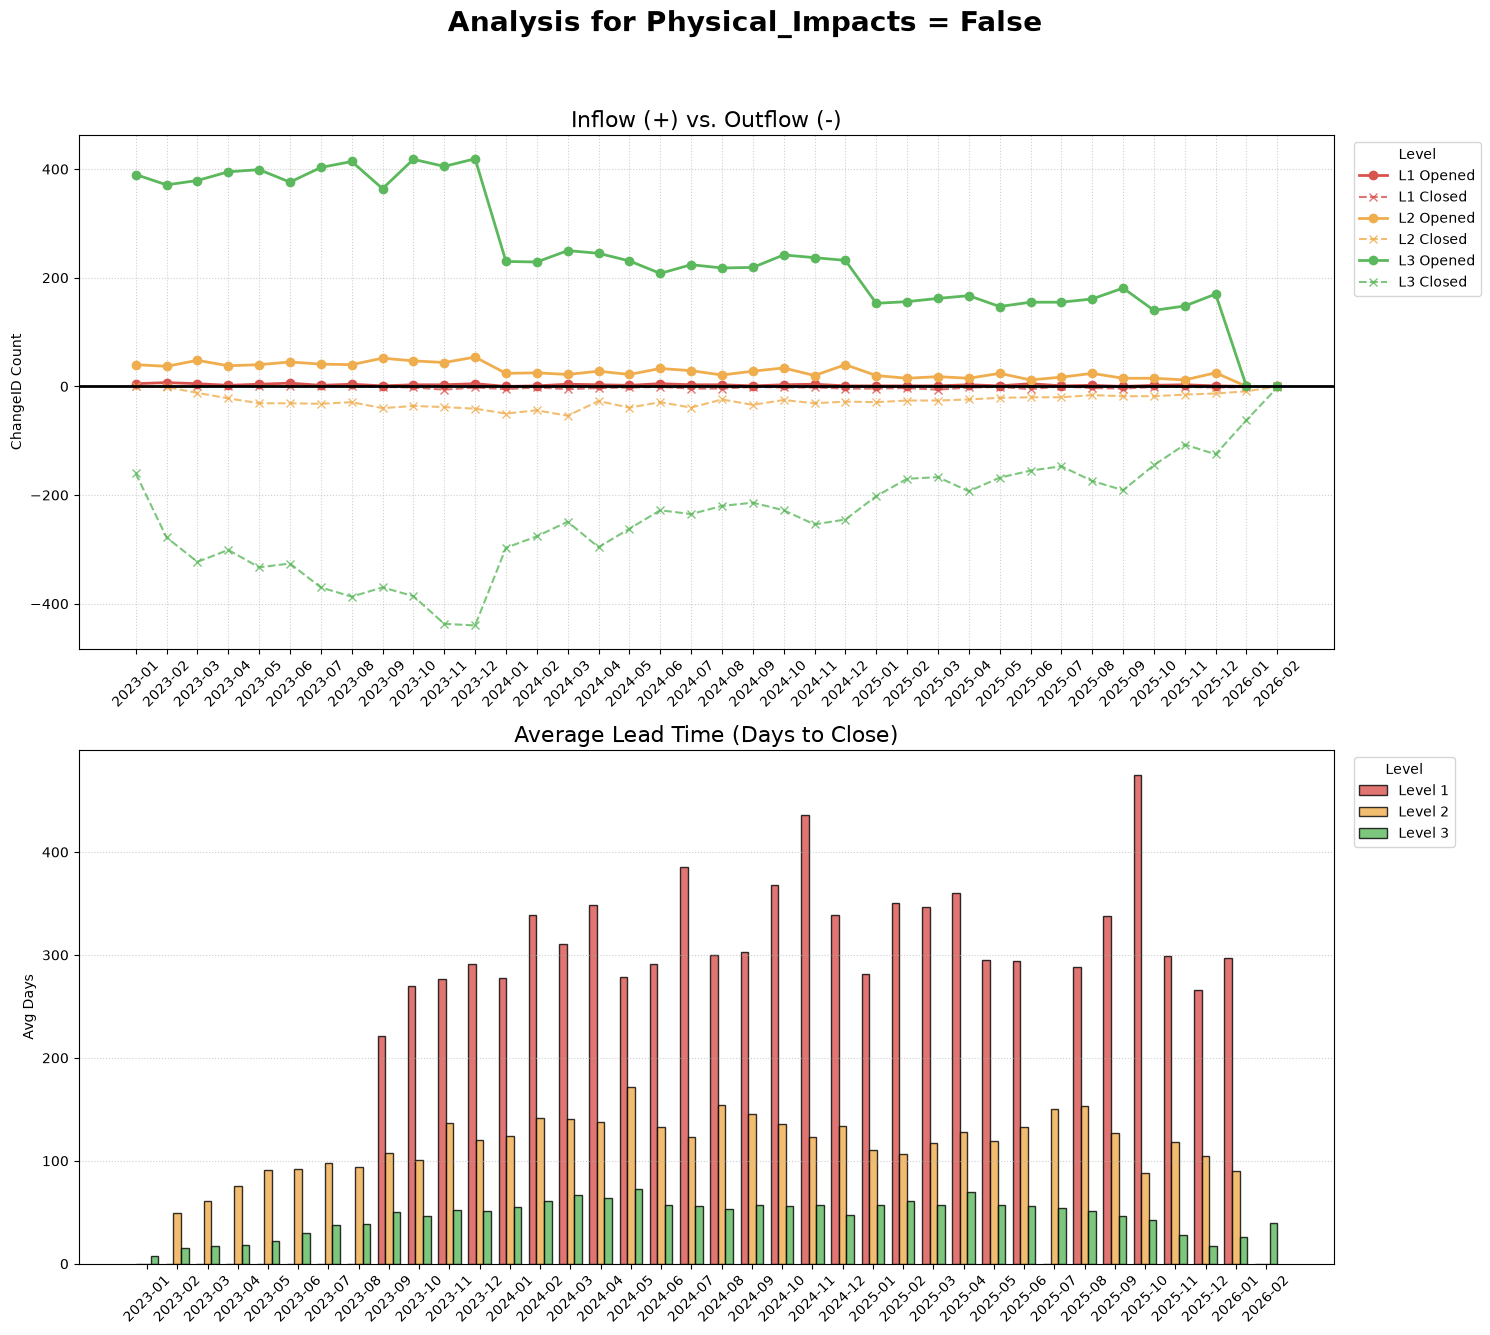

In [4]:
# ==============================================================================
# CELL 5 — INFLOW & OUTFLOW. AVERAGE TIME TO CLOSE VISUALS

import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 

colors = {1: '#d9534f', 2: '#f0ad4e', 3: '#5cb85c'} 

for impact_status in [True, False]: 
    df_subset = fact_enriched[fact_enriched['Physical_Impacts'] == impact_status].copy() 
     
    df_subset['Month_Open'] = df_subset['DateOpened'].dt.to_period('M').astype(str) 
    opened_counts = df_subset.groupby(['Month_Open', 'Level'])['ChangeID'].nunique().unstack(fill_value=0) 

    df_closed = df_subset[df_subset['Status'] == 'Closed'].copy() 
    df_closed['Month_Closed'] = df_closed['DateClosed'].dt.to_period('M').astype(str) 
    closed_counts = df_closed.groupby(['Month_Closed', 'Level'])['ChangeID'].nunique().unstack(fill_value=0) 

    monthly_avg_days = df_closed.groupby(['Month_Closed', 'Level'])['Days_to_Close'].mean().unstack(fill_value=0) 

    all_months = sorted(list(set(opened_counts.index) | set(closed_counts.index))) 
    opened_counts = opened_counts.reindex(all_months, fill_value=0) 
    closed_counts = closed_counts.reindex(all_months, fill_value=0) 
    monthly_avg_days = monthly_avg_days.reindex(all_months, fill_value=0) 

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14)) 
    fig.suptitle(f"Analysis for Physical_Impacts = {impact_status}", fontsize=20, fontweight='bold', y=0.98) 

    # CHART 1: MONTHLY INFLOW (+) VS. OUTFLOW (-) 
    for lvl in [1, 2, 3]: 
        if lvl in opened_counts.columns: 
            ax1.plot(all_months, opened_counts[lvl], marker='o', label=f'L{lvl} Opened',  
                     color=colors[lvl], linestyle='-', linewidth=2) 
        if lvl in closed_counts.columns: 
            ax1.plot(all_months, -closed_counts[lvl], marker='x', label=f'L{lvl} Closed',  
                     color=colors[lvl], linestyle='--', alpha=0.8) 

    ax1.axhline(0, color='black', linewidth=2) 
    ax1.set_title("Inflow (+) vs. Outflow (-)", fontsize=16) 
    ax1.set_ylabel("ChangeID Count") 
    ax1.legend(title="Level", bbox_to_anchor=(1.01, 1), loc='upper left') 
    ax1.grid(True, linestyle=':', alpha=0.6) 
    ax1.tick_params(axis='x', rotation=45) 

    # CHART 2: AVERAGE CYCLE TIME 
    x = np.arange(len(all_months)) 
    width = 0.25 

    for i, lvl in enumerate([1, 2, 3]): 
        data = monthly_avg_days[lvl] if lvl in monthly_avg_days.columns else [0] * len(all_months) 
        ax2.bar(x + (i - 1) * width, data, width, label=f'Level {lvl}',  
                color=colors[lvl], edgecolor='black', alpha=0.8) 

    ax2.set_title("Average Lead Time (Days to Close)", fontsize=16) 
    ax2.set_ylabel("Avg Days") 
    ax2.set_xticks(x) 
    ax2.set_xticklabels(all_months, rotation=45) 
    ax2.legend(title="Level", bbox_to_anchor=(1.01, 1), loc='upper left') 
    ax2.grid(axis='y', linestyle=':', alpha=0.6) 

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()

In [5]:
# ==============================================================================
# CELL 6 — BURNDOWN PREPARATION

# 1. Define the timeline from your date dimension
# Assuming df_date was created in Cell 2
start_date = pd.to_datetime("2023-01-01")
end_date = pd.to_datetime(PROJECT_END)   # from Cell 1 — single source of truth
timeline = pd.date_range(start=start_date, end=end_date, freq='D')

def get_burndown_data(df, date_col_open, date_col_close, grouping_col):
    # Create Inflow (+1)
    inflow = df[[date_col_open, grouping_col]].copy()
    inflow['Delta'] = 1
    inflow = inflow.rename(columns={date_col_open: 'Date'})
    
    # Create Outflow (-1)
    outflow = df[df[date_col_close].notna()][[date_col_close, grouping_col]].copy()
    outflow['Delta'] = -1
    outflow = outflow.rename(columns={date_col_close: 'Date'})
    
    # Combine and Group
    combined = pd.concat([inflow, outflow])
    combined['Date'] = pd.to_datetime(combined['Date']).dt.normalize()
    
    # Pivot to get Dates as rows and Milestones as columns
    daily_changes = combined.groupby(['Date', grouping_col])['Delta'].sum().unstack(fill_value=0)
    
    # Reindex to the full timeline and Cumulatively Sum
    burndown = daily_changes.reindex(timeline, fill_value=0).cumsum()
    return burndown

# Generate the two datasets
burndown_assumed = get_burndown_data(fact_enriched, 'DateOpened', 'DateClosed', 'AssumedMilestone')
burndown_need = get_burndown_data(fact_enriched, 'DateOpened', 'DateClosed', 'Driving_Milestone')

print("✅ Burndown datasets generated.")

✅ Burndown datasets generated.


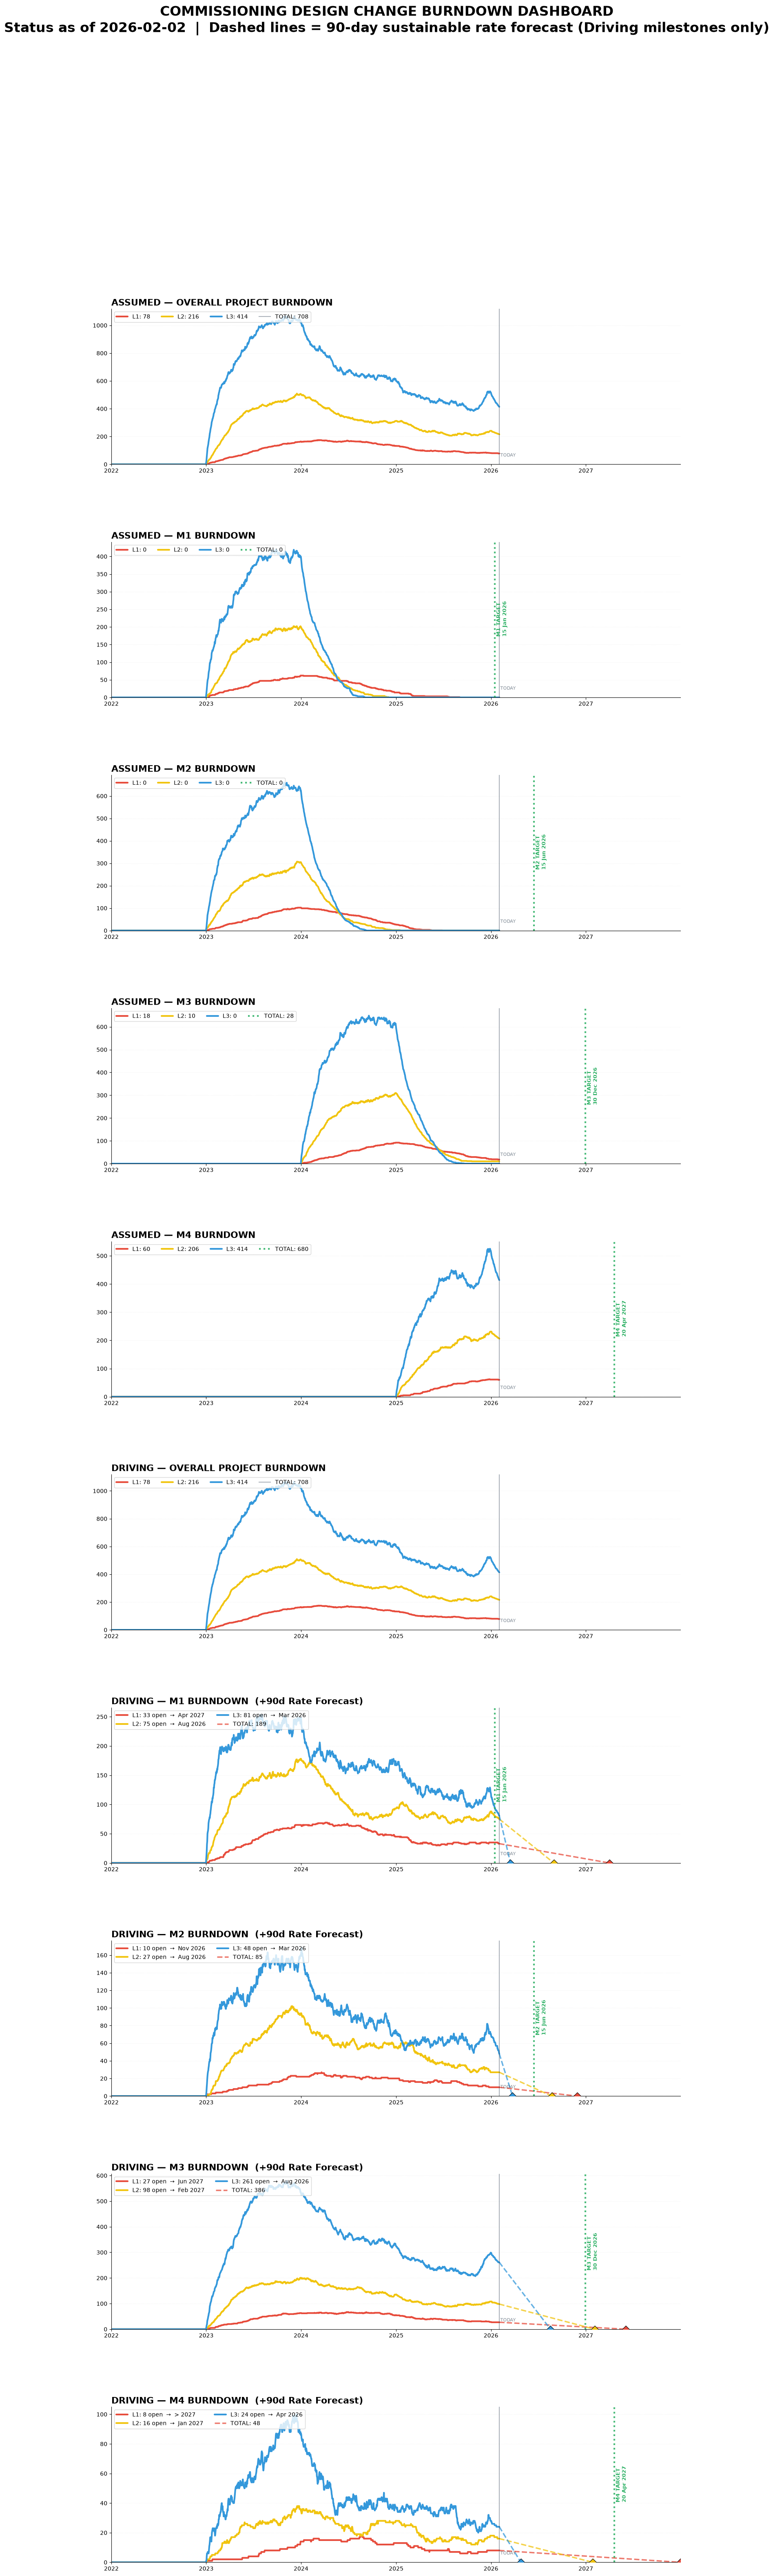

In [6]:
# ==============================================================================
# CELL 7 — BURNDOWN DASHBOARD
# 10 charts: Assumed Overall + M1–M4, then Driving Overall + M1–M4
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# ── CONFIG ────────────────────────────────────────────────────────────────────
FULL_START    = pd.to_datetime('2022-01-01')
FULL_END      = pd.to_datetime('2027-12-31')
CUTOFF_DATE   = ts_sim_today                        # single source of truth from Cell 1
full_timeline = pd.date_range(start=FULL_START, end=FULL_END, freq='D')
LEVEL_COLORS  = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}

# Load milestone target dates — IDs are already 'M1','M2' etc, no remapping needed
ms_targets = pd.read_sql(
    "SELECT Milestone_ID, Project_Target_Date FROM commissioning_milestones", conn
)
ms_targets['Project_Target_Date'] = pd.to_datetime(ms_targets['Project_Target_Date'])


# ── FUNCTION 1: ACTUAL BURNDOWN ───────────────────────────────────────────────
def get_line_burndown(df, milestone_col, milestone_val=None):
    """
    Calculates cumulative open items per level up to CUTOFF_DATE.
    Includes opening balance for items opened before FULL_START.
    Lines are masked to NaN after CUTOFF_DATE so they stop at today.
    """
    work_df = df[df[milestone_col] == milestone_val].copy() if milestone_val else df.copy()

    if work_df.empty:
        return pd.DataFrame(0, index=full_timeline, columns=[1, 2, 3])

    # Opening balance: items opened before chart start, still open at chart start
    opening_balance = {
        lvl: len(work_df[
            (work_df['Level'] == lvl) &
            (work_df['DateOpened'] < FULL_START) &
            ((work_df['DateClosed'].isna()) | (work_df['DateClosed'] >= FULL_START))
        ])
        for lvl in [1, 2, 3]
    }

    opens = (work_df[(work_df['DateOpened'] >= FULL_START) & (work_df['DateOpened'] <= CUTOFF_DATE)]
             [['DateOpened', 'Level']].rename(columns={'DateOpened': 'EventDate'}).copy())
    opens['Delta'] = 1

    closes = (work_df[(work_df['DateClosed'].notna()) &
                      (work_df['DateClosed'] >= FULL_START) &
                      (work_df['DateClosed'] <= CUTOFF_DATE)]
              [['DateClosed', 'Level']].rename(columns={'DateClosed': 'EventDate'}).copy())
    closes['Delta'] = -1

    combined = pd.concat([opens, closes])
    combined['EventDate'] = pd.to_datetime(combined['EventDate']).dt.normalize()

    daily = combined.groupby(['EventDate', 'Level'])['Delta'].sum().unstack(level=1, fill_value=0)
    for lvl in [1, 2, 3]:
        if lvl not in daily.columns:
            daily[lvl] = 0

    series = daily.reindex(full_timeline, fill_value=0).cumsum()
    for lvl in [1, 2, 3]:
        series[lvl] = series[lvl] + opening_balance[lvl]

    # Mask future dates — actual line stops at today
    series.loc[series.index > CUTOFF_DATE] = np.nan
    return series[[1, 2, 3]]


# ── FUNCTION 2: 90-DAY FORECAST ───────────────────────────────────────────────
def get_90day_forecast(work_df, current_counts):
    """
    For each level, projects a linear decline from the current open count to zero.
    Velocity is derived from closures in the 90 days immediately before CUTOFF_DATE.

    Returns dict: {level: pd.Series(index=forecast_dates, values=open_count)}

    Design decisions:
      - Forecast line starts at CUTOFF_DATE for visual continuity with actual line
      - Velocity = closures in last 90 days / 90  (closures per day)
      - Floor velocity 0.01/day (1 closure per 100 days) prevents infinite lines
        for systems with zero recent closures — they get a very shallow slope
      - Forecast capped at FULL_END so line stays within chart bounds
      - If current backlog is already zero, returns a single point at zero
    """
    lookback_start = CUTOFF_DATE - pd.Timedelta(days=90)
    forecasts      = {}

    for lvl in [1, 2, 3]:
        backlog = int(current_counts.get(lvl, 0))

        if backlog <= 0:
            forecasts[lvl] = pd.Series([0], index=[CUTOFF_DATE])
            continue

        # Closures in last 90 days for this level
        closed_in_window = work_df[
            (work_df['Level'] == lvl) &
            (work_df['DateClosed'].notna()) &
            (work_df['DateClosed'] >= lookback_start) &
            (work_df['DateClosed'] <= CUTOFF_DATE)
        ]
        velocity = len(closed_in_window) / 90          # closures per day
        velocity = max(velocity, 0.01)                  # floor — never infinite

        days_to_zero   = int(backlog / velocity)
        forecast_end   = min(CUTOFF_DATE + pd.Timedelta(days=days_to_zero), FULL_END)
        forecast_dates = pd.date_range(start=CUTOFF_DATE, end=forecast_end, freq='D')

        # Linear decline: backlog → 0
        forecast_values = np.linspace(backlog, 0, len(forecast_dates))
        forecasts[lvl]  = pd.Series(forecast_values, index=forecast_dates)

    return forecasts


# ── DASHBOARD ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(10, 1, figsize=(18, 65), sharex=False)
milestones = ['M1', 'M2', 'M3', 'M4']

for i in range(10):
    ax = axes[i]

    # Chart index → milestone and type
    # 0: Assumed Overall  |  1-4: Assumed M1-M4
    # 5: Driving Overall  |  6-9: Driving M1-M4  ← forecast applied here
    is_driving   = i >= 5
    m_idx        = (i - 1) if not is_driving else (i - 6)   # -1 = Overall
    m_val        = milestones[m_idx] if m_idx >= 0 else None
    m_col        = 'Driving_Milestone' if is_driving else 'AssumedMilestone'
    apply_forecast = is_driving and m_val is not None      # charts 6-9 only

    # ── Actual data ──
    data      = get_line_burndown(fact_enriched, m_col, m_val)
    snap_vals = data.loc[CUTOFF_DATE] if CUTOFF_DATE in data.index else pd.Series({1:0,2:0,3:0})

    # ── Plot actual lines (solid) ──
    for lvl in [1, 2, 3]:
        ax.plot(data.index, data[lvl],
                color=LEVEL_COLORS[lvl], lw=3,
                label=f'L{lvl} Actual',
                solid_capstyle='round')

    # ── Forecast extension (dashed) — Driving M1–M4 only ──
    if apply_forecast:
        scope_df  = fact_enriched[fact_enriched[m_col] == m_val].copy()
        forecasts = get_90day_forecast(scope_df, snap_vals)

        for lvl in [1, 2, 3]:
            f_series = forecasts[lvl]

            if len(f_series) <= 1:
                continue

            # Dashed forecast line
            ax.plot(f_series.index, f_series.values,
                    color=LEVEL_COLORS[lvl],
                    lw=2.5,
                    linestyle='--',
                    alpha=0.75,
                    label=f'L{lvl} Forecast')

            # Diamond marker at predicted zero date
            ax.scatter(f_series.index[-1], 0,
                       color=LEVEL_COLORS[lvl],
                       marker='D',
                       s=80,
                       edgecolors='black',
                       linewidths=0.8,
                       zorder=6,
                       label=f'L{lvl} clears {f_series.index[-1].strftime("%b %Y")}')

    # ── Milestone target line ──
    if m_val:
        target_row = ms_targets[ms_targets['Milestone_ID'] == m_val]
        if not target_row.empty:
            t_date = target_row['Project_Target_Date'].iloc[0]

            # Use data max for stable y-position — not ax.get_ylim() which is
            # unstable before tight_layout has run
            data_max = data[[1, 2, 3]].max().max()
            y_text   = max(data_max * 0.65, 10)

            ax.axvline(t_date, color='#27ae60', linestyle=':', lw=3, alpha=0.85)
            ax.text(t_date + pd.Timedelta(days=4), y_text,
                    f'{m_val} TARGET\n{t_date.strftime("%d %b %Y")}',
                    color='#27ae60', fontweight='bold',
                    fontsize=9, va='top', rotation=90)

    # ── Today line ──
    ax.axvline(CUTOFF_DATE, color='#2c3e50', linestyle='-', lw=1.5, alpha=0.4)
    ax.text(CUTOFF_DATE + pd.Timedelta(days=4),
            ax.get_ylim()[1] * 0.05 if ax.get_ylim()[1] > 0 else 1,
            'TODAY', color='#2c3e50', fontsize=8, alpha=0.6)

    # ── Legend with current inventory counts ──
    l1 = int(snap_vals.get(1, 0))
    l2 = int(snap_vals.get(2, 0))
    l3 = int(snap_vals.get(3, 0))

    if apply_forecast:
        # For forecast charts show predicted clear dates alongside counts
        f = get_90day_forecast(
            fact_enriched[fact_enriched[m_col] == m_val],
            snap_vals
        ) if apply_forecast else {}

        def clear_label(lvl):
            s = f.get(lvl, pd.Series([0], index=[CUTOFF_DATE]))
            if len(s) <= 1: return 'Already clear'
            end = s.index[-1]
            if end >= FULL_END: return '> 2027'
            return end.strftime('%b %Y')

        legend_labels = [
            f'L1: {l1} open  →  {clear_label(1)}',
            f'L2: {l2} open  →  {clear_label(2)}',
            f'L3: {l3} open  →  {clear_label(3)}',
            f'TOTAL: {l1+l2+l3}',
        ]
    else:
        legend_labels = [f'L1: {l1}', f'L2: {l2}', f'L3: {l3}', f'TOTAL: {l1+l2+l3}']

    ax.legend(legend_labels, loc='upper left', frameon=True,
              fontsize=10, ncol=2 if apply_forecast else 4)

    # ── Title ──
    type_label  = 'DRIVING' if is_driving else 'ASSUMED'
    scope_label = m_val if m_val else 'OVERALL PROJECT'
    suffix      = '  (+90d Rate Forecast)' if apply_forecast else ''
    ax.set_title(f'{type_label} — {scope_label} BURNDOWN{suffix}',
                 loc='left', fontweight='bold', fontsize=16)

    # ── Axes ──
    ax.set_xlim(FULL_START, FULL_END)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, axis='y', linestyle=':', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.subplots_adjust(hspace=0.50, bottom=0.03)
plt.suptitle(
    f'COMMISSIONING DESIGN CHANGE BURNDOWN DASHBOARD\n'
    f'Status as of {CUTOFF_DATE.date()}  |  '
    f'Dashed lines = 90-day sustainable rate forecast (Driving milestones only)',
    fontsize=24, fontweight='bold', y=0.995
)
plt.show()

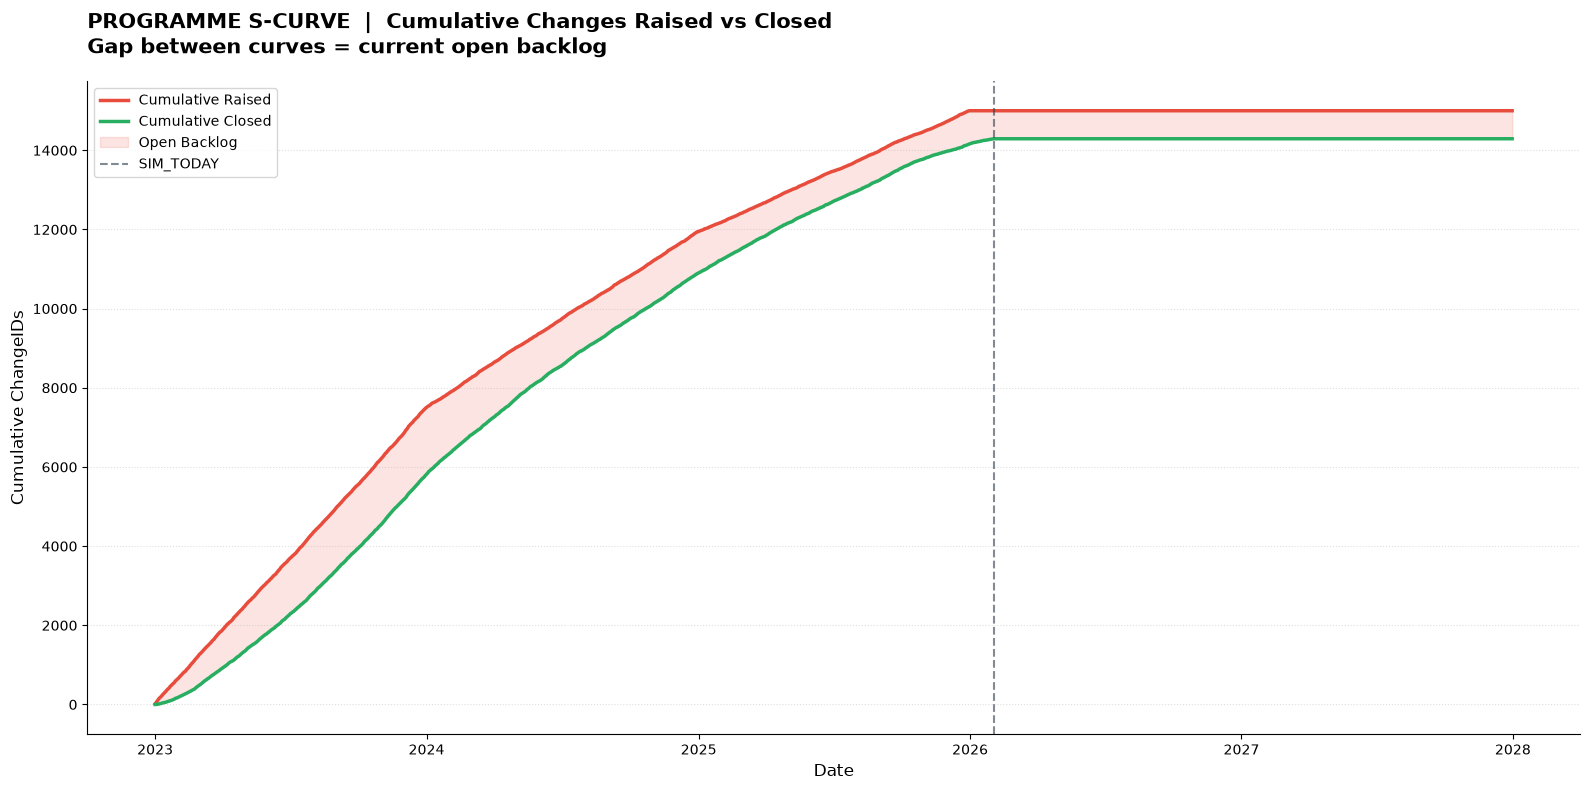

In [7]:
# ==============================================================================
# CELL 7b — cumulative raised vs closed
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, ax = plt.subplots(figsize=(16, 8))

fact_enriched['DateOpened'] = pd.to_datetime(fact_enriched['DateOpened'])
fact_enriched['DateClosed'] = pd.to_datetime(fact_enriched['DateClosed'])

timeline = pd.date_range(start='2023-01-01', end=pd.Timestamp(PROJECT_END), freq='D')

cumulative_raised = []
cumulative_closed = []

for date in timeline:
    raised = (fact_enriched['DateOpened'] <= date).sum()
    closed = (fact_enriched['DateClosed'].notna() &
              (fact_enriched['DateClosed'] <= date)).sum()
    cumulative_raised.append(raised)
    cumulative_closed.append(closed)

ax.plot(timeline, cumulative_raised,
        color='#e74c3c', linewidth=2.5, label='Cumulative Raised')
ax.plot(timeline, cumulative_closed,
        color='#27ae60', linewidth=2.5, label='Cumulative Closed')
ax.fill_between(timeline, cumulative_closed, cumulative_raised,
                alpha=0.15, color='#e74c3c', label='Open Backlog')

ax.axvline(ts_sim_today, color='#2c3e50', linewidth=1.5,
           linestyle='--', alpha=0.6, label='SIM_TODAY')

ax.set_title(
    'PROGRAMME S-CURVE  |  Cumulative Changes Raised vs Closed\n'
    'Gap between curves = current open backlog',
    fontsize=15, fontweight='bold', loc='left', pad=20
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative ChangeIDs', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Closed changes loaded: 14,292
   Levels: [np.int64(1), np.int64(2), np.int64(3)]
   Date range: 2023-01-01 to 2026-02-02
   Days_to_Close range: 1 to 659
   Overdue (Days_Overdue > 0): 671 changes
   Raised late (DateOpened > Actual_Need_Date): 404 changes (2.8% of closed population)


,Level,Impact Type,Total,Raised Late,% Raised Late
0,1,Documentary,79,0,0.0%
1,1,Physical,176,0,0.0%
2,2,Documentary,992,3,0.3%
3,2,Physical,974,44,4.5%
4,3,Documentary,9123,121,1.3%
5,3,Physical,2948,236,8.0%


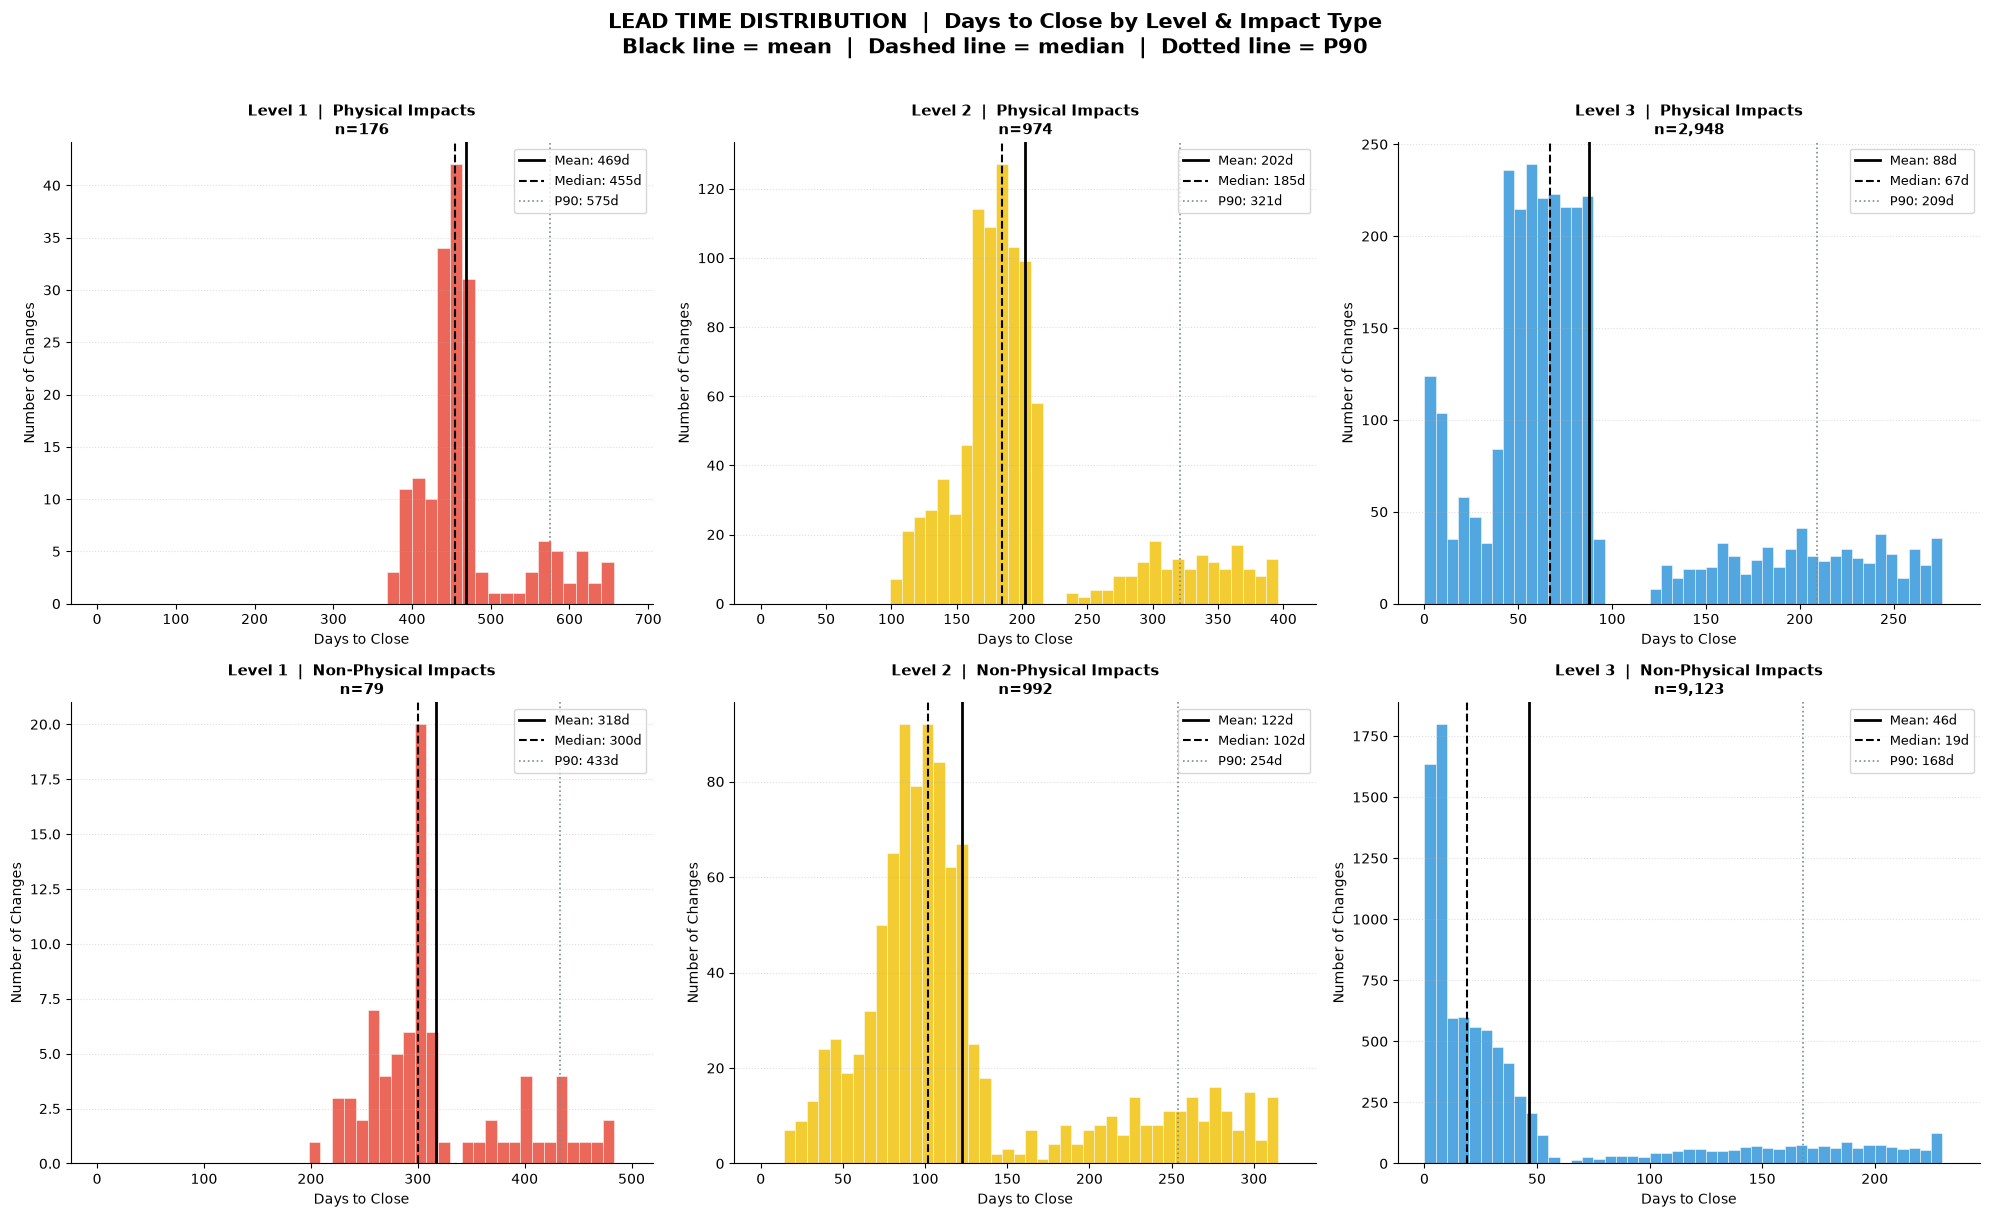

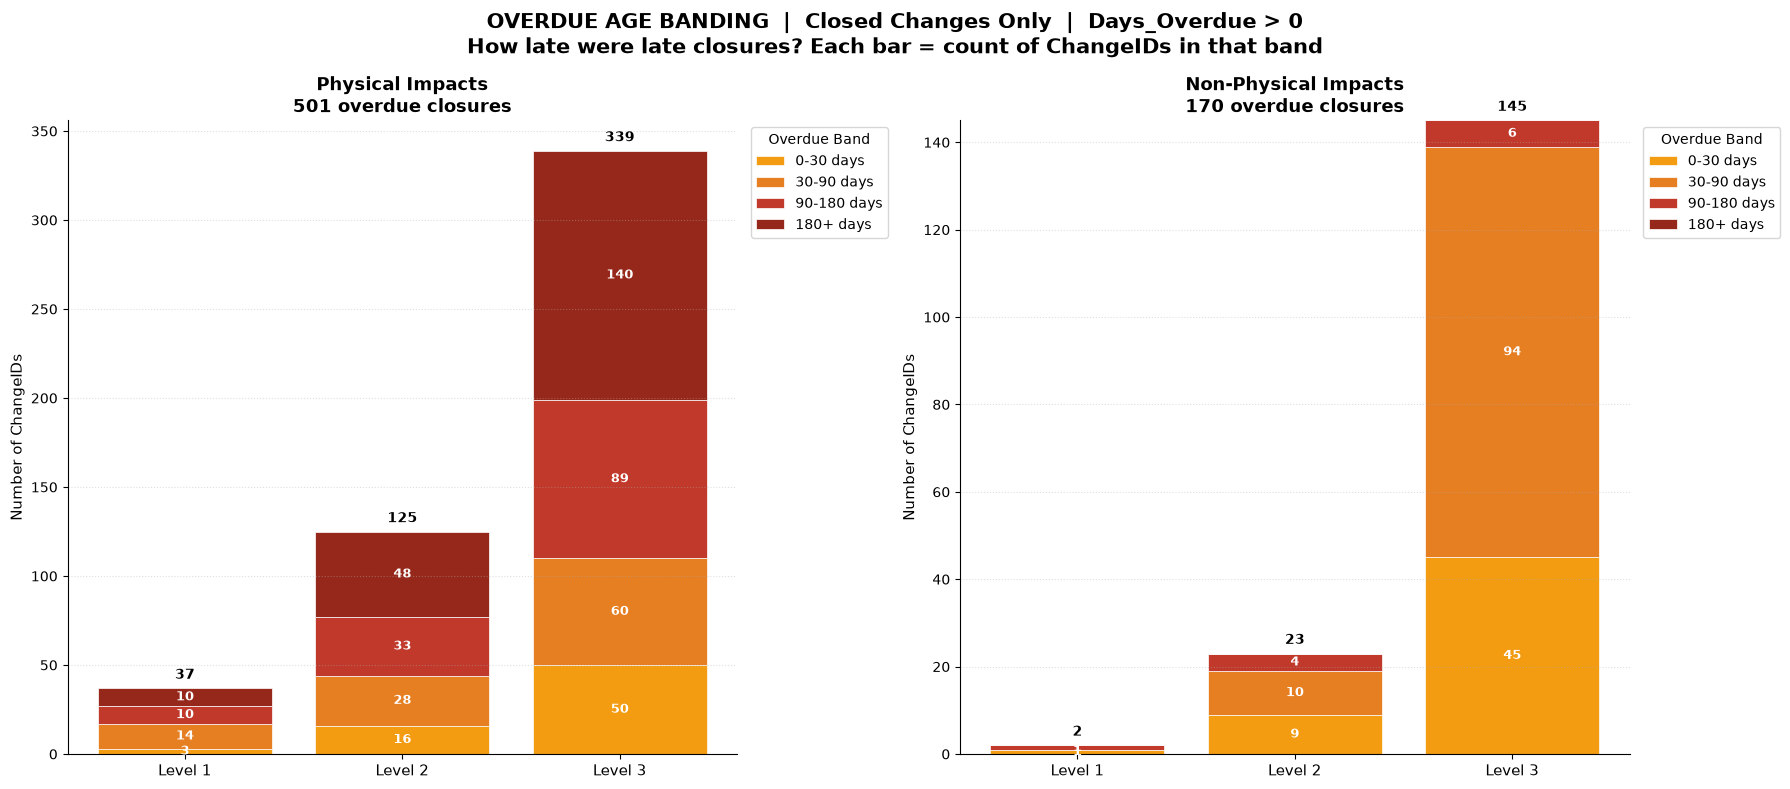

,Level,Impact Type,Overdue Band,Count
0,1,Documentary,0-30 days,1
1,1,Documentary,90-180 days,1
2,1,Physical,0-30 days,3
3,1,Physical,30-90 days,14
4,1,Physical,90-180 days,10
5,1,Physical,180+ days,10
6,2,Documentary,0-30 days,9
7,2,Documentary,30-90 days,10
8,2,Documentary,90-180 days,4
9,2,Physical,0-30 days,16


wrote gold_overdue_changes      671 rows -> data/gold/gold_overdue_changes.parquet  (from: fact_enriched)


,ChangeID,Level,Impact Type,Status,Date Opened,Date Closed,Actual Need Date,Days to Close,Days Overdue,Overdue Band,Raised Late,Driving Milestone,Driving System
5267,C05268,2,Physical,Closed,2025-07-27 00:00:00,2026-02-02 00:00:00,2025-01-15 00:00:00,190,383,180+ days,⚠️ Yes,M1,STU
9717,C09718,3,Physical,Closed,2025-12-17 00:00:00,2026-02-01 00:00:00,2025-01-15 00:00:00,46,382,180+ days,⚠️ Yes,M1,PQR
10137,C10138,3,Physical,Closed,2025-11-16 00:00:00,2026-01-31 00:00:00,2025-01-15 00:00:00,76,381,180+ days,⚠️ Yes,M1,WXY
229,C00230,3,Physical,Closed,2025-12-17 00:00:00,2026-01-31 00:00:00,2025-01-15 00:00:00,45,381,180+ days,⚠️ Yes,M1,STU
12368,C12369,2,Physical,Closed,2025-08-22 00:00:00,2026-01-30 00:00:00,2025-01-15 00:00:00,161,380,180+ days,⚠️ Yes,M1,WXY
8176,C08177,3,Physical,Closed,2025-11-11 00:00:00,2026-01-30 00:00:00,2025-01-15 00:00:00,80,380,180+ days,⚠️ Yes,M1,YZA
8693,C08694,1,Physical,Closed,2024-10-31 00:00:00,2026-01-28 00:00:00,2025-01-15 00:00:00,454,378,180+ days,No,M1,YZA
6720,C06721,3,Physical,Closed,2025-11-26 00:00:00,2026-01-28 00:00:00,2025-01-15 00:00:00,63,378,180+ days,⚠️ Yes,M1,STU
2289,C02290,3,Physical,Closed,2025-12-10 00:00:00,2026-01-24 00:00:00,2025-01-15 00:00:00,45,374,180+ days,⚠️ Yes,M1,ZAB
5595,C05596,3,Physical,Closed,2025-12-29 00:00:00,2026-01-23 00:00:00,2025-01-15 00:00:00,25,373,180+ days,⚠️ Yes,M1,PQR


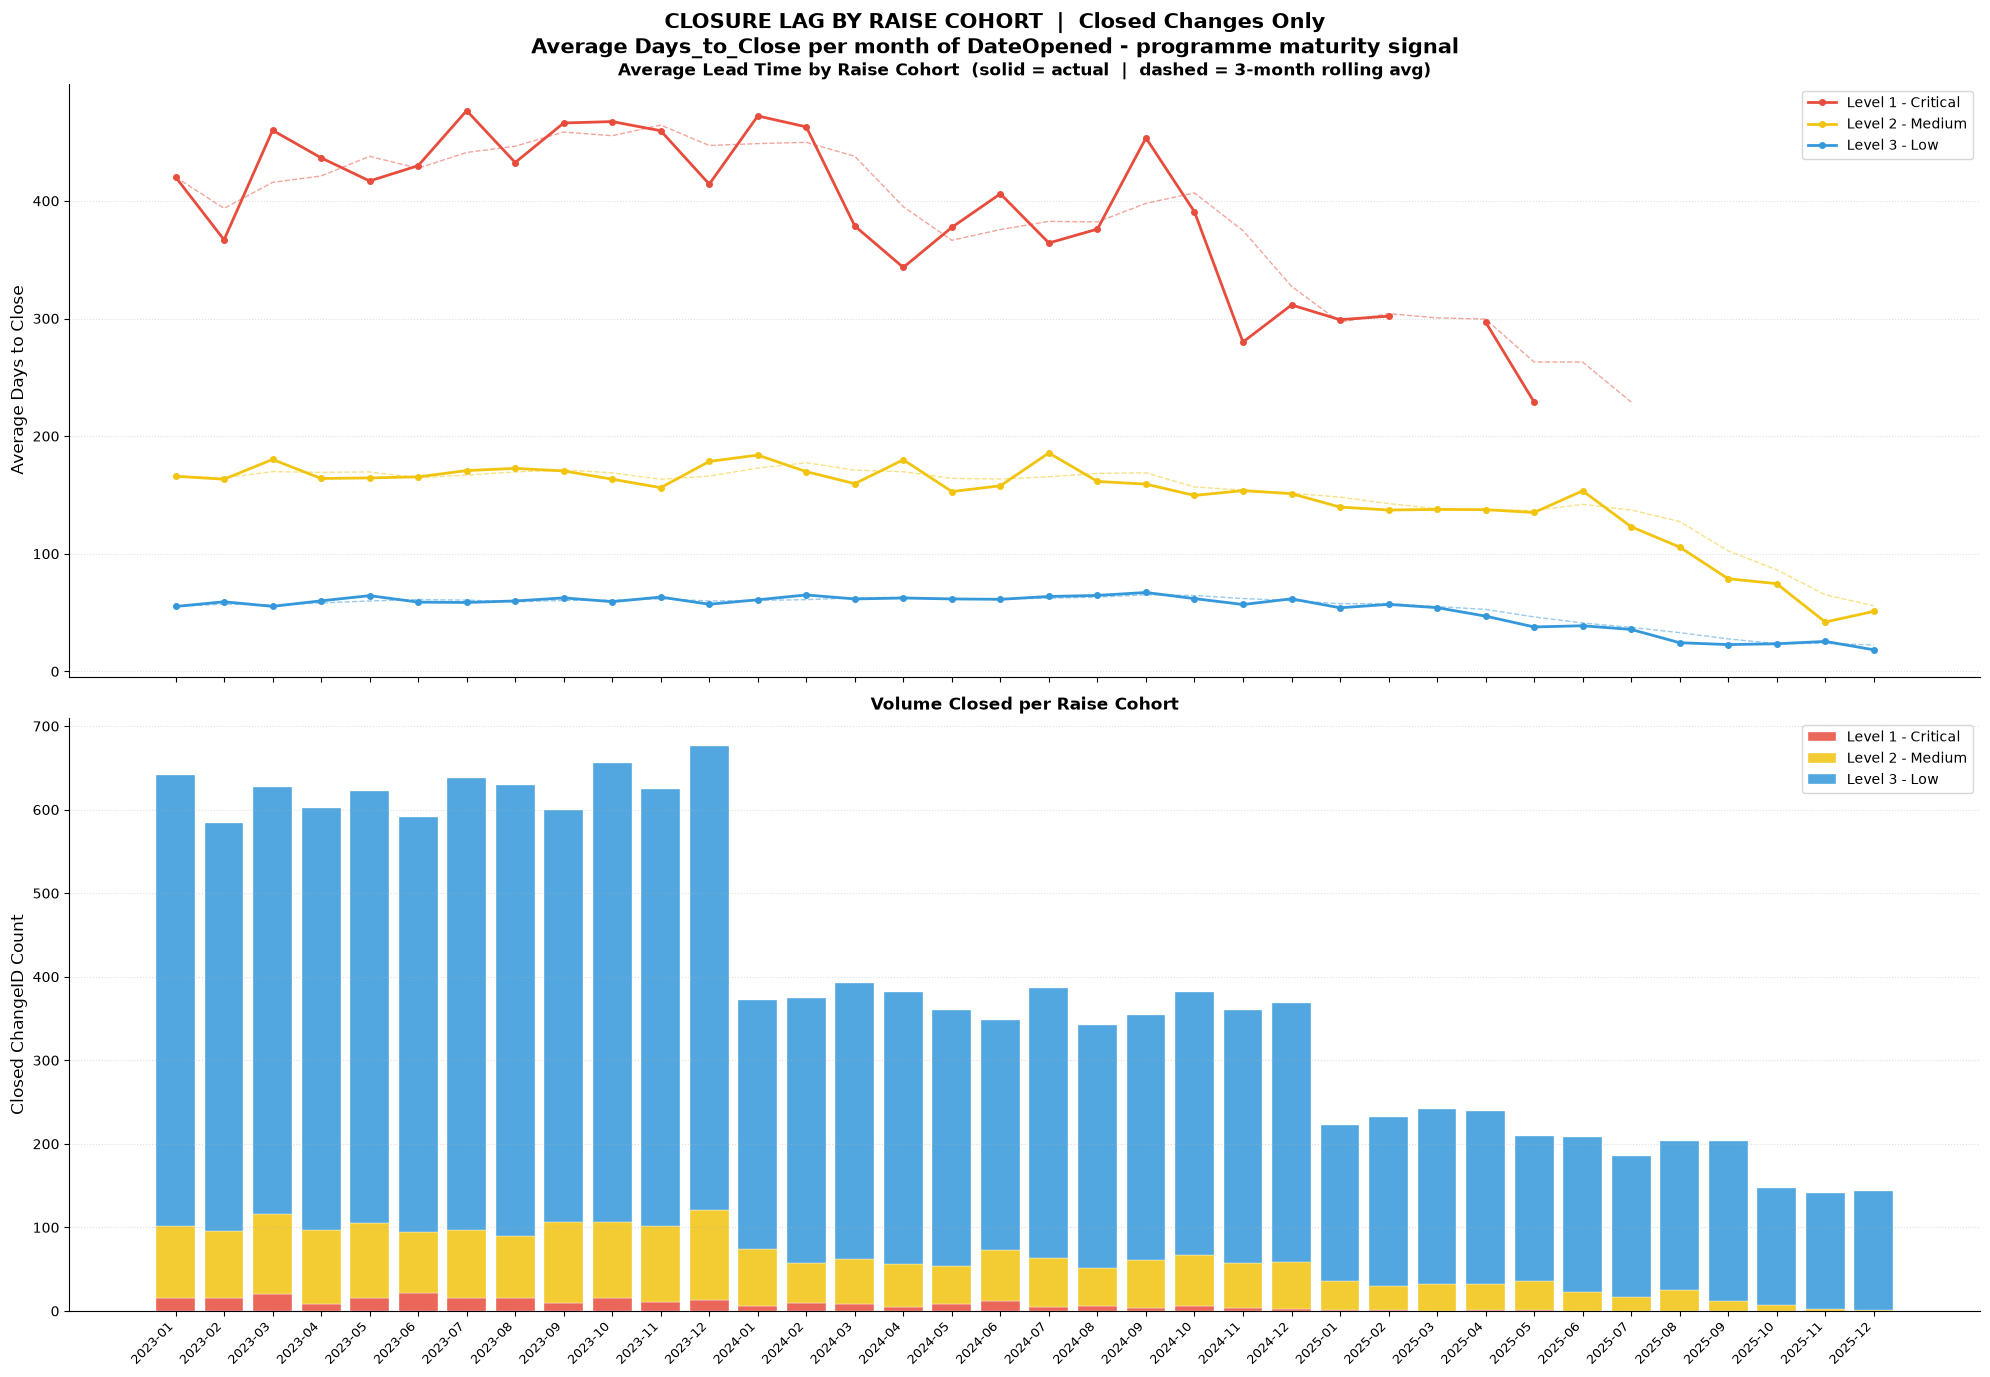

,Raise Cohort,Level,Changes,Avg Lead Time,Median Lead Time,% Closed Late
0,2023-01,1,15,420.3,435.0,0.0%
1,2023-01,2,87,165.9,165.0,0.0%
2,2023-01,3,540,55.2,33.0,0.0%
3,2023-02,1,16,366.9,400.5,0.0%
4,2023-02,2,80,163.4,148.0,0.0%
5,2023-02,3,488,59.2,31.0,0.0%
6,2023-03,1,20,460.0,458.0,0.0%
7,2023-03,2,96,180.2,177.5,0.0%
8,2023-03,3,511,55.3,29.0,0.0%
9,2023-04,1,8,436.6,447.0,0.0%


Historical ChangeID grain analysis complete.


In [8]:
# ==============================================================================
# CELL 8 — HISTORICAL CHANGEID GRAIN ANALYSIS
# ==============================================================================
# Three analyses using closed changes only, staying at ChangeID grain throughout.
# No aggregation to system/contract level — each ChangeID is one data point.
#
# CHART 1: LEAD TIME DISTRIBUTION HISTOGRAM
#   Days_to_Close distribution per level for all closed changes.
#   Reveals whether system averages (Cell 11) hide a tight cluster or wide spread.
#   Physical vs. non-physical faceted side by side.
#
# CHART 2: OVERDUE AGE BANDING
#   For closed changes where Days_Overdue > 0, band into:
#     0-30 days | 30-90 days | 90-180 days | 180+ days
#   Shown as stacked bar per level x physical/non-physical.
#   Answers: "when we did close late, how late were we?"
#   Gold table: individual late ChangeIDs sorted worst first.
#
# CHART 3: CLOSURE LAG BY RAISE COHORT
#   Closed changes grouped by the month they were raised (DateOpened cohort).
#   Shows average Days_to_Close per cohort per level.
#   Programme maturity signal - are changes raised later being resolved faster?
#
# Grain reference:
#   df_hist        ChangeID grain - closed changes only
#   df_overdue     ChangeID grain - closed late only (Days_Overdue > 0)
#   All three charts stay at this grain - no roll-up to system or contract.
#   fact_enriched is already at ChangeID grain - no joins needed.
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ── CONFIG ────────────────────────────────────────────────────────────────────
LEVEL_COLORS  = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}
LEVEL_LABELS  = {1: 'Level 1 - Critical', 2: 'Level 2 - Medium', 3: 'Level 3 - Low'}
BAND_COLORS   = ['#f39c12', '#e67e22', '#c0392b', '#96281b']
BAND_LABELS   = ['0-30 days', '30-90 days', '90-180 days', '180+ days']

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '15px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

# ── DATA PREPARATION ──────────────────────────────────────────────────────────
# Closed changes only - ChangeID grain, one row per change.
df_hist = fact_enriched[fact_enriched['Status'] == 'Closed'].copy()
df_hist['DateOpened']    = pd.to_datetime(df_hist['DateOpened'])
df_hist['DateClosed']    = pd.to_datetime(df_hist['DateClosed'])
df_hist['Days_to_Close'] = df_hist['Days_to_Close'].astype(float)
df_hist['Days_Overdue']  = df_hist['Days_Overdue'].astype(float)

# Cast Physical_Impacts to int - SQLite may return floats (0.0/1.0).
# Fixes all downstream map() calls and == comparisons in chart loops.
df_hist['Physical_Impacts'] = df_hist['Physical_Impacts'].astype(int)

# Raised_Late flag — change opened after its Actual_Need_Date
# These are already overdue at raise regardless of closure speed
df_hist['Actual_Need_Date'] = pd.to_datetime(df_hist['Actual_Need_Date'])
df_hist['Raised_Late'] = (df_hist['DateOpened'] > df_hist['Actual_Need_Date']).astype(int)

df_hist['Impact_Label'] = df_hist['Physical_Impacts'].map(
    {1: 'Physical Impacts', 0: 'Non-Physical Impacts'}
)

print(f"Closed changes loaded: {len(df_hist):,}")
print(f"   Levels: {sorted(df_hist['Level'].unique())}")
print(f"   Date range: {df_hist['DateOpened'].min().date()} to {df_hist['DateClosed'].max().date()}")
print(f"   Days_to_Close range: {df_hist['Days_to_Close'].min():.0f} to {df_hist['Days_to_Close'].max():.0f}")
print(f"   Overdue (Days_Overdue > 0): {(df_hist['Days_Overdue'] > 0).sum():,} changes")
print(f"   Raised late (DateOpened > Actual_Need_Date): "
      f"{df_hist['Raised_Late'].sum():,} changes "
      f"({df_hist['Raised_Late'].mean()*100:.1f}% of closed population)")

# Raised late summary — split by level and impact type
raised_late_summary = (
    df_hist.groupby(['Level', 'Physical_Impacts'])
    .agg(
        Total       = ('ChangeID',    'nunique'),
        Raised_Late = ('Raised_Late', 'sum')
    )
    .reset_index()
)
raised_late_summary['% Raised Late'] = (
    raised_late_summary['Raised_Late'] / raised_late_summary['Total'] * 100
).round(1)
raised_late_summary['Physical_Impacts'] = raised_late_summary['Physical_Impacts'].map(
    {1: 'Physical', 0: 'Documentary'}
)
raised_late_summary.columns = ['Level', 'Impact Type', 'Total', 'Raised Late', '% Raised Late']

display(
    raised_late_summary.style
    .background_gradient(subset=['% Raised Late'], cmap='Reds', vmin=0, vmax=100)
    .set_caption('Raised Late Flag  |  Changes where DateOpened > Actual_Need_Date')
    .format({'% Raised Late': '{:.1f}%'})
    .set_table_styles(TABLE_STYLES)
)


# ==============================================================================
# CHART 1 — LEAD TIME DISTRIBUTION HISTOGRAM
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=False)
fig.suptitle(
    'LEAD TIME DISTRIBUTION  |  Days to Close by Level & Impact Type\n'
    'Black line = mean  |  Dashed line = median  |  Dotted line = P90',
    fontsize=15, fontweight='bold', y=1.01
)

impact_types  = [1, 0]
impact_labels = ['Physical Impacts', 'Non-Physical Impacts']

for row_idx, (imp_val, imp_label) in enumerate(zip(impact_types, impact_labels)):
    subset_imp = df_hist[df_hist['Physical_Impacts'] == imp_val]

    for col_idx, lvl in enumerate([1, 2, 3]):
        ax     = axes[row_idx][col_idx]
        subset = subset_imp[subset_imp['Level'] == lvl]['Days_to_Close'].dropna()

        if subset.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue

        max_val   = subset.quantile(0.99)
        bin_width = max(1, int(max_val / 40))
        bins      = range(0, int(max_val) + bin_width * 2, bin_width)

        ax.hist(
            subset.clip(upper=max_val),
            bins=bins,
            color=LEVEL_COLORS[lvl],
            edgecolor='white',
            linewidth=0.4,
            alpha=0.85
        )

        mean_val   = subset.mean()
        median_val = subset.median()
        p90_val    = subset.quantile(0.90)

        ax.axvline(mean_val,   color='black',   linewidth=2,   label=f'Mean: {mean_val:.0f}d')
        ax.axvline(median_val, color='black',   linewidth=1.5, linestyle='--', label=f'Median: {median_val:.0f}d')
        ax.axvline(p90_val,    color='#7f8c8d', linewidth=1.2, linestyle=':',  label=f'P90: {p90_val:.0f}d')

        ax.set_title(f'Level {lvl}  |  {imp_label}\nn={len(subset):,}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Days to Close', fontsize=10)
        ax.set_ylabel('Number of Changes', fontsize=10)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(axis='y', linestyle=':', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


# ==============================================================================
# CHART 2 — OVERDUE AGE BANDING
# ==============================================================================

df_overdue = df_hist[df_hist['Days_Overdue'] > 0].copy()

def assign_band(days):
    if days <= 30:    return '0-30 days'
    elif days <= 90:  return '30-90 days'
    elif days <= 180: return '90-180 days'
    else:             return '180+ days'

df_overdue['Overdue_Band'] = df_overdue['Days_Overdue'].apply(assign_band)
df_overdue['Overdue_Band'] = pd.Categorical(
    df_overdue['Overdue_Band'], categories=BAND_LABELS, ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'OVERDUE AGE BANDING  |  Closed Changes Only  |  Days_Overdue > 0\n'
    'How late were late closures? Each bar = count of ChangeIDs in that band',
    fontsize=15, fontweight='bold'
)

for ax_idx, (imp_val, imp_label) in enumerate(zip(impact_types, impact_labels)):
    ax     = axes[ax_idx]
    subset = df_overdue[df_overdue['Physical_Impacts'] == imp_val]

    if subset.empty:
        ax.text(0.5, 0.5, f'No overdue closures\n{imp_label}',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(imp_label, fontsize=13, fontweight='bold')
        continue

    pivot = (
        subset.groupby(['Level', 'Overdue_Band'], observed=True)['ChangeID']
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=BAND_LABELS, fill_value=0)
    )

    bottom = np.zeros(len(pivot))
    x_pos  = np.arange(len(pivot))

    for band, color in zip(BAND_LABELS, BAND_COLORS):
        if band not in pivot.columns:
            continue
        vals = pivot[band].values
        ax.bar(x_pos, vals, bottom=bottom, color=color,
               label=band, edgecolor='white', linewidth=0.5)

        for i, (val, bot) in enumerate(zip(vals, bottom)):
            if val > 0:
                ax.text(i, bot + val / 2, str(int(val)),
                        ha='center', va='center', fontsize=9,
                        fontweight='bold', color='white')
        bottom += vals

    totals = pivot.sum(axis=1).values
    for i, total in enumerate(totals):
        ax.text(i, total + totals.max() * 0.01, f'{int(total):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Level {l}' for l in pivot.index], fontsize=11)
    ax.set_title(f'{imp_label}\n{len(subset):,} overdue closures', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of ChangeIDs', fontsize=11)
    ax.legend(title='Overdue Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Aggregated summary table
band_summary = (
    df_overdue.groupby(['Level', 'Physical_Impacts', 'Overdue_Band'], observed=True)['ChangeID']
    .nunique()
    .reset_index(name='Count')
)
band_summary['Physical_Impacts'] = band_summary['Physical_Impacts'].astype(int).map(
    {1: 'Physical', 0: 'Documentary'}
)
band_summary.columns = ['Level', 'Impact Type', 'Overdue Band', 'Count']

display(
    band_summary.style
    .background_gradient(subset=['Count'], cmap='Reds')
    .set_caption(
        f'Overdue Banding Detail  |  {len(df_overdue):,} late closures '
        f'from {len(df_hist):,} total closed changes  '
        f'({len(df_overdue)/len(df_hist)*100:.1f}% closed late)'
    )
    .set_table_styles(TABLE_STYLES)
)

# Gold table — individual late ChangeIDs, sorted worst first
gold_overdue = df_overdue[[
    'ChangeID', 'Level', 'Physical_Impacts', 'Status',
    'DateOpened', 'DateClosed', 'Actual_Need_Date', 'Days_to_Close',
    'Days_Overdue', 'Overdue_Band', 'Raised_Late', 'Driving_Milestone', 'Driving_System'
]].copy()

gold_overdue['Physical_Impacts'] = gold_overdue['Physical_Impacts'].map(
    {1: 'Physical', 0: 'Documentary'}
)
gold_overdue['Raised_Late'] = gold_overdue['Raised_Late'].map(
    {1: '⚠️ Yes', 0: 'No'}
)
gold_overdue = gold_overdue.sort_values('Days_Overdue', ascending=False)
gold_overdue.columns = [
    'ChangeID', 'Level', 'Impact Type', 'Status',
    'Date Opened', 'Date Closed', 'Actual Need Date', 'Days to Close',
    'Days Overdue', 'Overdue Band', 'Raised Late', 'Driving Milestone', 'Driving System'
]

# ── persist gold layer ───────────────────────────────────────────────────────
import sys
sys.path.insert(0, str(ROOT / "src"))
from lineage import write_layer

write_layer(gold_overdue, "gold_overdue_changes", ROOT / "data" / "gold", sources=["fact_enriched"])

display(
    gold_overdue.style
    .background_gradient(subset=['Days Overdue'], cmap='Reds')
    .set_caption(
        f'Late Closures — ChangeID Grain  |  {len(gold_overdue):,} changes  |  '
        f'Sorted worst first'
    )
    .format({'Days to Close': '{:.0f}', 'Days Overdue': '{:.0f}'})
    .set_table_styles(TABLE_STYLES)
)


# ==============================================================================
# CHART 3 — CLOSURE LAG BY RAISE COHORT
# ==============================================================================

df_hist['Raise_Cohort'] = df_hist['DateOpened'].dt.to_period('M').astype(str)

cohort_agg = (
    df_hist.groupby(['Raise_Cohort', 'Level'])['Days_to_Close']
    .agg(Avg_Days='mean', Median_Days='median', Count='count')
    .reset_index()
)
cohort_agg['Avg_Days']    = cohort_agg['Avg_Days'].round(1)
cohort_agg['Median_Days'] = cohort_agg['Median_Days'].round(1)

cohort_pivot = cohort_agg.pivot(index='Raise_Cohort', columns='Level', values='Avg_Days')
cohort_count = cohort_agg.pivot(index='Raise_Cohort', columns='Level', values='Count').fillna(0)

all_cohorts  = sorted(cohort_pivot.index.tolist())
cohort_pivot = cohort_pivot.reindex(all_cohorts)
cohort_count = cohort_count.reindex(all_cohorts)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 14), sharex=True)
fig.suptitle(
    'CLOSURE LAG BY RAISE COHORT  |  Closed Changes Only\n'
    'Average Days_to_Close per month of DateOpened - programme maturity signal',
    fontsize=15, fontweight='bold'
)

x         = np.arange(len(all_cohorts))
tick_step = max(1, len(all_cohorts) // 24)

for lvl in [1, 2, 3]:
    if lvl not in cohort_pivot.columns:
        continue
    vals    = cohort_pivot[lvl].values
    rolling = pd.Series(vals).rolling(3, min_periods=1).mean()
    ax1.plot(x, vals,    marker='o', markersize=4, color=LEVEL_COLORS[lvl],
             linewidth=2, label=LEVEL_LABELS[lvl])
    ax1.plot(x, rolling, color=LEVEL_COLORS[lvl], linewidth=1,
             linestyle='--', alpha=0.5)

sim_cohort = pd.Timestamp(ts_sim_today).to_period('M').strftime('%Y-%m')
if sim_cohort in all_cohorts:
    ax1.axvline(x=all_cohorts.index(sim_cohort),
                color='black', linewidth=1.5, linestyle=':', alpha=0.6, label='SIM_TODAY')

ax1.set_ylabel('Average Days to Close', fontsize=12)
ax1.set_title('Average Lead Time by Raise Cohort  (solid = actual  |  dashed = 3-month rolling avg)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', linestyle=':', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

bottom = np.zeros(len(all_cohorts))
for lvl in [1, 2, 3]:
    if lvl not in cohort_count.columns:
        continue
    vals = cohort_count[lvl].values
    ax2.bar(x, vals, bottom=bottom, color=LEVEL_COLORS[lvl],
            label=LEVEL_LABELS[lvl], edgecolor='white', linewidth=0.3, alpha=0.85)
    bottom += vals

ax2.set_ylabel('Closed ChangeID Count', fontsize=12)
ax2.set_title('Volume Closed per Raise Cohort', fontsize=12, fontweight='bold')
ax2.set_xticks(x[::tick_step])
ax2.set_xticklabels(all_cohorts[::tick_step], rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle=':', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Summary table
cohort_table = (
    df_hist.groupby(['Raise_Cohort', 'Level'])
    .agg(
        Changes     = ('ChangeID',      'nunique'),
        Avg_Lead    = ('Days_to_Close', 'mean'),
        Median_Lead = ('Days_to_Close', 'median'),
        Pct_Late    = ('Days_Overdue',  lambda x: (x > 0).mean() * 100)
    )
    .round(1)
    .reset_index()
)
cohort_table.columns = ['Raise Cohort', 'Level', 'Changes', 'Avg Lead Time', 'Median Lead Time', '% Closed Late']

display(
    cohort_table.style
    .background_gradient(subset=['Avg Lead Time'], cmap='RdYlGn_r')
    .background_gradient(subset=['% Closed Late'], cmap='Reds', vmin=0, vmax=100)
    .set_caption('Closure Lag by Raise Cohort  |  One row per cohort x level')
    .format({'Avg Lead Time': '{:.1f}', 'Median Lead Time': '{:.1f}', '% Closed Late': '{:.1f}%'})
    .set_table_styles(TABLE_STYLES)
)

print("Historical ChangeID grain analysis complete.")

✅ Lead time data prepared: 14,292 closed changes


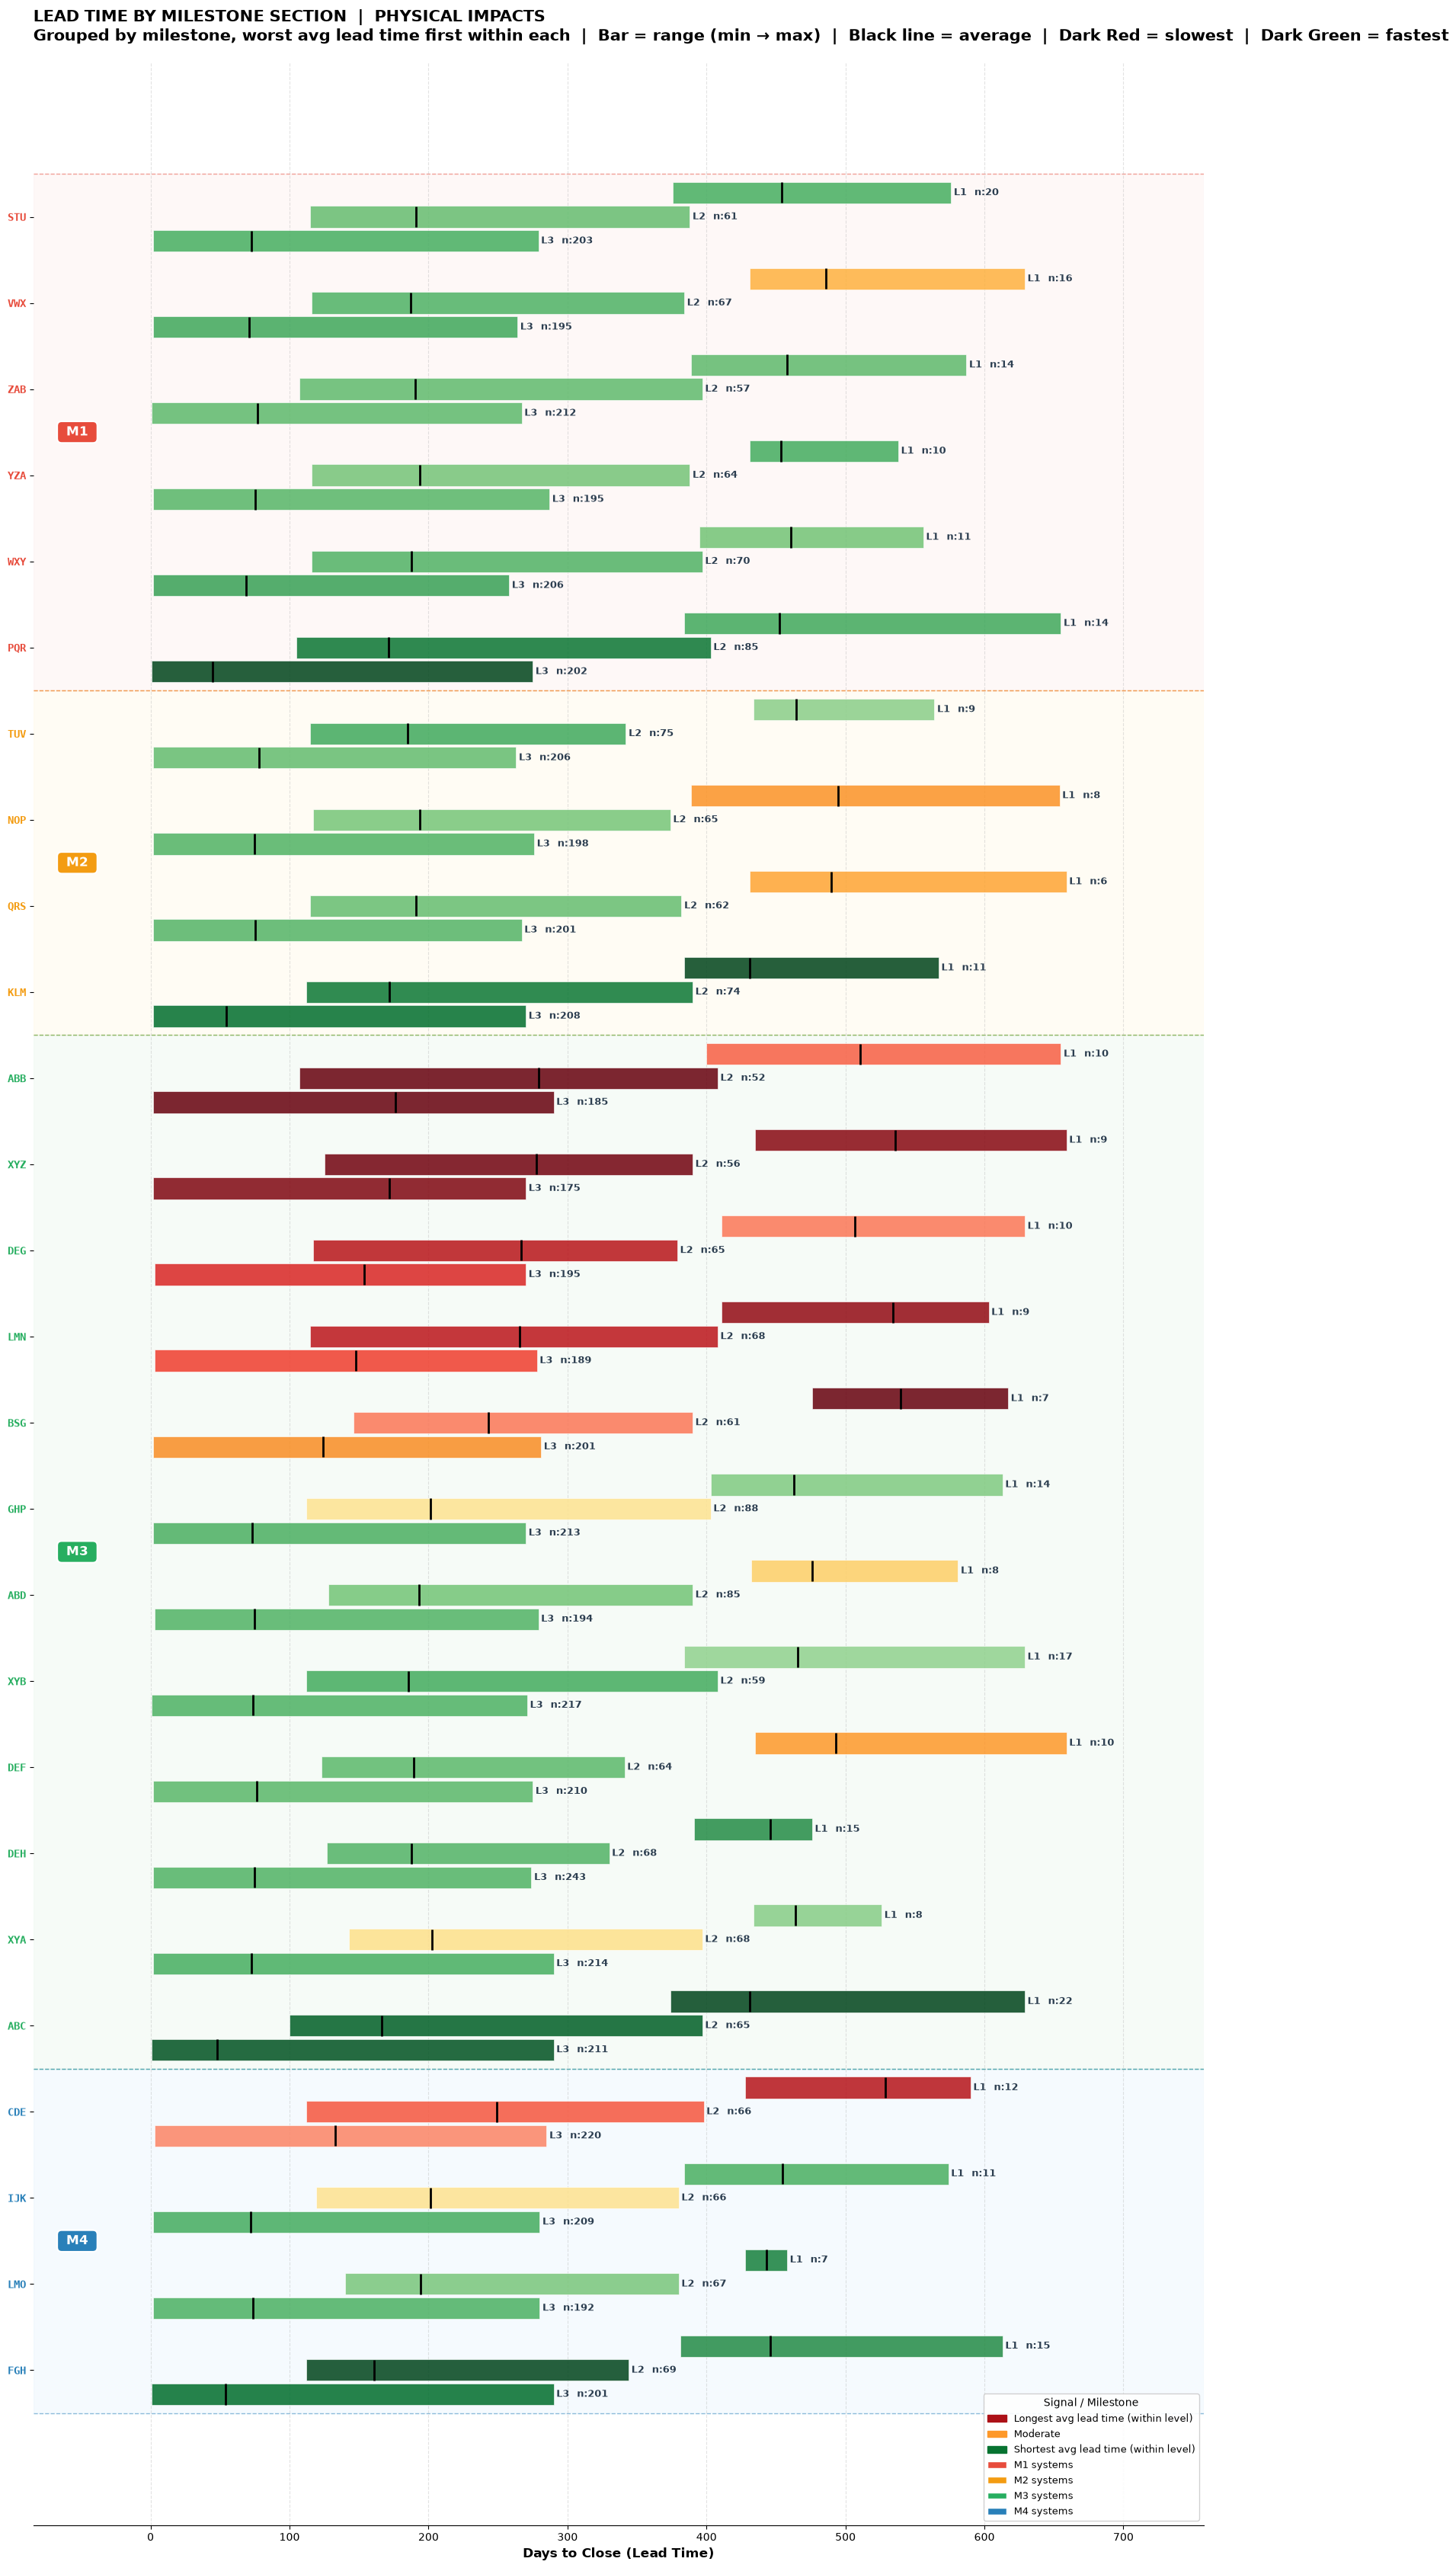

,Milestone,Target Date,System,Closed Changes,Avg Lead Time (d),Min Lead Time (d),Max Lead Time (d),P80 Lead Time (d)
0,M1,2026-01-15 00:00:00,STU,284,125,2,576,185.4
1,M1,2026-01-15 00:00:00,VWX,278,123,2,629,184.0
2,M1,2026-01-15 00:00:00,ZAB,283,118,1,587,187.0
3,M1,2026-01-15 00:00:00,YZA,269,118,2,538,179.0
4,M1,2026-01-15 00:00:00,WXY,287,113,2,556,181.6
5,M1,2026-01-15 00:00:00,PQR,301,99,1,655,155.0
6,M2,2026-06-15 00:00:00,TUV,290,118,2,564,185.0
7,M2,2026-06-15 00:00:00,NOP,271,116,2,654,189.0
8,M2,2026-06-15 00:00:00,QRS,269,111,2,659,180.4
9,M2,2026-06-15 00:00:00,KLM,293,98,2,567,157.0


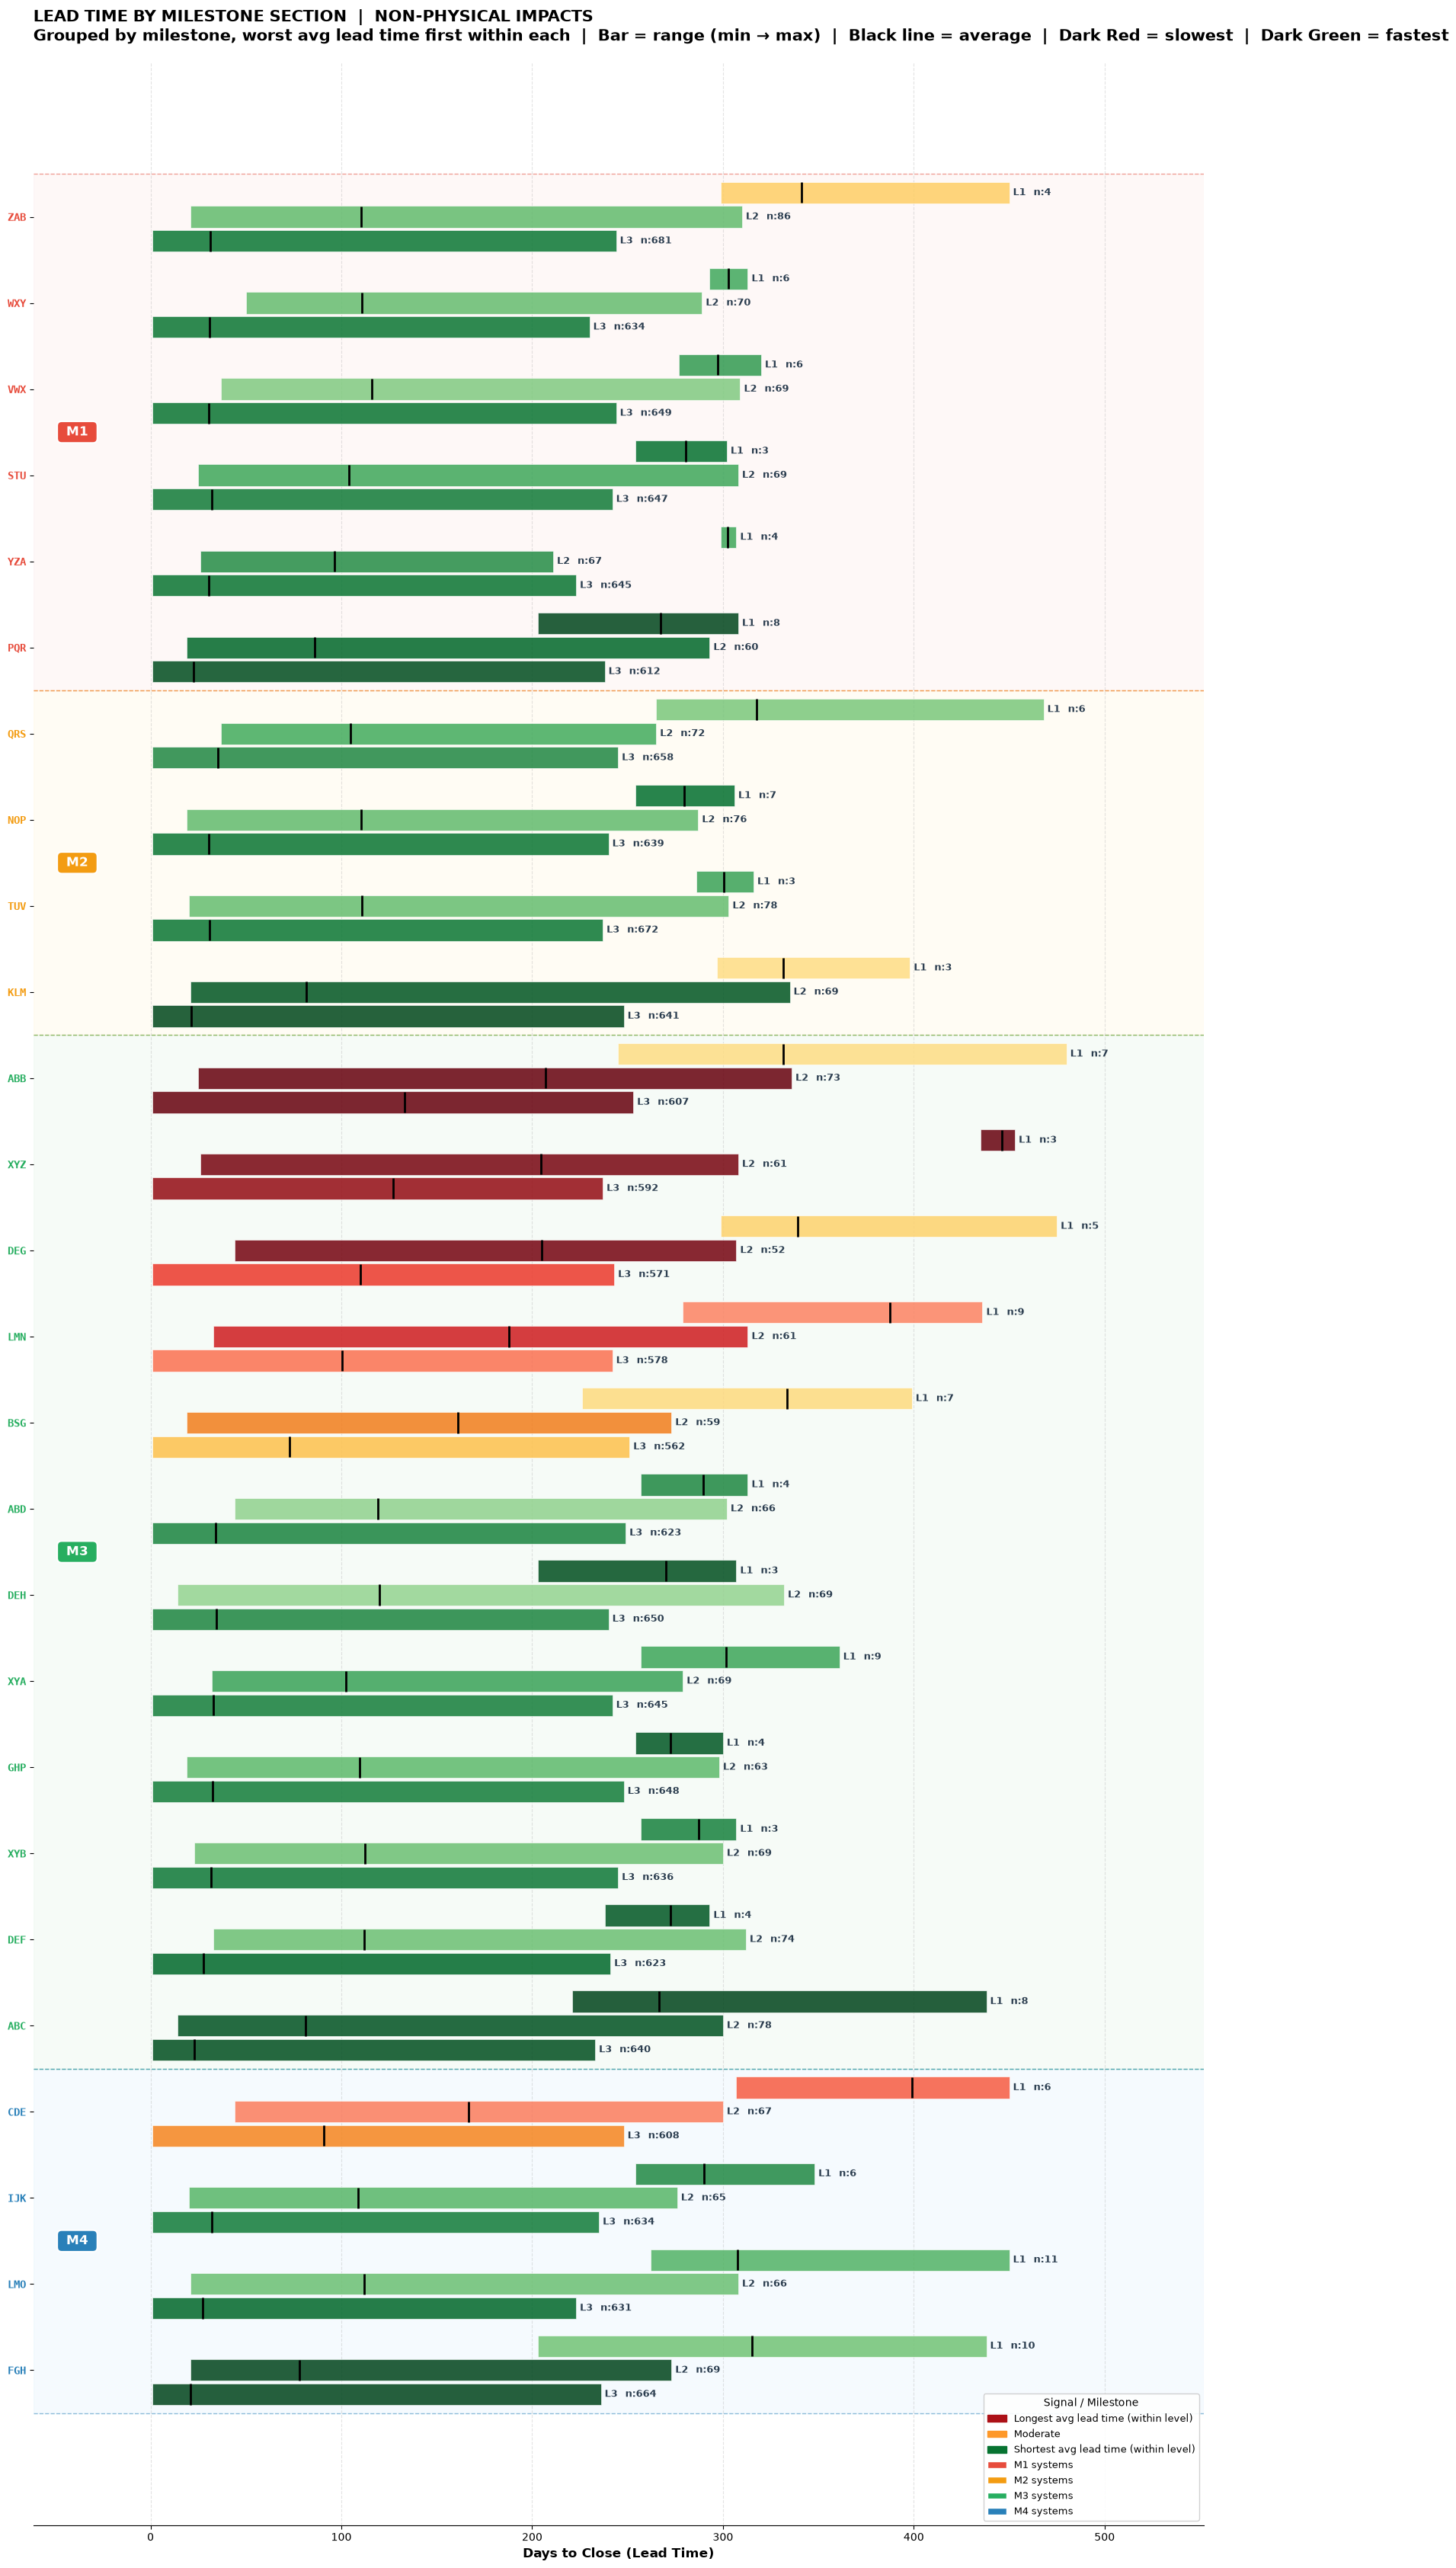

,Milestone,Target Date,System,Closed Changes,Avg Lead Time (d),Min Lead Time (d),Max Lead Time (d),P80 Lead Time (d)
0,M1,2026-01-15 00:00:00,ZAB,771,42,1,450,52.0
1,M1,2026-01-15 00:00:00,WXY,710,41,1,313,49.2
2,M1,2026-01-15 00:00:00,VWX,724,41,1,320,50.0
3,M1,2026-01-15 00:00:00,STU,719,40,1,308,51.4
4,M1,2026-01-15 00:00:00,YZA,716,38,1,307,46.0
5,M1,2026-01-15 00:00:00,PQR,680,31,1,308,36.2
6,M2,2026-06-15 00:00:00,QRS,736,44,1,468,74.0
7,M2,2026-06-15 00:00:00,NOP,722,41,1,306,50.0
8,M2,2026-06-15 00:00:00,TUV,753,40,1,316,47.0
9,M2,2026-06-15 00:00:00,KLM,713,29,1,398,37.0


In [9]:
# ==============================================================================
# CELL 9 — LEAD TIME BY MILESTONE SECTION
# ==============================================================================
#
# Shows historical closure performance per system × level.
# Two charts produced — Physical Impacts and Non-Physical Impacts.
#
# Bar colour uses min-max normalisation within each level:
#   score = 0 → fastest system at this level (darkest green)
#   score = 1 → slowest system at this level (darkest red)
#
# Bar range = min → max lead time per system × level.
# Black vertical line = average lead time.
# Systems sorted by milestone (M1→M4), then worst avg lead time first within
# each milestone group — matching Cell 11 stagnation chart sort order.
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from IPython.display import display

# ── 1. CONFIG ─────────────────────────────────────────────────────────────────
M_COLORS      = {'M1': '#fdecea', 'M2': '#fff8e1', 'M3': '#e8f5e9', 'M4': '#e3f2fd'}
M_BORDERS     = {'M1': '#e74c3c', 'M2': '#f39c12', 'M3': '#27ae60', 'M4': '#2980b9'}
level_offsets = {1: -0.28, 2: 0, 3: 0.28}
MILESTONE_ORDER = ['M1', 'M2', 'M3', 'M4']

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '16px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

# ── 2. COLOUR FUNCTION ────────────────────────────────────────────────────────
def get_leadtime_bar_color(avg_lt, min_lt, max_lt):
    rng   = max_lt - min_lt
    score = (avg_lt - min_lt) / rng if rng > 0 else 0.5
    if score >= 0.66:
        intensity = 0.4 + 0.6 * ((score - 0.66) / 0.34)
        return plt.get_cmap('Reds')(intensity)
    elif score >= 0.33:
        intensity = 0.4 + 0.6 * ((score - 0.33) / 0.33)
        return plt.get_cmap('YlOrBr')(intensity * 0.6)
    else:
        intensity = 0.4 + 0.6 * (1 - (score / 0.33))
        return plt.get_cmap('Greens')(intensity)

# ── 3. GOLD TABLE STYLING ─────────────────────────────────────────────────────
def style_leadtime(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in df.index:
        styles.loc[i, :] = f'background-color: {"#fffdf0" if i % 2 == 0 else "#fff9e0"}'
    if 'Avg Lead Time (d)' in df.columns:
        max_avg = df['Avg Lead Time (d)'].max()
        for i, val in df['Avg Lead Time (d)'].items():
            ratio = val / max_avg if max_avg > 0 else 0
            bg    = '#c0392b' if ratio > 0.66 else '#f39c12' if ratio > 0.33 else '#1e8449'
            styles.loc[i, 'Avg Lead Time (d)'] = (
                f'background-color: {bg}; color: white; font-weight: bold'
            )
    return styles

# ── 4. DATA PREP ──────────────────────────────────────────────────────────────
df_closed = fact_enriched[fact_enriched['Status'] == 'Closed'][[
    'ChangeID', 'Level', 'Physical_Impacts',
    'Days_to_Close', 'Driving_Milestone'
]].copy()

df_closed['Days_to_Close']   = pd.to_numeric(df_closed['Days_to_Close'], errors='coerce')
df_closed['Level']           = pd.to_numeric(df_closed['Level'], errors='coerce').fillna(0).astype(int)
df_closed['Physical_Impacts'] = df_closed['Physical_Impacts'].astype(int)

df_base = (
    df_closed
    .merge(systems_bridge, on='ChangeID',     how='left')
    .merge(systems_master,  on='SystemCode',   how='left')
    .merge(df_milestones,   on='Milestone_ID', how='left')
)
df_base['SystemCode']   = df_base['SystemCode'].fillna('UNASSIGNED')
df_base['Milestone_ID'] = df_base['Milestone_ID'].fillna('UNKNOWN')

print(f"\u2705 Lead time data prepared: {df_closed['ChangeID'].nunique():,} closed changes")

# ── 5. PLOT FUNCTION ──────────────────────────────────────────────────────────
def plot_leadtime(df_source, impact_val, title_suffix):
    """
    Range bar chart of historical lead time per system x level.
    impact_val: 1 = physical, 0 = non-physical
    """
    df = df_source[df_source['SystemCode'] != 'UNASSIGNED'].copy()
    df = df[df['Physical_Impacts'] == impact_val]

    if df.empty:
        print(f'No data for {title_suffix}')
        return

    # Aggregate to SystemCode x Level grain for bars
    sys_level_agg = (
        df.groupby(['Milestone_ID', 'Project_Target_Date', 'SystemCode', 'Level'])
        .agg(
            Closed_Changes = ('ChangeID',      'nunique'),
            Avg_Lead_Time  = ('Days_to_Close', 'mean'),
            Min_Lead_Time  = ('Days_to_Close', 'min'),
            Max_Lead_Time  = ('Days_to_Close', 'max'),
        )
        .reset_index()
    )

    # Aggregate to SystemCode grain for sort order and gold table
    sys_agg = (
        df.groupby(['Milestone_ID', 'Project_Target_Date', 'SystemCode'])
        .agg(
            Closed_Changes = ('ChangeID',      'nunique'),
            Avg_Lead_Time  = ('Days_to_Close', 'mean'),
            Min_Lead_Time  = ('Days_to_Close', 'min'),
            Max_Lead_Time  = ('Days_to_Close', 'max'),
            P80_Lead_Time  = ('Days_to_Close', lambda x: x.quantile(0.8)),
        )
        .reset_index()
    )

    sys_agg['M_Order'] = sys_agg['Milestone_ID'].map(
        {m: i for i, m in enumerate(MILESTONE_ORDER)}
    ).fillna(99)
    sys_agg = sys_agg.sort_values(
        ['M_Order', 'Avg_Lead_Time'], ascending=[True, False]
    ).reset_index(drop=True)

    system_order  = sys_agg['SystemCode'].tolist()
    sys_milestone = sys_agg.set_index('SystemCode')['Milestone_ID'].to_dict()
    n_sys         = len(system_order)

    sys_level_agg['Level'] = sys_level_agg['Level'].astype(int)

    level_ranges = {}
    for lvl, grp in sys_level_agg.groupby('Level'):
        level_ranges[int(lvl)] = {
            'min_lt': float(grp['Avg_Lead_Time'].min()),
            'max_lt': float(grp['Avg_Lead_Time'].max()),
        }

    fig, ax = plt.subplots(figsize=(16, max(10, n_sys * 1.3)))

    prev_m, band_start, bands = None, 0, []
    for idx, sys in enumerate(system_order):
        m = sys_milestone.get(sys, 'UNKNOWN')
        if m != prev_m:
            if prev_m is not None:
                bands.append((band_start, idx - 1, prev_m))
            band_start, prev_m = idx, m
    bands.append((band_start, n_sys - 1, prev_m))

    x_left_label = -sys_level_agg['Max_Lead_Time'].max() * 0.08

    for (start, end, m_id) in bands:
        ax.axhspan(start - 0.5, end + 0.5,
                   color=M_COLORS.get(m_id, '#f5f5f5'), alpha=0.35, zorder=0)
        for boundary in [start - 0.5, end + 0.5]:
            ax.axhline(boundary, color=M_BORDERS.get(m_id, '#aaa'),
                       linewidth=1.0, linestyle='--', alpha=0.5, zorder=1)
        mid = (start + end) / 2
        ax.text(x_left_label, mid, f' {m_id} ',
                color='white', fontweight='bold', fontsize=12,
                va='center', ha='center', zorder=5,
                bbox=dict(facecolor=M_BORDERS.get(m_id, '#aaa'),
                          edgecolor='white', boxstyle='round,pad=0.35', linewidth=1.5))

    for i, sys in enumerate(system_order):
        sys_rows = sys_level_agg[sys_level_agg['SystemCode'] == sys]
        for _, row in sys_rows.iterrows():
            lvl   = int(row['Level'])
            y_pos = i + level_offsets.get(lvl, 0)
            rng   = level_ranges.get(lvl, {})
            color = get_leadtime_bar_color(
                float(row['Avg_Lead_Time']),
                float(rng.get('min_lt', 0)),
                float(rng.get('max_lt', 1)),
            )
            bar_width = max(2, row['Max_Lead_Time'] - row['Min_Lead_Time'])
            ax.barh(y_pos, bar_width, left=row['Min_Lead_Time'],
                    height=0.25, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, zorder=3)
            ax.vlines(row['Avg_Lead_Time'], y_pos - 0.12, y_pos + 0.12,
                      color='black', linewidth=2, zorder=5)
            ax.text(row['Max_Lead_Time'] + 2, y_pos,
                    f"L{lvl}  n:{int(row['Closed_Changes'])}",
                    va='center', ha='left', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(n_sys))
    ax.set_yticklabels(system_order, fontweight='bold', fontsize=10,
                       fontfamily='monospace')
    plt.draw()
    for tick, sys in zip(ax.get_yticklabels(), system_order):
        tick.set_color(M_BORDERS.get(sys_milestone.get(sys, 'UNKNOWN'), '#2c3e50'))

    ax.invert_yaxis()
    ax.set_xlim(x_left_label * 1.6, sys_level_agg['Max_Lead_Time'].max() * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Days to Close (Lead Time)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'LEAD TIME BY MILESTONE SECTION  |  {title_suffix}\n'
        f'Grouped by milestone, worst avg lead time first within each  |  '
        f'Bar = range (min \u2192 max)  |  Black line = average  |  '
        f'Dark Red = slowest  |  Dark Green = fastest',
        fontsize=15, fontweight='bold', loc='left', pad=20
    )

    stag_patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),   label='Longest avg lead time (within level)'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.5),  label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85), label='Shortest avg lead time (within level)'),
    ]
    m_patches = [
        mpatches.Patch(facecolor=M_BORDERS[m], edgecolor='white', label=f'{m} systems')
        for m in MILESTONE_ORDER if m in sys_milestone.values()
    ]
    ax.legend(handles=stag_patches + m_patches,
              loc='lower right', framealpha=0.9,
              fontsize=9, title='Signal / Milestone')

    plt.tight_layout()
    plt.show()

    display(
        sys_agg.drop(columns=['M_Order']).rename(columns={
            'Milestone_ID':        'Milestone',
            'Project_Target_Date': 'Target Date',
            'SystemCode':          'System',
            'Closed_Changes':      'Closed Changes',
            'Avg_Lead_Time':       'Avg Lead Time (d)',
            'Min_Lead_Time':       'Min Lead Time (d)',
            'Max_Lead_Time':       'Max Lead Time (d)',
            'P80_Lead_Time':       'P80 Lead Time (d)',
        }).style
        .apply(style_leadtime, axis=None)
        .set_caption(f'\U0001f947 GOLD \u2014 System Lead Time: {title_suffix}')
        .format({
            'Avg Lead Time (d)': '{:.0f}',
            'Min Lead Time (d)': '{:.0f}',
            'Max Lead Time (d)': '{:.0f}',
            'P80 Lead Time (d)': '{:.1f}',
        })
        .set_table_styles(TABLE_STYLES)
    )

# ── 6. RUN ────────────────────────────────────────────────────────────────────
plot_leadtime(df_base, 1, 'PHYSICAL IMPACTS')
plot_leadtime(df_base, 0, 'NON-PHYSICAL IMPACTS')


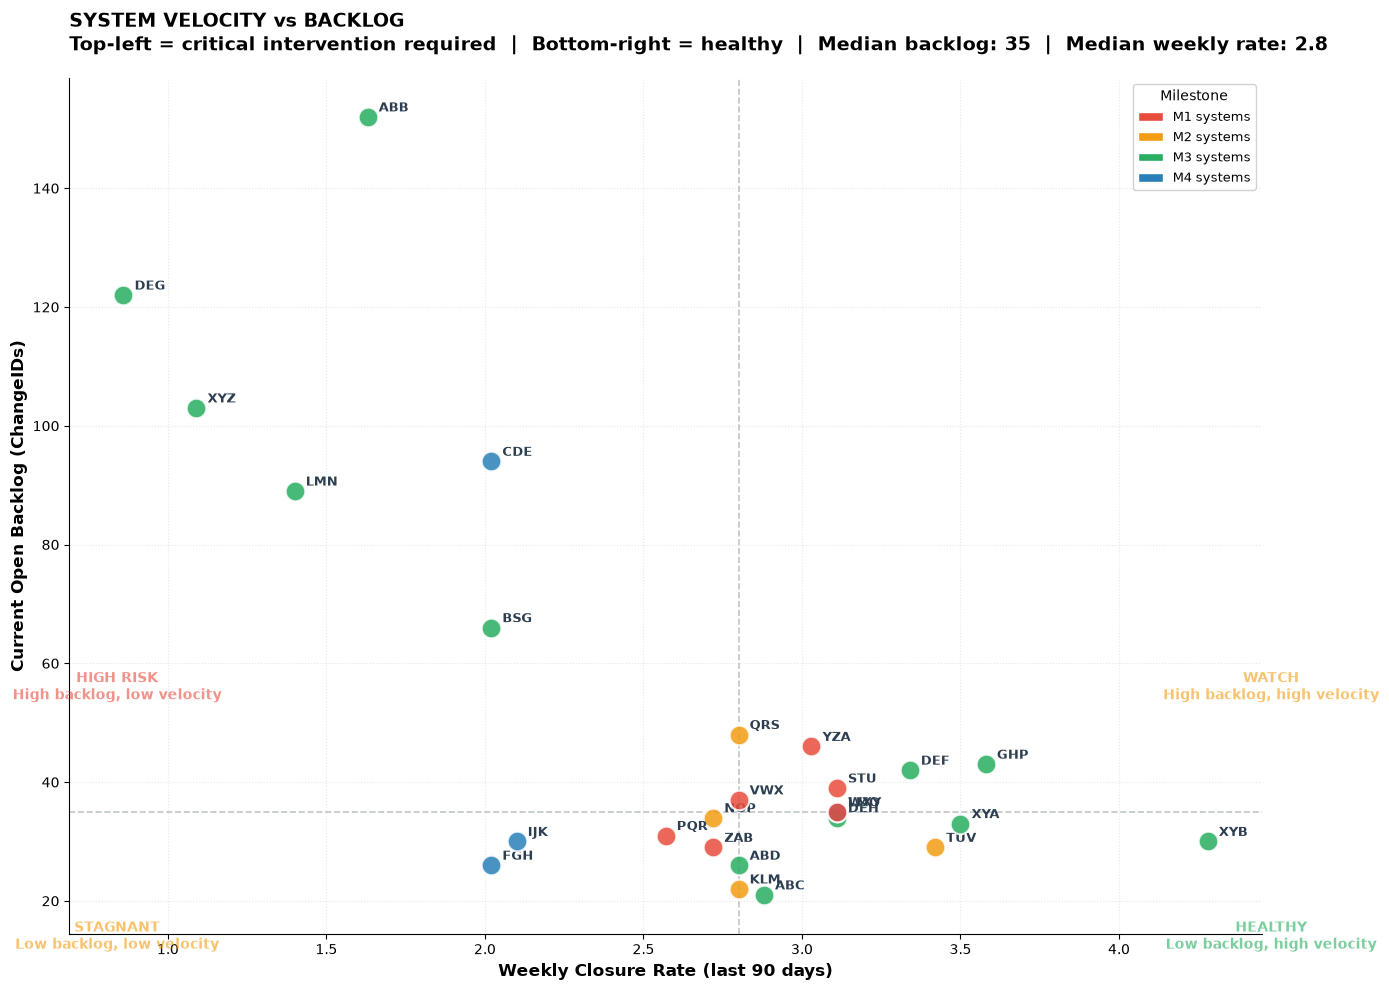

In [10]:
# ==============================================================================
# CELL 9b — LEAD TIME BY MILESTONE SECTION
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── Build system-level metrics ────────────────────────────────────────────────
lookback = ts_sim_today - pd.Timedelta(days=90)

# Open backlog per system
backlog = (
    fact_enriched[fact_enriched['Status'] != 'Closed']
    .merge(systems_bridge, on='ChangeID', how='left')
    .merge(systems_master, on='SystemCode', how='left')
    .groupby('SystemCode')['ChangeID'].nunique()
    .reset_index(name='Open_Backlog')
)

# Recent closure rate per system (last 90 days)
velocity = (
    fact_enriched[
        (fact_enriched['Status'] == 'Closed') &
        (fact_enriched['DateClosed'] >= lookback) &
        (fact_enriched['DateClosed'] <= ts_sim_today)
    ]
    .merge(systems_bridge, on='ChangeID', how='left')
    .groupby('SystemCode')['ChangeID'].nunique()
    .reset_index(name='Recent_Closures')
)
velocity['Weekly_Rate'] = (velocity['Recent_Closures'] / 90 * 7).round(2)

# Merge milestone context
scatter_df = (
    backlog
    .merge(velocity[['SystemCode', 'Weekly_Rate']], on='SystemCode', how='left')
    .merge(systems_master, on='SystemCode', how='left')
)
scatter_df['Weekly_Rate'] = scatter_df['Weekly_Rate'].fillna(0)

M_COLORS = {'M1': '#e74c3c', 'M2': '#f39c12', 'M3': '#27ae60', 'M4': '#2980b9'}

# ── Quadrant medians ──────────────────────────────────────────────────────────
median_backlog  = scatter_df['Open_Backlog'].median()
median_velocity = scatter_df['Weekly_Rate'].median()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

for _, row in scatter_df.iterrows():
    color = M_COLORS.get(row['Milestone_ID'], '#7f8c8d')
    ax.scatter(row['Weekly_Rate'], row['Open_Backlog'],
               color=color, s=200, alpha=0.85,
               edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(row['SystemCode'],
                (row['Weekly_Rate'], row['Open_Backlog']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, fontweight='bold', color='#2c3e50')

# Quadrant lines
ax.axvline(median_velocity, color='#7f8c8d',
           linestyle='--', linewidth=1.2, alpha=0.5)
ax.axhline(median_backlog, color='#7f8c8d',
           linestyle='--', linewidth=1.2, alpha=0.5)

# Quadrant labels — plain text, no emojis
quadrant_labels = [
    (median_velocity * 0.3,  median_backlog * 1.6,  'HIGH RISK\nHigh backlog, low velocity',  '#e74c3c'),
    (median_velocity * 1.6,  median_backlog * 1.6,  'WATCH\nHigh backlog, high velocity',     '#f39c12'),
    (median_velocity * 0.3,  median_backlog * 0.4,  'STAGNANT\nLow backlog, low velocity',    '#f39c12'),
    (median_velocity * 1.6,  median_backlog * 0.4,  'HEALTHY\nLow backlog, high velocity',    '#27ae60'),
]

for x, y, label, color in quadrant_labels:
    ax.text(x, y, label, fontsize=10, color=color,
            fontweight='bold', alpha=0.6, ha='center', va='center')

m_patches = [
    mpatches.Patch(facecolor=M_COLORS[m], edgecolor='white', label=f'{m} systems')
    for m in ['M1', 'M2', 'M3', 'M4']
]
ax.legend(handles=m_patches, loc='upper right', fontsize=9,
          title='Milestone', framealpha=0.9)

ax.set_xlabel('Weekly Closure Rate (last 90 days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Current Open Backlog (ChangeIDs)', fontsize=12, fontweight='bold')
ax.set_title(
    'SYSTEM VELOCITY vs BACKLOG\n'
    'Top-left = critical intervention required  |  '
    'Bottom-right = healthy  |  '
    f'Median backlog: {int(median_backlog)}  |  '
    f'Median weekly rate: {median_velocity:.1f}',
    fontsize=14, fontweight='bold', loc='left', pad=20
)
ax.grid(linestyle=':', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

✅ System backlog — silver table: 1,296 rows | 708 unique open ChangeIDs | 26 systems
✅ PHYSICAL IMPACTS: 347 unique open ChangeIDs


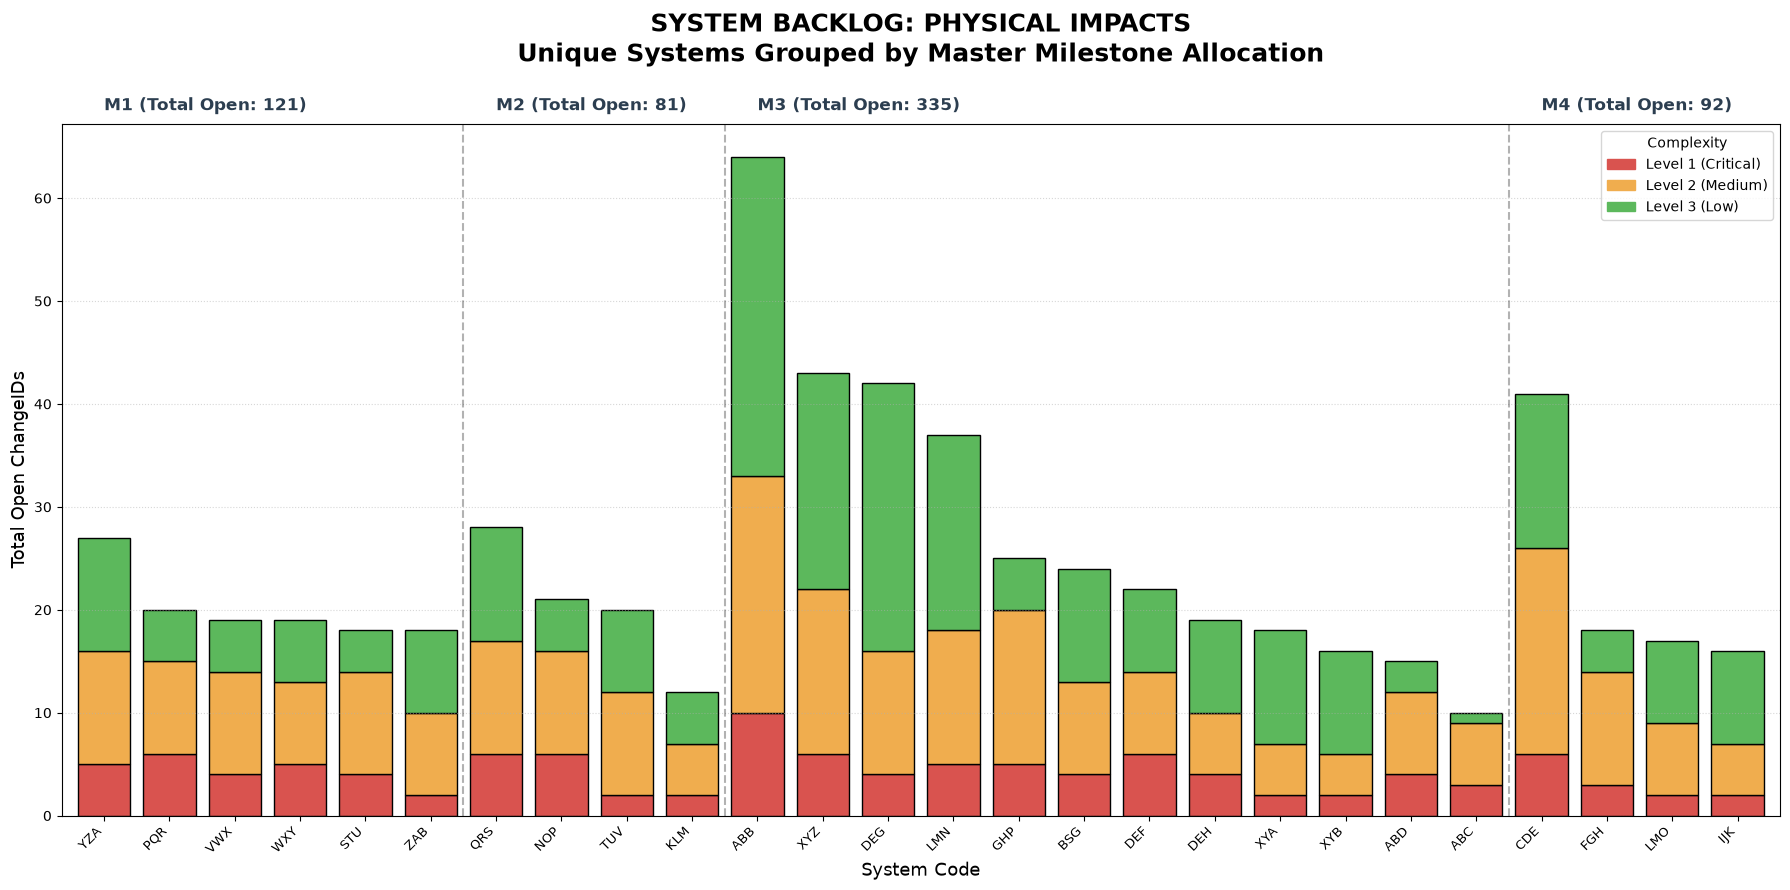

✅ NON-PHYSICAL IMPACTS: 361 unique open ChangeIDs


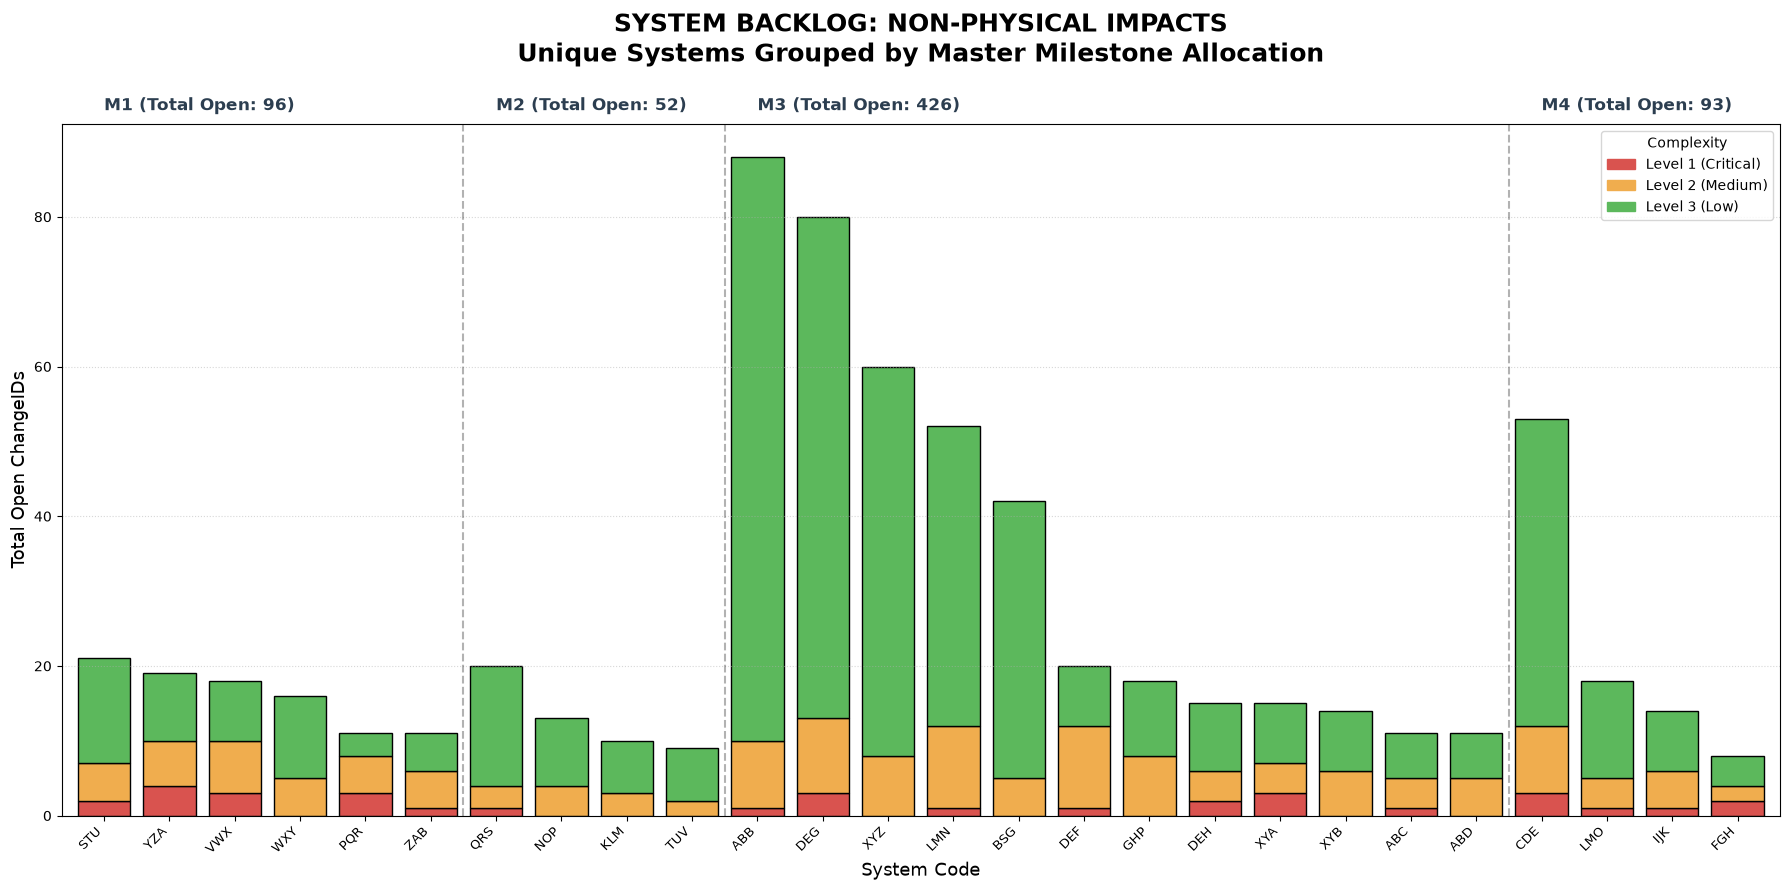

In [11]:
# ==============================================================================
# CELL 10 — SYSTEM BACKLOG CHART (Stacked Bar by System, grouped by Milestone)
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── SILVER TABLE — built once, consumed twice ─────────────────────────────────
# Join chain: fact_enriched (open only) → systems_bridge → systems_master
# LEFT JOIN throughout — unassigned changes appear as UNASSIGNED.
# Physical_Impacts filter applied inside the plot function so the join
# runs once and feeds both physical and non-physical charts.

system_anchor = pd.read_sql(
    "SELECT SystemCode, Milestone_ID AS Anchor_MS FROM systems_master", conn
)

df_system_open = (
    fact_enriched[fact_enriched['Status'].str.upper() != 'CLOSED']
    .merge(systems_bridge, on='ChangeID', how='left')
    .merge(system_anchor,  on='SystemCode', how='left')
)
df_system_open['SystemCode'] = df_system_open['SystemCode'].fillna('UNASSIGNED')
df_system_open['Anchor_MS']  = df_system_open['Anchor_MS'].fillna('UNKNOWN')
df_system_open['Physical_Impacts'] = df_system_open['Physical_Impacts'].astype(int)

print(f"✅ System backlog — silver table: {len(df_system_open):,} rows | "
      f"{df_system_open['ChangeID'].nunique():,} unique open ChangeIDs | "
      f"{df_system_open['SystemCode'].nunique()} systems")

# ── PLOT FUNCTION ─────────────────────────────────────────────────────────────
def plot_system_backlog(df_source, impact_bool, title_label):
    """
    Stacked bar chart showing open change backlog per unique system,
    grouped and sorted by their Master Milestone allocation.

    df_source   : pre-built silver table at ChangeID × SystemCode grain
    impact_bool : 1 = physical, 0 = non-physical
    title_label : string for chart title
    """
    # ── 1. Filter by impact type ───────────────────────────────────────────────
    subset = df_source[df_source['Physical_Impacts'] == impact_bool].copy()

    if subset.empty:
        print(f'No data for {title_label}')
        return

    print(f"✅ {title_label}: {subset['ChangeID'].nunique():,} unique open ChangeIDs")

    # ── 2. Aggregate backlog by System × Level ─────────────────────────────────
    counts = (
        subset.groupby(['SystemCode', 'Level'])['ChangeID']
        .nunique()
        .unstack(fill_value=0)
    )

    for lvl in [1, 2, 3]:
        if lvl not in counts.columns:
            counts[lvl] = 0

    # ── 3. Merge milestone anchor and sort ─────────────────────────────────────
    counts = (
        counts.reset_index()
        .merge(system_anchor, on='SystemCode', how='left')
    )
    counts['Total']    = counts[1] + counts[2] + counts[3]
    counts['Anchor_MS'] = counts['Anchor_MS'].fillna('UNKNOWN')
    counts = counts.sort_values(
        by=['Anchor_MS', 'Total'], ascending=[True, False]
    )

    # ── 4. Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(18, 9))
    bar_colors = ['#d9534f', '#f0ad4e', '#5cb85c']

    counts.set_index('SystemCode')[[1, 2, 3]].plot(
        kind='bar', stacked=True, ax=ax,
        color=bar_colors, edgecolor='black', width=0.8
    )

    # Milestone section dividers and headers
    prev_m    = None
    milestones = counts['Anchor_MS'].values
    ms_totals  = counts.groupby('Anchor_MS')['Total'].sum()

    for idx, m in enumerate(milestones):
        if m != prev_m:
            if idx > 0:
                ax.axvline(idx - 0.5, color='black',
                           linestyle='--', linewidth=1.5, alpha=0.3)
            section_total = ms_totals.get(m, 0)
            ax.text(idx, ax.get_ylim()[1] * 1.02,
                    f'{m} (Total Open: {int(section_total)})',
                    fontweight='bold', fontsize=12,
                    color='#2c3e50', ha='left')
        prev_m = m

    plt.title(
        f'SYSTEM BACKLOG: {title_label}\n'
        f'Unique Systems Grouped by Master Milestone Allocation',
        fontsize=18, fontweight='bold', pad=45
    )
    plt.ylabel('Total Open ChangeIDs', fontsize=13)
    plt.xlabel('System Code', fontsize=13)

    patch1 = mpatches.Patch(color='#d9534f', label='Level 1 (Critical)')
    patch2 = mpatches.Patch(color='#f0ad4e', label='Level 2 (Medium)')
    patch3 = mpatches.Patch(color='#5cb85c', label='Level 3 (Low)')
    plt.legend(handles=[patch1, patch2, patch3],
               title='Complexity', loc='upper right')

    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ── RUN ───────────────────────────────────────────────────────────────────────
plot_system_backlog(df_system_open, 1, 'PHYSICAL IMPACTS')
plot_system_backlog(df_system_open, 0, 'NON-PHYSICAL IMPACTS')

✅ All open changes have a system assignment
✅ All open changes have a milestone assignment
✅ df_precision: 1,296 rows | 708 unique open changes | fan-out: 1.83x
✅ df_closed_recent: 483 changes closed in last 90 days | 26 systems
✅ closure_rate: 26 systems with closures in last 90 days
wrote gold_system_physical       26 rows -> data/gold/gold_system_physical.parquet  (from: fact_enriched)
wrote gold_system_non_physical     26 rows -> data/gold/gold_system_non_physical.parquet  (from: fact_enriched)
wrote gold_master_action_list    708 rows -> data/gold/gold_master_action_list.parquet  (from: fact_enriched)


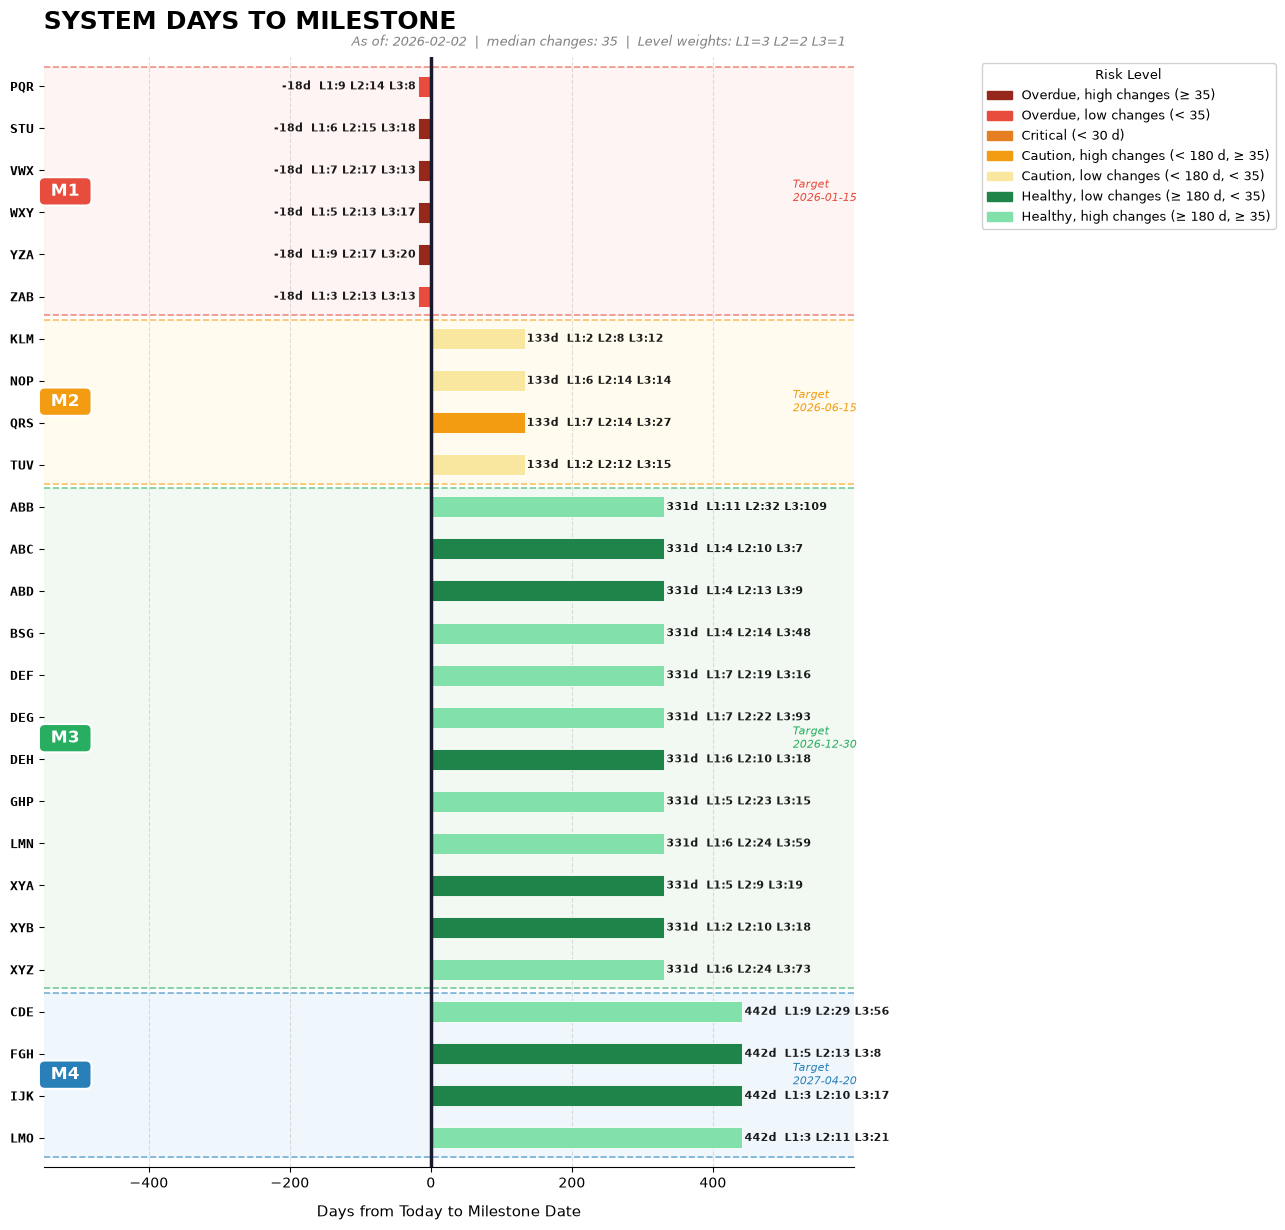

,SystemCode,Level,Avg_Age,Min_Age,Max_Age,ID_Count,Milestone_ID,Score
0,YZA,1,321,116,587,5,M1,1607
1,YZA,2,137,39,316,11,M1,1503
2,YZA,3,125,41,346,11,M1,1376
3,WXY,1,313,176,412,5,M1,1564
4,WXY,2,167,59,315,8,M1,1339
5,WXY,3,198,52,371,6,M1,1187
6,STU,1,307,40,412,4,M1,1229
7,STU,2,176,48,389,10,M1,1759
8,STU,3,83,38,155,4,M1,333
9,VWX,1,227,129,331,4,M1,907


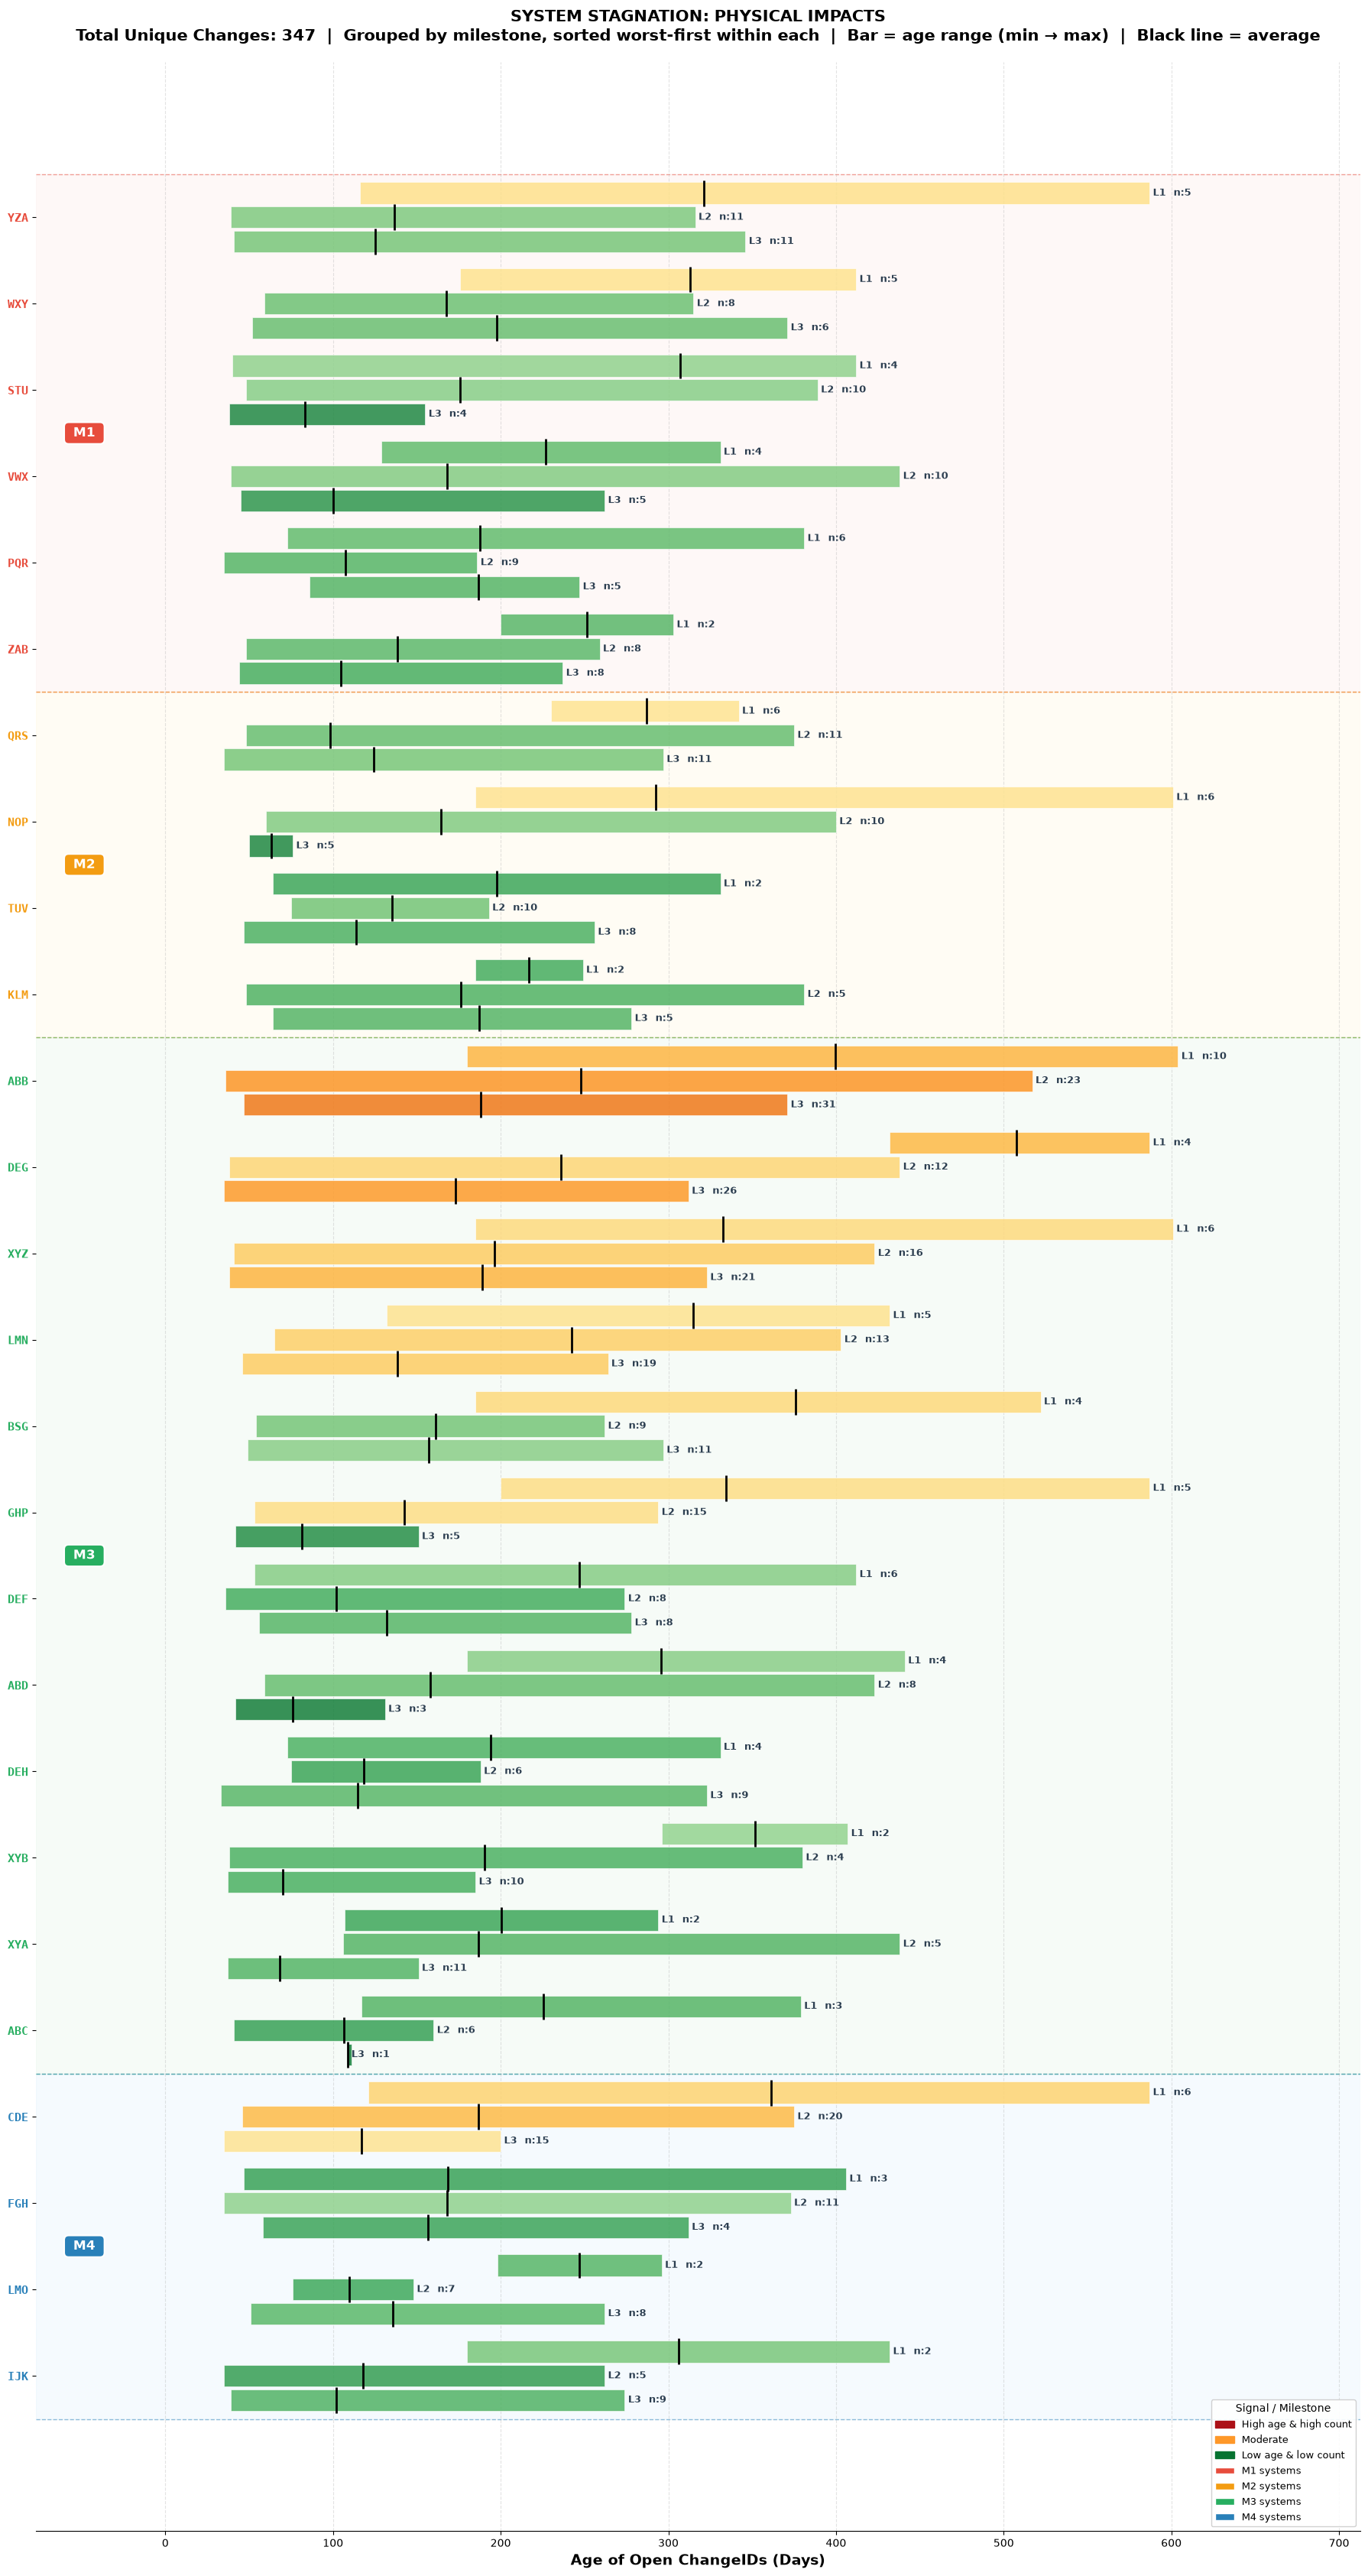

,SystemCode,Level,Avg_Age,Min_Age,Max_Age,ID_Count,Milestone_ID,Score
0,YZA,1,155,70,226,4,M1,620
1,YZA,2,208,54,401,6,M1,1248
2,YZA,3,132,39,276,9,M1,1184
3,VWX,1,209,115,285,3,M1,627
4,VWX,2,125,36,401,7,M1,873
5,VWX,3,136,66,196,8,M1,1092
6,WXY,2,96,45,261,5,M1,482
7,WXY,3,165,36,316,11,M1,1820
8,STU,1,146,115,178,2,M1,293
9,STU,2,52,40,68,5,M1,262


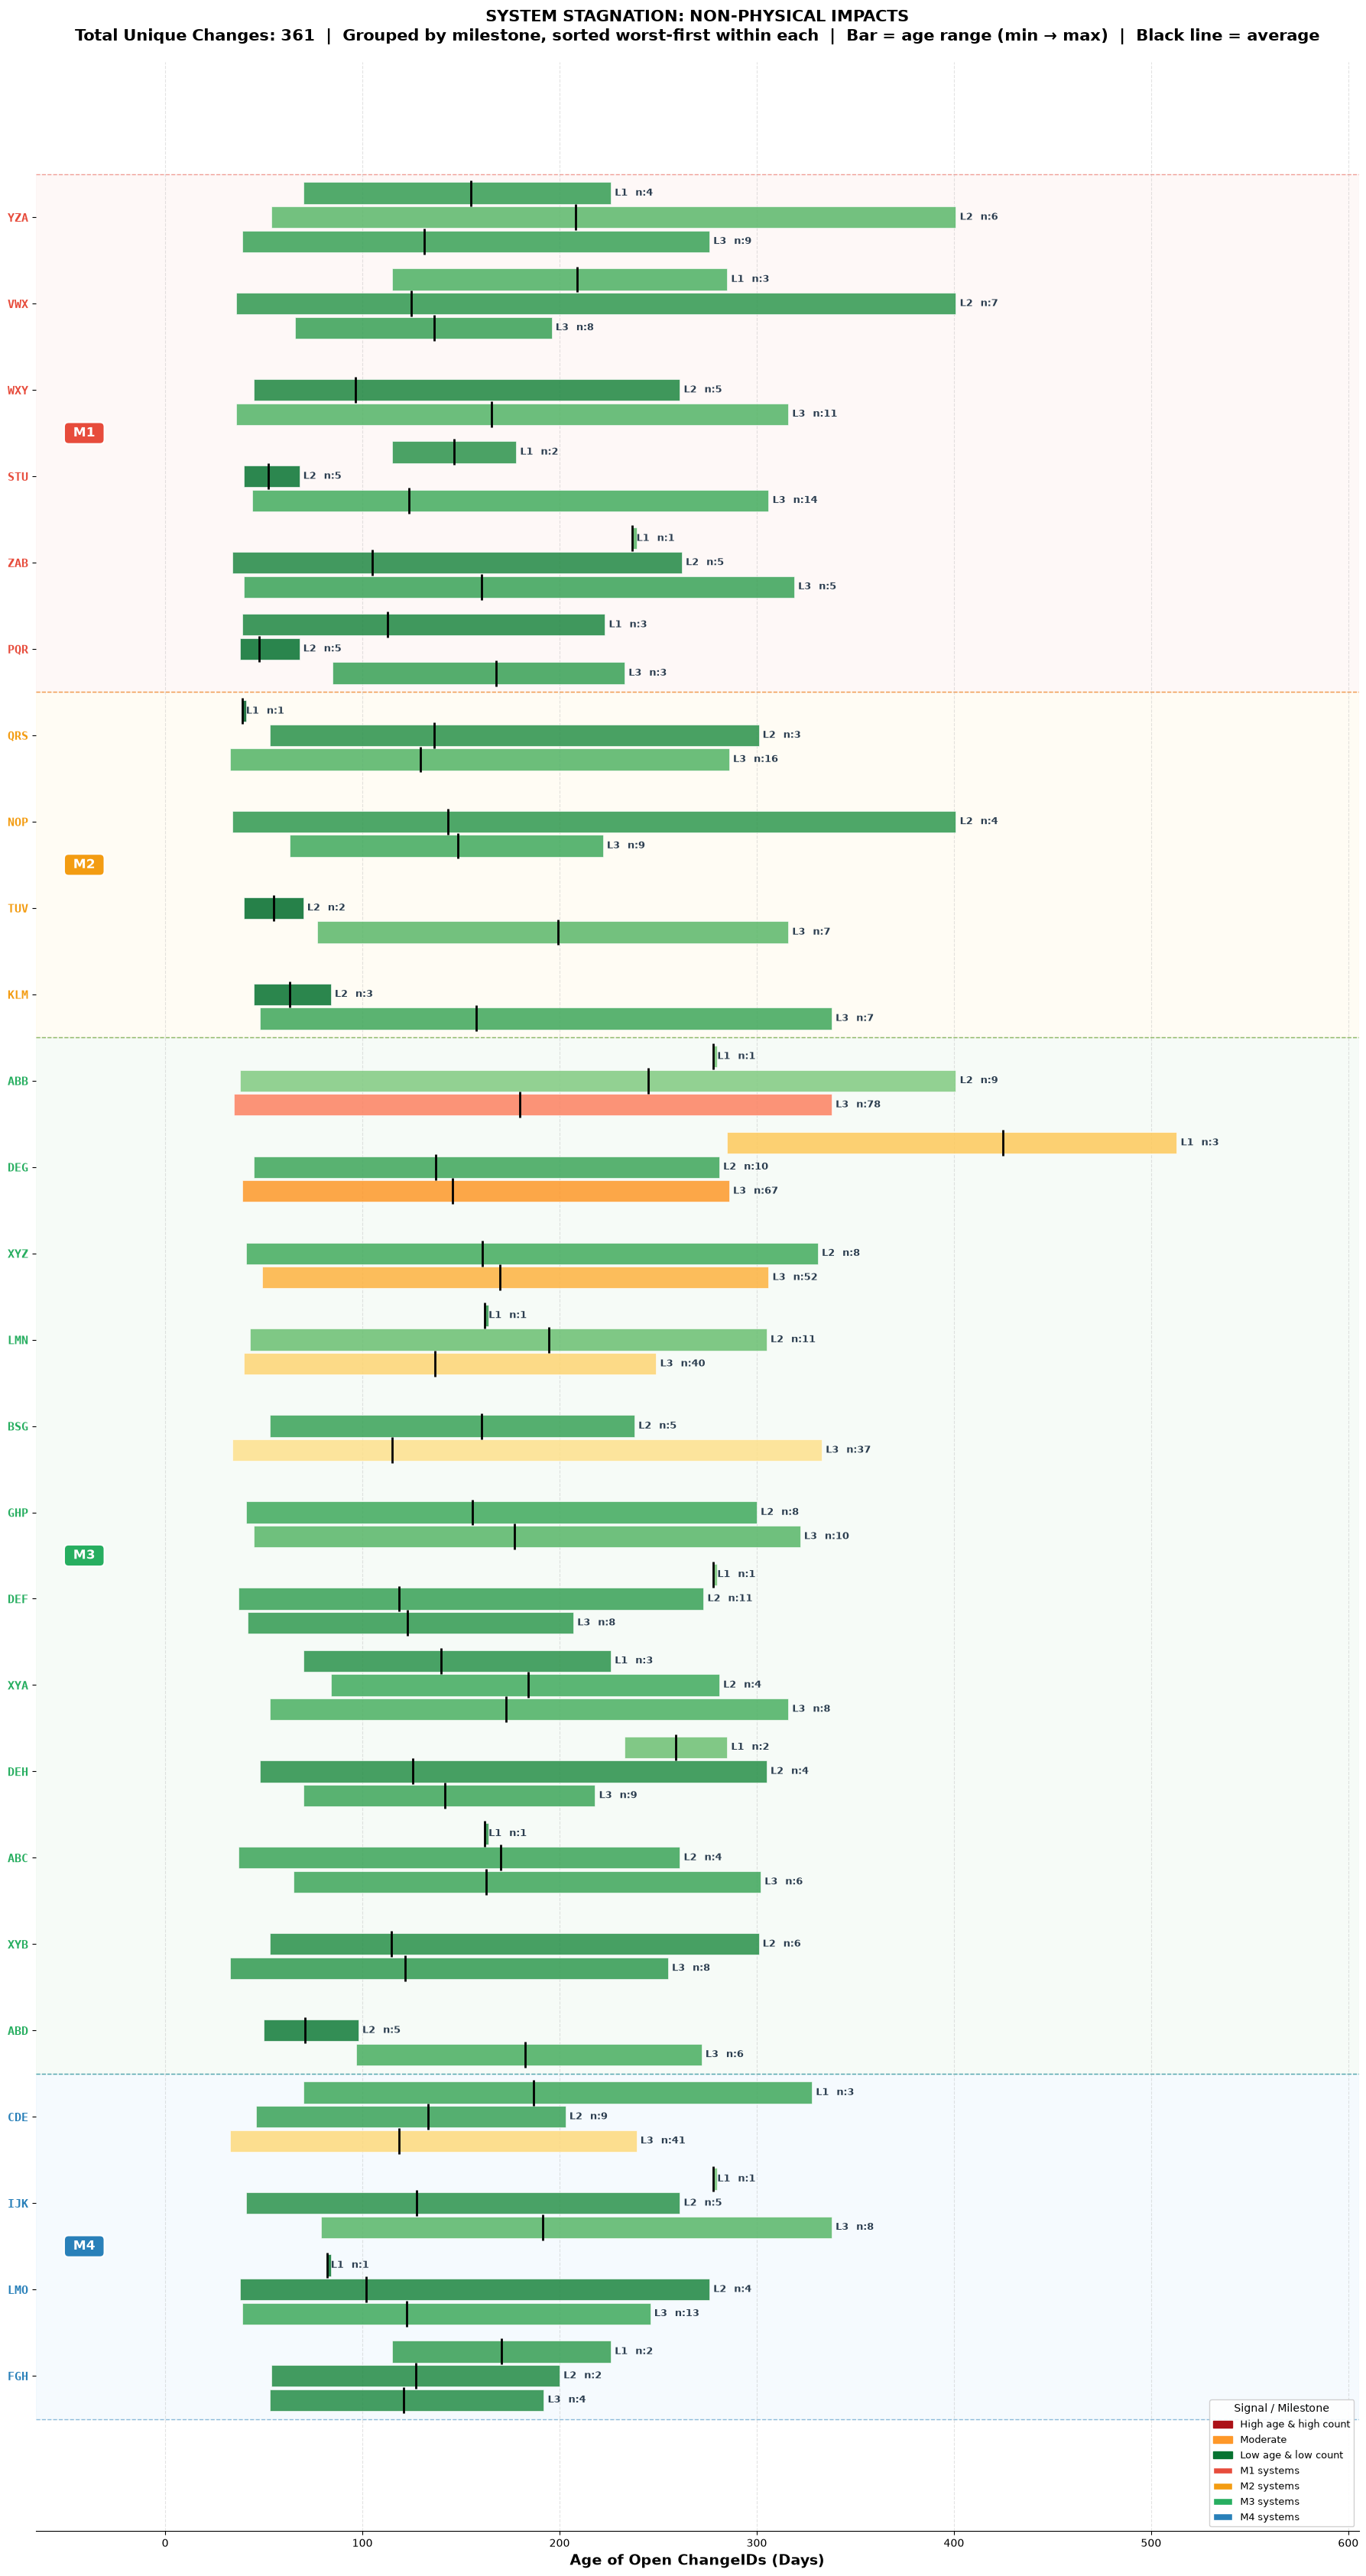

,Milestone,Target Date,System,Open Changes,L1,L2,L3,Days to Milestone,Closures/Week,Risk,Stagnation_Score,Current_Rate_Weekly,On_Track,Combined_Risk
0,M1,2026-01-15 00:00:00,PQR,20,6,9,5,-18,∞ OVERDUE,OVERDUE,8240,2.57,OVERDUE,MEDIUM
1,M1,2026-01-15 00:00:00,STU,18,4,10,4,-18,∞ OVERDUE,OVERDUE,10672,3.11,OVERDUE,MEDIUM
2,M1,2026-01-15 00:00:00,VWX,19,4,10,5,-18,∞ OVERDUE,OVERDUE,11303,2.80,OVERDUE,HIGH
3,M1,2026-01-15 00:00:00,WXY,19,5,8,6,-18,∞ OVERDUE,OVERDUE,11341,3.11,OVERDUE,HIGH
4,M1,2026-01-15 00:00:00,YZA,27,5,11,11,-18,∞ OVERDUE,OVERDUE,14743,3.03,OVERDUE,HIGH
5,M1,2026-01-15 00:00:00,ZAB,18,2,8,8,-18,∞ OVERDUE,OVERDUE,7129,2.72,OVERDUE,MEDIUM
6,M2,2026-06-15 00:00:00,KLM,12,2,5,5,133,0.63,CAUTION,5482,2.80,YES,MEDIUM
7,M2,2026-06-15 00:00:00,NOP,21,6,10,5,133,1.11,CAUTION,11347,2.72,YES,HIGH
8,M2,2026-06-15 00:00:00,QRS,28,6,11,11,133,1.47,CAUTION,11696,2.80,YES,HIGH
9,M2,2026-06-15 00:00:00,TUV,20,2,10,8,133,1.05,CAUTION,6419,3.42,YES,MEDIUM


,Milestone,Target Date,System,Open Changes,L1,L2,L3,Days to Milestone,Closures/Week,Risk,Stagnation_Score,Current_Rate_Weekly,On_Track,Combined_Risk
0,M1,2026-01-15 00:00:00,PQR,11,3,5,3,-18,∞ OVERDUE,OVERDUE,8240,2.57,OVERDUE,MEDIUM
1,M1,2026-01-15 00:00:00,STU,21,2,5,14,-18,∞ OVERDUE,OVERDUE,10672,3.11,OVERDUE,MEDIUM
2,M1,2026-01-15 00:00:00,VWX,18,3,7,8,-18,∞ OVERDUE,OVERDUE,11303,2.80,OVERDUE,HIGH
3,M1,2026-01-15 00:00:00,WXY,16,0,5,11,-18,∞ OVERDUE,OVERDUE,11341,3.11,OVERDUE,HIGH
4,M1,2026-01-15 00:00:00,YZA,19,4,6,9,-18,∞ OVERDUE,OVERDUE,14743,3.03,OVERDUE,HIGH
5,M1,2026-01-15 00:00:00,ZAB,11,1,5,5,-18,∞ OVERDUE,OVERDUE,7129,2.72,OVERDUE,MEDIUM
6,M2,2026-06-15 00:00:00,KLM,10,0,3,7,133,0.53,CAUTION,5482,2.80,YES,MEDIUM
7,M2,2026-06-15 00:00:00,NOP,13,0,4,9,133,0.68,CAUTION,11347,2.72,YES,HIGH
8,M2,2026-06-15 00:00:00,QRS,20,1,3,16,133,1.05,CAUTION,11696,2.80,YES,HIGH
9,M2,2026-06-15 00:00:00,TUV,9,0,2,7,133,0.47,CAUTION,6419,3.42,YES,MEDIUM


,ChangeID,Level,Physical_Impacts,Driving System,Milestone,Need Date,Days to Need Date,Risk
7040,C07041,2,True,PQR,M1,2025-01-15 00:00:00,-383,OVERDUE
6224,C06225,3,True,STU,M1,2025-01-15 00:00:00,-383,OVERDUE
12245,C12246,2,True,VWX,M1,2025-01-15 00:00:00,-383,OVERDUE
2218,C02219,1,True,STU,M1,2025-01-15 00:00:00,-383,OVERDUE
3010,C03011,2,True,PQR,M1,2025-01-15 00:00:00,-383,OVERDUE
4003,C04004,3,True,YZA,M1,2025-01-15 00:00:00,-383,OVERDUE
1740,C01741,3,True,ZAB,M1,2025-01-15 00:00:00,-383,OVERDUE
1341,C01342,3,True,VWX,M1,2025-01-15 00:00:00,-383,OVERDUE
8559,C08560,3,True,ZAB,M1,2025-01-15 00:00:00,-383,OVERDUE
3713,C03714,3,True,ZAB,M1,2025-01-15 00:00:00,-383,OVERDUE


In [12]:
# ==============================================================================
# CELL 11 — SYSTEM STAGNATION, MILESTONE COUNTDOWN & GOLD TABLES
# ==============================================================================
# Three outputs:
#   1. PLOT 1: System Days to Milestone — horizontal bar, days remaining per system
#   2. PLOT 2 & 3: System Stagnation — range bars, age × weighted count
#   3. GOLD TABLES — system grain (physical + non-physical) + ChangeID grain
#
# Silver table pattern:
#   df_active          ChangeID grain — open changes only
#   df_precision       ChangeID × SystemCode grain — open changes joined to system dims
#   df_closed_recent   ChangeID × SystemCode grain — closed last 90 days joined to system dims
#   closure_rate       SystemCode grain — aggregated from df_closed_recent
#   stagnation_agg     SystemCode × Level grain — aggregated from df_precision
#   summary            SystemCode grain — for countdown chart
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

# ── CONFIG ────────────────────────────────────────────────────────────────────
sim_today     = ts_sim_today
LEVEL_WEIGHTS = {1: 3, 2: 2, 3: 1}

M_COLORS  = {'M1': '#fdecea', 'M2': '#fff8e1', 'M3': '#e8f5e9', 'M4': '#e3f2fd'}
M_BORDERS = {'M1': '#e74c3c', 'M2': '#f39c12', 'M3': '#27ae60', 'M4': '#2980b9'}

RISK_COLORS = {
    'OVERDUE':  '#96281b',
    'CRITICAL': '#e67e22',
    'CAUTION':  '#f39c12',
    'HEALTHY':  '#1e8449',
    'UNKNOWN':  '#7f8c8d',
}

COMBINED_RISK_COLORS = {
    'HIGH':   '#96281b',
    'MEDIUM': '#f39c12',
    'LOW':    '#1e8449',
}

ON_TRACK_COLORS = {
    'YES':     '#1e8449',
    'NO':      '#c0392b',
    'OVERDUE': '#96281b',
}

GOLD_FORMAT = {
    'Days to Milestone':   '{:.0f}',
    'Closures/Week':       lambda x: '∞ OVERDUE' if x == np.inf else f'{x:.2f}',
    'Current_Rate_Weekly': '{:.2f}',
    'Stagnation_Score':    '{:.0f}',
    'L1':                  '{:.0f}',
    'L2':                  '{:.0f}',
    'L3':                  '{:.0f}',
}

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '16px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────
def get_color(days, cnt, median_count):
    high_cnt = cnt >= median_count
    if days < 0:   return '#96281b' if high_cnt else '#e74c3c'
    if days < 30:  return '#e67e22'
    if days < 180: return '#f39c12' if high_cnt else '#f9e79f'
    return                '#1e8449' if not high_cnt else '#82e0aa'

def get_risk(days):
    if pd.isna(days): return 'UNKNOWN'
    if days < 0:   return 'OVERDUE'
    if days < 30:  return 'CRITICAL'
    if days < 180: return 'CAUTION'
    return                'HEALTHY'

def get_stagnation_bar_color(avg_age, id_count, max_age, max_count):
    age_ratio   = avg_age  / max_age   if max_age   > 0 else 0
    count_ratio = id_count / max_count if max_count > 0 else 0
    score       = (age_ratio + count_ratio) / 2
    if score >= 0.66:
        intensity = 0.4 + 0.6 * ((score - 0.66) / 0.34)
        return plt.get_cmap('Reds')(intensity)
    elif score >= 0.33:
        intensity = 0.4 + 0.6 * ((score - 0.33) / 0.33)
        return plt.get_cmap('YlOrBr')(intensity * 0.6)
    else:
        intensity = 0.4 + 0.6 * (1 - (score / 0.33))
        return plt.get_cmap('Greens')(intensity)


# ==============================================================================
# SILVER — df_active
# Grain: ChangeID — open changes only
# ==============================================================================

df_active = fact_enriched[fact_enriched['Status'] != 'Closed'].copy()
df_active['Level'] = pd.to_numeric(
    df_active['Level'], errors='coerce'
).fillna(0).astype(int)
df_active = df_active[[
    'ChangeID', 'Level', 'Physical_Impacts',
    'Current_Age_Days', 'Actual_Need_Date'
]]

# ==============================================================================
# SILVER — df_precision
# Grain: ChangeID × SystemCode — open changes joined to system dimensions
# Built once — feeds stagnation, countdown, and gold tables
# ==============================================================================

df_precision = (
    df_active
    .merge(systems_bridge, on='ChangeID',     how='left')
    .merge(systems_master,  on='SystemCode',   how='left')
    .merge(df_milestones,   on='Milestone_ID', how='left')
)

df_precision['SystemCode']   = df_precision['SystemCode'].fillna('UNASSIGNED')
df_precision['Milestone_ID'] = df_precision['Milestone_ID'].fillna('UNKNOWN')

df_precision['Days_to_Milestone'] = (
    df_precision['Project_Target_Date'] - sim_today
).dt.days
df_precision['Days_to_Need'] = (
    df_precision['Actual_Need_Date'] - sim_today
).dt.days
df_precision['Physical_Impacts'] = df_precision['Physical_Impacts'].astype(bool)

# ── COVERAGE CHECKS ───────────────────────────────────────────────────────────
unassigned = df_precision[df_precision['SystemCode'] == 'UNASSIGNED']
if len(unassigned) > 0:
    print(f"⚠️  {unassigned['ChangeID'].nunique():,} open changes have no system assignment")
else:
    print("✅ All open changes have a system assignment")

unknown_milestone = df_precision[df_precision['Milestone_ID'] == 'UNKNOWN']
if len(unknown_milestone) > 0:
    print(f"⚠️  {unknown_milestone['ChangeID'].nunique():,} open changes have no milestone")
else:
    print("✅ All open changes have a milestone assignment")

print(f"✅ df_precision: {len(df_precision):,} rows | "
      f"{df_precision['ChangeID'].nunique():,} unique open changes | "
      f"fan-out: {len(df_precision)/df_precision['ChangeID'].nunique():.2f}x")


# ==============================================================================
# SILVER — df_closed_recent
# Grain: ChangeID × SystemCode — changes closed in last 90 days
# Built once — feeds closure_rate aggregation
# Follows same pattern as df_precision — join chain runs once,
# aggregation reads from named silver table rather than inline join
# ==============================================================================

lookback_start = sim_today - pd.Timedelta(days=90)

df_closed_recent = (
    fact_enriched[
        (fact_enriched['Status'] == 'Closed') &
        (fact_enriched['DateClosed'] >= lookback_start) &
        (fact_enriched['DateClosed'] <= sim_today)
    ][['ChangeID', 'DateClosed']]
    .merge(systems_bridge, on='ChangeID', how='left')
    .merge(systems_master,  on='SystemCode', how='left')
)
df_closed_recent = df_closed_recent[
    df_closed_recent['SystemCode'].notna()
].copy()

print(f"✅ df_closed_recent: {df_closed_recent['ChangeID'].nunique():,} "
      f"changes closed in last 90 days | "
      f"{df_closed_recent['SystemCode'].nunique()} systems")


# ==============================================================================
# STAGNATION SCORES
# Grain: SystemCode × Level → aggregated to SystemCode
# Score = Avg_Age × (ID_Count × Level_Weight)
# ==============================================================================

stagnation_agg = (
    df_precision[df_precision['SystemCode'] != 'UNASSIGNED']
    .groupby(['SystemCode', 'Level'])
    .agg(
        Avg_Age  = ('Current_Age_Days', 'mean'),
        ID_Count = ('ChangeID',         'nunique')
    )
    .reset_index()
)
stagnation_agg['Level_Weight']     = stagnation_agg['Level'].map(LEVEL_WEIGHTS)
stagnation_agg['Weighted_Count']   = (
    stagnation_agg['ID_Count'] * stagnation_agg['Level_Weight']
)
stagnation_agg['Stagnation_Score'] = (
    stagnation_agg['Avg_Age'] * stagnation_agg['Weighted_Count']
)

stagnation        = stagnation_agg.groupby('SystemCode')['Stagnation_Score'].sum().reset_index()
stagnation_median = stagnation['Stagnation_Score'].median()


# ==============================================================================
# CURRENT CLOSURE RATE (last 90 days)
# Aggregated from df_closed_recent — join already done above
# ==============================================================================

closure_rate = (
    df_closed_recent
    .groupby('SystemCode')
    .agg(Recent_Closures=('ChangeID', 'nunique'))
    .reset_index()
)
closure_rate['Current_Rate_Weekly'] = (
    closure_rate['Recent_Closures'] / 90 * 7
).round(2)
closure_rate = closure_rate[['SystemCode', 'Current_Rate_Weekly']]

print(f"✅ closure_rate: {len(closure_rate)} systems with closures in last 90 days")


# ==============================================================================
# SUMMARY — FOR MILESTONE COUNTDOWN CHART
# Grain: Milestone_ID × Project_Target_Date × SystemCode
# ==============================================================================

summary = (
    df_precision[df_precision['SystemCode'] != 'UNASSIGNED']
    .groupby(['Milestone_ID', 'Project_Target_Date', 'SystemCode'])
    .agg(ChangeCount=('ChangeID', 'nunique'))
    .reset_index()
)

level_counts = (
    df_precision[df_precision['SystemCode'] != 'UNASSIGNED']
    .groupby(['SystemCode', 'Level'])
    .agg(LevelCount=('ChangeID', 'nunique'))
    .reset_index()
    .pivot(index='SystemCode', columns='Level', values='LevelCount')
    .fillna(0)
    .rename(columns={1: 'L1', 2: 'L2', 3: 'L3'})
    .reset_index()
)
for col in ['L1', 'L2', 'L3']:
    if col not in level_counts.columns:
        level_counts[col] = 0

summary           = summary.merge(level_counts, on='SystemCode', how='left')
summary['Buffer'] = (summary['Project_Target_Date'] - sim_today).dt.days
summary           = summary.sort_values(
    ['Project_Target_Date', 'Buffer'], ascending=[True, True]
)
median_count = summary['ChangeCount'].median()

summary['Closure_Rate_Weekly'] = summary.apply(
    lambda x: round((x['ChangeCount'] / x['Buffer']) * 7, 2)
    if x['Buffer'] > 0 else np.inf, axis=1
)
summary['Risk'] = summary['Buffer'].apply(get_risk)


# ==============================================================================
# GOLD TABLE BUILD FUNCTION
# ==============================================================================

def build_gold(df_subset):
    df_subset = df_subset[df_subset['SystemCode'] != 'UNASSIGNED']

    sub_summary = (
        df_subset
        .groupby(['Milestone_ID', 'Project_Target_Date', 'SystemCode'])
        .agg(ChangeCount=('ChangeID', 'nunique'))
        .reset_index()
    )
    sub_level_counts = (
        df_subset
        .groupby(['SystemCode', 'Level'])
        .agg(LevelCount=('ChangeID', 'nunique'))
        .reset_index()
        .pivot(index='SystemCode', columns='Level', values='LevelCount')
        .fillna(0)
        .rename(columns={1: 'L1', 2: 'L2', 3: 'L3'})
        .reset_index()
    )
    for col in ['L1', 'L2', 'L3']:
        if col not in sub_level_counts.columns:
            sub_level_counts[col] = 0

    sub_summary           = sub_summary.merge(
        sub_level_counts, on='SystemCode', how='left'
    )
    sub_summary['Buffer'] = (
        sub_summary['Project_Target_Date'] - sim_today
    ).dt.days
    sub_summary['Closure_Rate_Weekly'] = sub_summary.apply(
        lambda x: round((x['ChangeCount'] / x['Buffer']) * 7, 2)
        if x['Buffer'] > 0 else np.inf, axis=1
    )
    sub_summary['Risk'] = sub_summary['Buffer'].apply(get_risk)

    result = sub_summary.rename(columns={
        'Milestone_ID':        'Milestone',
        'Project_Target_Date': 'Target Date',
        'SystemCode':          'System',
        'Buffer':              'Days to Milestone',
        'ChangeCount':         'Open Changes',
        'Closure_Rate_Weekly': 'Closures/Week',
    })

    result = result.merge(
        stagnation.rename(columns={'SystemCode': 'System'}),
        on='System', how='left'
    )
    result = result.merge(
        closure_rate.rename(columns={'SystemCode': 'System'}),
        on='System', how='left'
    )
    result['Current_Rate_Weekly'] = result['Current_Rate_Weekly'].fillna(0)

    result['On_Track'] = result.apply(
        lambda x: 'OVERDUE' if x['Closures/Week'] == np.inf
             else 'YES'     if x['Current_Rate_Weekly'] >= x['Closures/Week']
             else 'NO',
        axis=1
    )

    result['Combined_Risk'] = result.apply(
        lambda x: 'HIGH'   if (
            x['Days to Milestone'] < 180 and
            x['Stagnation_Score'] > stagnation_median
        )
             else 'MEDIUM' if (
            x['Days to Milestone'] < 180 or
            x['Stagnation_Score'] > stagnation_median
        )
             else 'LOW',
        axis=1
    )

    return result.sort_values(
        ['Milestone', 'Days to Milestone'], ascending=[True, True]
    )


true_unique_physical     = (
    df_precision[df_precision['Physical_Impacts'] == True]['ChangeID'].nunique()
)
true_unique_non_physical = (
    df_precision[df_precision['Physical_Impacts'] == False]['ChangeID'].nunique()
)

gold_physical     = build_gold(
    df_precision[df_precision['Physical_Impacts'] == True]
)
gold_non_physical = build_gold(
    df_precision[df_precision['Physical_Impacts'] == False]
)

# ── persist gold layer ───────────────────────────────────────────────────────
import sys
sys.path.insert(0, str(ROOT / "src"))
from lineage import write_layer

write_layer(gold_physical, "gold_system_physical", ROOT / "data" / "gold", sources=["fact_enriched"])
write_layer(gold_non_physical, "gold_system_non_physical", ROOT / "data" / "gold", sources=["fact_enriched"])


# ==============================================================================
# GOLD GRAIN — MASTER ACTION LIST
# Grain: ChangeID
# ==============================================================================

gold_grain = fact_enriched[fact_enriched['Status'] != 'Closed'][[
    'ChangeID', 'Level', 'Physical_Impacts',
    'Driving_System', 'Driving_Milestone',
    'Actual_Need_Date', 'Days_Until_Need'
]].copy()

gold_grain['Risk']              = gold_grain['Days_Until_Need'].apply(get_risk)
gold_grain['Physical_Impacts']  = gold_grain['Physical_Impacts'].astype(bool)
gold_grain['Driving_System']    = gold_grain['Driving_System'].fillna('UNASSIGNED')
gold_grain['Driving_Milestone'] = gold_grain['Driving_Milestone'].fillna('UNKNOWN')

gold_grain = gold_grain.rename(columns={
    'Driving_System':    'Driving System',
    'Driving_Milestone': 'Milestone',
    'Actual_Need_Date':  'Need Date',
    'Days_Until_Need':   'Days to Need Date',
}).sort_values(['Milestone', 'Days to Need Date'])

open_id_count = gold_grain['ChangeID'].nunique()

write_layer(gold_grain, "gold_master_action_list", ROOT / "data" / "gold", sources=["fact_enriched"])


# ==============================================================================
# PLOT 1 — SYSTEM DAYS TO MILESTONE
# ==============================================================================

systems   = summary['SystemCode'].tolist()[::-1]
n_systems = len(systems)
sys_idx   = {s: i for i, s in enumerate(systems)}

fig_h = max(8, n_systems * 0.4 + 2)
fig, ax = plt.subplots(figsize=(16, fig_h))

x_max = summary['Buffer'].abs().max() * 1.15

for (m_id, tgt_date), grp in summary.groupby(
        ['Milestone_ID', 'Project_Target_Date'], sort=False):
    idxs     = sorted([sys_idx[s] for s in grp['SystemCode']])
    bot, top = idxs[0] - 0.45, idxs[-1] + 0.45
    mid      = (bot + top) / 2

    ax.axhspan(bot, top, color=M_COLORS.get(m_id, '#f5f5f5'),
               alpha=0.55, zorder=0)
    for y in [bot, top]:
        ax.axhline(y, color=M_BORDERS.get(m_id, '#aaa'),
                   linewidth=1.2, linestyle='--', alpha=0.6, zorder=1)

    ax.text(-x_max * 1.02, mid, f' {m_id} ',
            color='white', fontweight='bold', fontsize=12,
            va='center', ha='center', zorder=5,
            bbox=dict(facecolor=M_BORDERS.get(m_id, '#aaa'),
                      edgecolor='white', boxstyle='round,pad=0.35',
                      linewidth=1.5))

    ax.text(x_max * 1.01, mid,
            f"Target\n{pd.Timestamp(tgt_date).strftime('%Y-%m-%d')}",
            color=M_BORDERS.get(m_id, '#555'), fontsize=8,
            va='center', ha='left', zorder=5, style='italic')

for _, row in summary.iterrows():
    days  = row['Buffer']
    cnt   = row['ChangeCount']
    y     = sys_idx[row['SystemCode']]
    l1    = int(row.get('L1', 0))
    l2    = int(row.get('L2', 0))
    l3    = int(row.get('L3', 0))
    color = get_color(days, cnt, median_count)

    ax.barh(y, days, height=0.5, color=color,
            edgecolor='white', linewidth=0.6, zorder=3)

    x_off = -3 if days < 0 else 3
    ha    = 'right' if days < 0 else 'left'
    ax.text(days + x_off, y,
            f"{int(days)}d  L1:{l1} L2:{l2} L3:{l3}",
            va='center', ha=ha, fontsize=8,
            fontweight='bold', color='#1a1a1a', zorder=4)

ax.set_yticks(range(n_systems))
ax.set_yticklabels(systems, fontsize=9, fontweight='bold',
                   fontfamily='monospace')
ax.set_xlim(-x_max * 1.08, x_max * 1.18)
ax.set_ylim(-0.7, n_systems - 0.3)
ax.axvline(0, color='#1a1a2e', linewidth=2.5, zorder=4)
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_xlabel("Days from Today to Milestone Date",
              fontsize=11, labelpad=10)
ax.set_title("SYSTEM DAYS TO MILESTONE",
             fontsize=18, fontweight='bold', pad=20, loc='left')
ax.text(0.99, 1.01,
        f"As of: {sim_today.date()}  |  median changes: {int(median_count)}  |  "
        f"Level weights: L1={LEVEL_WEIGHTS[1]} L2={LEVEL_WEIGHTS[2]} "
        f"L3={LEVEL_WEIGHTS[3]}",
        transform=ax.transAxes, ha='right',
        fontsize=9, color='gray', style='italic')

legend_patches = [
    mpatches.Patch(color='#96281b',
                   label=f'Overdue, high changes (≥ {int(median_count)})'),
    mpatches.Patch(color='#e74c3c',
                   label=f'Overdue, low changes (< {int(median_count)})'),
    mpatches.Patch(color='#e67e22', label='Critical (< 30 d)'),
    mpatches.Patch(color='#f39c12',
                   label=f'Caution, high changes (< 180 d, ≥ {int(median_count)})'),
    mpatches.Patch(color='#f9e79f',
                   label=f'Caution, low changes (< 180 d, < {int(median_count)})'),
    mpatches.Patch(color='#1e8449',
                   label=f'Healthy, low changes (≥ 180 d, < {int(median_count)})'),
    mpatches.Patch(color='#82e0aa',
                   label=f'Healthy, high changes (≥ 180 d, ≥ {int(median_count)})'),
]
ax.legend(handles=legend_patches, loc='upper left',
          bbox_to_anchor=(1.15, 1), framealpha=0.9,
          fontsize=9, title='Risk Level', title_fontsize=9)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('system_days_to_milestone.png', dpi=150, bbox_inches='tight')
plt.show()


# ==============================================================================
# PLOTS 2 & 3 — SYSTEM STAGNATION
# ==============================================================================

def plot_system_stagnation(df_subset, impact_label):
    if df_subset.empty:
        return

    df_subset = df_subset[df_subset['SystemCode'] != 'UNASSIGNED']

    agg = (
        df_subset
        .groupby(['SystemCode', 'Level'])
        .agg(
            Avg_Age      = ('Current_Age_Days', 'mean'),
            Min_Age      = ('Current_Age_Days', 'min'),
            Max_Age      = ('Current_Age_Days', 'max'),
            ID_Count     = ('ChangeID',         'nunique'),
            Milestone_ID = ('Milestone_ID',
                            lambda x: x.mode()[0] if len(x) > 0 else 'UNKNOWN')
        )
        .reset_index()
    )
    agg['Score'] = agg['Avg_Age'] * agg['ID_Count']

    sys_scores = (
        agg.groupby('SystemCode')
           .agg(Total_Score=('Score', 'sum'),
                Milestone_ID=('Milestone_ID', lambda x: x.mode()[0]))
           .reset_index()
    )

    milestone_order = ['M1', 'M2', 'M3', 'M4']
    sys_scores['M_Order'] = sys_scores['Milestone_ID'].map(
        {m: i for i, m in enumerate(milestone_order)}
    ).fillna(99)
    sys_scores = sys_scores.sort_values(
        ['M_Order', 'Total_Score'], ascending=[True, False]
    )

    ordered_systems = sys_scores['SystemCode'].tolist()
    agg['SystemCode'] = pd.Categorical(
        agg['SystemCode'], categories=ordered_systems, ordered=True
    )
    agg = agg.sort_values(['SystemCode', 'Level'])

    sys_milestone = sys_scores.set_index('SystemCode')['Milestone_ID'].to_dict()

    display(
        agg.reset_index(drop=True)
           .style
           .set_caption(f'System Stagnation Data: {impact_label}')
           .format({
               'Avg_Age': '{:.0f}', 'Min_Age': '{:.0f}',
               'Max_Age': '{:.0f}', 'ID_Count': '{:.0f}',
               'Score': '{:.0f}'
           })
           .set_table_styles(TABLE_STYLES)
    )

    unique_sys     = list(agg['SystemCode'].unique())
    max_age_glob   = agg['Max_Age'].max() or 1
    max_count_glob = agg['ID_Count'].max() or 1
    level_offsets  = {1: -0.28, 2: 0, 3: 0.28}

    fig, ax = plt.subplots(figsize=(18, max(10, len(unique_sys) * 1.3)))

    prev_m     = None
    band_start = 0
    bands      = []
    for idx, sys in enumerate(unique_sys):
        m = sys_milestone.get(sys, 'UNKNOWN')
        if m != prev_m:
            if prev_m is not None:
                bands.append((band_start, idx - 1, prev_m))
            band_start = idx
            prev_m     = m
    bands.append((band_start, len(unique_sys) - 1, prev_m))

    x_left_label = -max_age_glob * 0.08

    for (start, end, m_id) in bands:
        ax.axhspan(start - 0.5, end + 0.5,
                   color=M_COLORS.get(m_id, '#f5f5f5'),
                   alpha=0.35, zorder=0)
        for boundary in [start - 0.5, end + 0.5]:
            ax.axhline(boundary, color=M_BORDERS.get(m_id, '#aaa'),
                       linewidth=1.0, linestyle='--', alpha=0.5, zorder=1)
        mid = (start + end) / 2
        ax.text(x_left_label, mid, f' {m_id} ',
                color='white', fontweight='bold', fontsize=12,
                va='center', ha='center', zorder=5,
                bbox=dict(facecolor=M_BORDERS.get(m_id, '#aaa'),
                          edgecolor='white', boxstyle='round,pad=0.35',
                          linewidth=1.5))

    for _, row in agg.iterrows():
        sys_i = unique_sys.index(row['SystemCode'])
        y_pos = sys_i + level_offsets.get(row['Level'], 0)
        color = get_stagnation_bar_color(
            row['Avg_Age'], row['ID_Count'],
            max_age_glob, max_count_glob
        )

        bar_width = max(2, row['Max_Age'] - row['Min_Age'])
        ax.barh(y_pos, bar_width, left=row['Min_Age'],
                height=0.25, color=color, alpha=0.85,
                edgecolor='white', linewidth=0.5, zorder=3)

        ax.vlines(row['Avg_Age'], y_pos - 0.15, y_pos + 0.15,
                  color='black', linewidth=2, zorder=5)

        ax.text(row['Max_Age'] + 2, y_pos,
                f"L{int(row['Level'])}  n:{int(row['ID_Count'])}",
                va='center', ha='left', fontsize=9,
                fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(len(unique_sys)))
    ax.set_yticklabels(unique_sys, fontsize=11, fontweight='bold',
                       fontfamily='monospace')
    plt.draw()
    for tick, sys in zip(ax.get_yticklabels(), unique_sys):
        tick.set_color(
            M_BORDERS.get(sys_milestone.get(sys, 'UNKNOWN'), '#2c3e50')
        )

    ax.invert_yaxis()
    ax.set_xlim(x_left_label * 1.6, max_age_glob * 1.18)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)

    unassigned_count = df_precision[
        (df_precision['Physical_Impacts'] == (
            impact_label == 'PHYSICAL IMPACTS'
        )) &
        (df_precision['SystemCode'] == 'UNASSIGNED')
    ]['ChangeID'].nunique()

    ax.set_xlabel('Age of Open ChangeIDs (Days)',
                  fontweight='bold', fontsize=14)
    unassigned_suffix = (
        f'  |  ⚠️ {unassigned_count} changes unassigned'
        if unassigned_count > 0 else ''
    )
    ax.set_title(
        f'SYSTEM STAGNATION: {impact_label}\n'
        f'Total Unique Changes: {df_subset["ChangeID"].nunique():,}  |  '
        f'Grouped by milestone, sorted worst-first within each  |  '
        f'Bar = age range (min \u2192 max)  |  Black line = average'
        + unassigned_suffix,
        fontsize=15, fontweight='bold', pad=20
    )

    stag_patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),
                       label='High age & high count'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.5),
                       label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85),
                       label='Low age & low count'),
    ]
    m_patches = [
        mpatches.Patch(facecolor=M_BORDERS[m], edgecolor='white',
                       label=f'{m} systems')
        for m in milestone_order
        if m in sys_milestone.values()
    ]
    ax.legend(handles=stag_patches + m_patches,
              loc='lower right', framealpha=0.9,
              fontsize=9, title='Signal / Milestone')

    plt.tight_layout()
    plt.show()


plot_system_stagnation(
    df_precision[df_precision['Physical_Impacts'] == True],
    'PHYSICAL IMPACTS'
)
plot_system_stagnation(
    df_precision[df_precision['Physical_Impacts'] == False],
    'NON-PHYSICAL IMPACTS'
)


# ==============================================================================
# GOLD TABLE STYLING
# ==============================================================================

def style_gold(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)

    for i in df.index:
        styles.loc[i, :] = (
            f'background-color: {"#fffdf0" if i % 2 == 0 else "#fff9e0"}'
        )

    for i, val in df['Risk'].items():
        styles.loc[i, 'Risk'] = (
            f'background-color: {RISK_COLORS.get(val, "#000")}; '
            f'color: white; font-weight: bold'
        )

    for i, val in df['Combined_Risk'].items():
        styles.loc[i, 'Combined_Risk'] = (
            f'background-color: {COMBINED_RISK_COLORS.get(val, "#000")}; '
            f'color: white; font-weight: bold'
        )

    for i, val in df['On_Track'].items():
        styles.loc[i, 'On_Track'] = (
            f'background-color: {ON_TRACK_COLORS.get(val, "#000")}; '
            f'color: white; font-weight: bold'
        )

    max_rate = df['Closures/Week'].replace(np.inf, np.nan).max()
    for i, val in df['Closures/Week'].items():
        if val == np.inf:
            styles.loc[i, 'Closures/Week'] = (
                'background-color: #96281b; color: white; font-weight: bold'
            )
        elif pd.notna(max_rate) and val >= max_rate * 0.75:
            styles.loc[i, 'Closures/Week'] = (
                'color: #96281b; font-weight: bold'
            )

    for i in df.index:
        required = df.loc[i, 'Closures/Week']
        current  = df.loc[i, 'Current_Rate_Weekly']
        if required == np.inf:
            styles.loc[i, 'Current_Rate_Weekly'] = (
                'background-color: #96281b; color: white; font-weight: bold'
            )
        elif current < required:
            styles.loc[i, 'Current_Rate_Weekly'] = (
                'color: #c0392b; font-weight: bold'
            )
        else:
            styles.loc[i, 'Current_Rate_Weekly'] = (
                'color: #1e8449; font-weight: bold'
            )

    return styles


# ==============================================================================
# TABLE 1 — SYSTEM GRAIN: PHYSICAL IMPACTS
# ==============================================================================

display(
    gold_physical.style
        .apply(style_gold, axis=None)
        .set_caption(
            f"🥇 GOLD — System Grain: Physical Impacts  |  "
            f"Systems: {gold_physical['System'].nunique()}  |  "
            f"Unique Open Changes: {true_unique_physical:,}  |  "
            f"Note: system totals exceed unique count — "
            f"multi-system changes counted per system"
        )
        .format(GOLD_FORMAT)
        .set_table_styles(TABLE_STYLES)
)

# ==============================================================================
# TABLE 2 — SYSTEM GRAIN: NON-PHYSICAL IMPACTS
# ==============================================================================

display(
    gold_non_physical.style
        .apply(style_gold, axis=None)
        .set_caption(
            f"🥇 GOLD — System Grain: Non-Physical Impacts  |  "
            f"Systems: {gold_non_physical['System'].nunique()}  |  "
            f"Unique Open Changes: {true_unique_non_physical:,}  |  "
            f"Note: system totals exceed unique count — "
            f"multi-system changes counted per system"
        )
        .format(GOLD_FORMAT)
        .set_table_styles(TABLE_STYLES)
)

# ==============================================================================
# TABLE 3 — CHANGEID GRAIN: MASTER ACTION LIST
# ==============================================================================

def style_grain(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for i in df.index:
        styles.loc[i, :] = (
            f'background-color: {"#fffdf0" if i % 2 == 0 else "#fff9e0"}'
        )
    for i, val in df['Risk'].items():
        styles.loc[i, 'Risk'] = (
            f'background-color: {RISK_COLORS.get(val, "#000")}; '
            f'color: white; font-weight: bold'
        )
    return styles

display(
    gold_grain.style
        .apply(style_grain, axis=None)
        .set_caption(
            f"🥇 GOLD GRAIN — Master Action List: ChangeID Grain  |  "
            f"Total Open Changes: {open_id_count:,}  |  "
            f"Sorted by urgency — most overdue first"
        )
        .format({'Days to Need Date': '{:.0f}'})
        .set_table_styles(TABLE_STYLES)
)

In [13]:
# ==============================================================================
# CELL 12 — SYSTEM READINESS
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── CONFIG ────────────────────────────────────────────────────────────────────
SIM_TODAY = ts_sim_today  # from Cell 1 — single source of truth

M_COLORS  = {'M1': '#fdecea', 'M2': '#fff8e1', 'M3': '#e8f5e9', 'M4': '#e3f2fd'}
M_BORDERS = {'M1': '#e74c3c', 'M2': '#f39c12', 'M3': '#27ae60', 'M4': '#2980b9'}
LEVEL_COLORS = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}

RAG_RED   = 80
RAG_AMBER = 95

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '16px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

def get_rag_color(pct):
    if pct < RAG_RED:   return '#c0392b'
    if pct < RAG_AMBER: return '#f39c12'
    return                     '#1e8449'

# ── DATA PREPARATION ──────────────────────────────────────────────────────────
# LEFT joins — fact_enriched is the anchor, every ChangeID must appear.
# Changes with no system or milestone assignment appear as UNASSIGNED/UNKNOWN
# rather than being silently dropped. This ensures readiness percentages
# reflect the true programme population — not just the classified subset.
df_readiness = (
    fact_enriched[['ChangeID', 'Level', 'Physical_Impacts', 'Status']]
    .merge(systems_bridge, on='ChangeID',     how='left')
    .merge(systems_master,  on='SystemCode',   how='left')
    .merge(df_milestones,   on='Milestone_ID', how='left')
)

# Fill NULLs — unresolvable rows become explicit categories
df_readiness['SystemCode']           = df_readiness['SystemCode'].fillna('UNASSIGNED')
df_readiness['Milestone_ID']         = df_readiness['Milestone_ID'].fillna('UNKNOWN')
df_readiness['Project_Target_Date']  = df_readiness['Project_Target_Date'].fillna(pd.NaT)
df_readiness['Is_Closed']            = (df_readiness['Status'] == 'Closed').astype(int)

# ── COVERAGE CHECK ────────────────────────────────────────────────────────────
unassigned_count = df_readiness[df_readiness['SystemCode'] == 'UNASSIGNED']['ChangeID'].nunique()
if unassigned_count > 0:
    print(f"⚠️  {unassigned_count:,} changes have no system assignment — shown as UNASSIGNED")
else:
    print("✅ All changes have a system assignment")

# ── WIDGET SETUP ──────────────────────────────────────────────────────────────
system_list      = sorted([s for s in df_readiness['SystemCode'].unique() if s != 'UNASSIGNED'])
dropdown_options = ['ALL SYSTEMS'] + system_list + (['UNASSIGNED'] if unassigned_count > 0 else [])

dropdown = widgets.Dropdown(
    options=dropdown_options,
    value='ALL SYSTEMS',
    description='Scope:',
    style={'description_width': 'initial'},
    layout={'width': '350px'}
)

output = widgets.Output()

# ── DASHBOARD LOGIC ───────────────────────────────────────────────────────────
def update_dashboard(change):
    selected_scope = change['new']

    with output:
        clear_output(wait=True)

        if selected_scope == 'ALL SYSTEMS':
            # ─── VIEW A: PROJECT-WIDE HORIZONTAL BARS ───
            summary = df_readiness.groupby(
                ['Milestone_ID', 'Project_Target_Date', 'SystemCode']
            ).agg(
                Total_Changes  =('ChangeID', 'nunique'),
                Closed_Changes =('Is_Closed', 'sum')
            ).reset_index()

            summary['Readiness_Pct'] = (
                summary['Closed_Changes'] / summary['Total_Changes'] * 100
            ).round(1)
            summary = summary.sort_values(
                ['Project_Target_Date', 'Readiness_Pct'],
                ascending=[True, True]
            )

            systems   = summary['SystemCode'].tolist()[::-1]
            n_sys     = len(systems)

            fig, ax = plt.subplots(figsize=(14, max(8, n_sys * 0.5 + 2)))

            for (m_id, tgt_date), grp in summary.groupby(
                    ['Milestone_ID', 'Project_Target_Date'], sort=False):
                idxs = [i for i, s in enumerate(systems)
                        if s in grp['SystemCode'].values]
                if idxs:
                    bot, top = min(idxs) - 0.5, max(idxs) + 0.5
                    ax.axhspan(bot, top,
                               color=M_COLORS.get(m_id, '#f5f5f5'),
                               alpha=0.4, zorder=0)
                    ax.text(-8, (bot+top)/2, f' {m_id} ',
                            color='white', fontweight='bold',
                            bbox=dict(facecolor=M_BORDERS.get(m_id, '#aaa'),
                                      boxstyle='round', pad=0.3),
                            va='center', ha='center', zorder=5)

            for i, sys in enumerate(systems):
                row = summary[summary['SystemCode'] == sys].iloc[0]
                pct = row['Readiness_Pct']
                # Grey bar for UNASSIGNED
                bar_color = '#7f8c8d' if sys == 'UNASSIGNED' else get_rag_color(pct)
                ax.barh(i, 100, color='#eeeeee', height=0.7, zorder=1)
                ax.barh(i, pct, color=bar_color, height=0.7, zorder=2)
                ax.text(pct + 1, i,
                        f"{pct}% ({int(row['Closed_Changes'])}/{int(row['Total_Changes'])})",
                        va='center', fontweight='bold', fontsize=9)

            ax.set_yticks(range(n_sys))
            ax.set_yticklabels(systems, fontfamily='monospace', fontsize=10)
            ax.set_xlim(-12, 125)
            ax.set_title("PROJECT READINESS OVERVIEW",
                         fontsize=16, fontweight='bold', loc='left', pad=20)
            ax.text(0.99, 1.01,
                    f"As of: {SIM_TODAY.date()}  |  "
                    f"Grey = UNASSIGNED (no system mapping)",
                    transform=ax.transAxes, ha='right',
                    fontsize=9, color='gray', style='italic')
            plt.show()

            group_cols = ['Milestone_ID', 'SystemCode', 'Level', 'Physical_Impacts']

        else:
            # ─── VIEW B: INDIVIDUAL SYSTEM DRILL-DOWN ───
            sys_data = df_readiness[df_readiness['SystemCode'] == selected_scope]
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

            level_stats = sys_data.groupby('Level').agg(
                Total  =('ChangeID', 'nunique'),
                Closed =('Is_Closed', 'sum')
            ).reset_index()
            level_stats['Pct'] = (
                level_stats['Closed'] / level_stats['Total'] * 100
            ).round(1)

            bars1 = ax1.bar(
                level_stats['Level'].astype(str), level_stats['Pct'],
                color=[LEVEL_COLORS.get(l, '#7f8c8d') for l in level_stats['Level']]
            )
            ax1.set_ylim(0, 115)
            ax1.set_title("Readiness by Priority Level", fontweight='bold')
            for bar in bars1:
                ax1.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 2,
                         f'{bar.get_height()}%',
                         ha='center', fontweight='bold')

            imp_stats = sys_data.groupby('Physical_Impacts').agg(
                Total  =('ChangeID', 'nunique'),
                Closed =('Is_Closed', 'sum')
            ).reset_index()
            imp_stats['Pct']   = (imp_stats['Closed'] / imp_stats['Total'] * 100).round(1)
            imp_stats['Label'] = imp_stats['Physical_Impacts'].map(
                {True: 'Physical', False: 'Doc-Only'}
            )

            bars2 = ax2.bar(imp_stats['Label'], imp_stats['Pct'],
                            color=['#34495e', '#95a5a6'])
            ax2.set_ylim(0, 115)
            ax2.set_title("Physical vs Documentary Impact", fontweight='bold')
            for bar in bars2:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 2,
                         f'{bar.get_height()}%',
                         ha='center', fontweight='bold')

            plt.suptitle(
                f"DRILL-DOWN: {selected_scope} | Status as of {SIM_TODAY.date()}",
                fontsize=16, fontweight='bold', y=1.05
            )
            plt.show()

            group_cols = ['Milestone_ID', 'Level', 'Physical_Impacts']

        # ─── SHARED TABLE ───
        data = (df_readiness if selected_scope == 'ALL SYSTEMS'
                else df_readiness[df_readiness['SystemCode'] == selected_scope])

        summary_table = data.groupby(group_cols).agg(
            Total_Items =('ChangeID', 'nunique'),
            Closed      =('Is_Closed', 'sum')
        ).reset_index()

        summary_table['Open_Balance'] = summary_table['Total_Items'] - summary_table['Closed']
        summary_table['Ready %']      = (
            summary_table['Closed'] / summary_table['Total_Items'] * 100
        ).round(1)
        summary_table['Physical_Impacts'] = summary_table['Physical_Impacts'].map(
            {True: 'Phys', False: 'Doc'}
        )

        rename_dict = {
            'Milestone_ID':     'MS',
            'SystemCode':       'System',
            'Physical_Impacts': 'Type',
            'Total_Items':      'Total'
        }
        summary_table = summary_table.rename(columns=rename_dict)

        display(
            summary_table.style
                .background_gradient(subset=['Ready %'], cmap='RdYlGn', vmin=70, vmax=100)
                .set_caption(f"Readiness Detail: {selected_scope}")
                .format({'Ready %': '{:.1f}%'})
                .set_table_styles(TABLE_STYLES)
        )

# ── EXECUTION ─────────────────────────────────────────────────────────────────
dropdown.observe(update_dashboard, names='value')
display(widgets.VBox([dropdown, output]))
update_dashboard({'new': dropdown.value})

✅ All changes have a system assignment


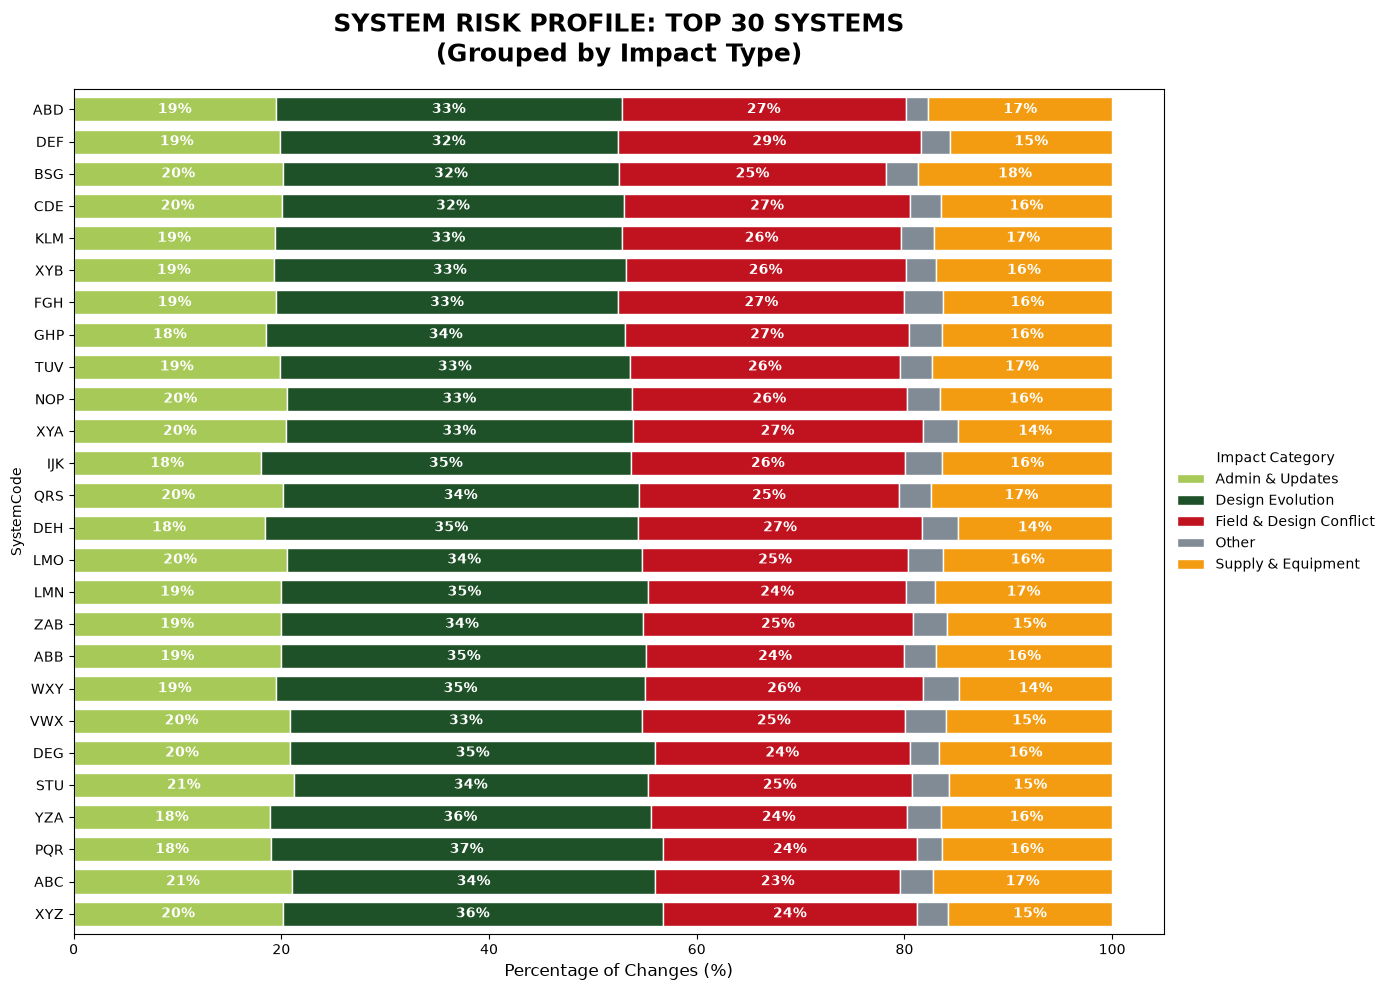

In [14]:
# ==============================================================================
# CELL 13 — SYSTEM RISK PROFILE (Change Reason Distribution)
# ==============================================================================

import matplotlib.pyplot as plt

def plot_reason_distribution(fact_df, bridge_df, top_n=30):
    """
    Horizontal stacked bar chart showing the breakdown of change reasons
    per system, grouped into four high-level impact categories.
    Systems sorted by proportion of physical/field-related changes.
    """
    reason_groups = {
        'Field & Design Conflict': [
            'Site Condition Variation', 'Constructability Improvement',
            'Clash Detection Resolution', 'Interface Misalignment',
            'Construction Rework Required', 'Installation Modification Required',
            'Quality Non-Conformance'
        ],
        'Supply & Equipment': [
            'Material Availability Issue', 'Equipment Replacement Required',
            'Vendor Deviation', 'Procurement Specification Change'
        ],
        'Design Evolution': [
            'Design Optimization', 'Client Requirement Change',
            'Value Engineering Proposal', 'Regulatory Compliance Update',
            'Safety Enhancement'
        ],
        'Admin & Updates': [
            'Drawing Update', 'Calculation Revision',
            'Scope Clarification', 'Late Engineering Input'
        ]
    }

    inv_map = {reason: group for group, reasons in reason_groups.items() for reason in reasons}

    merged = bridge_df.merge(fact_df[['ChangeID', 'Reason']], on='ChangeID')
    merged['ReasonGroup'] = merged['Reason'].map(inv_map).fillna('Other')

    group_counts = pd.crosstab(merged['SystemCode'], merged['ReasonGroup'])
    group_pct    = group_counts.div(group_counts.sum(axis=1), axis=0) * 100

    group_pct['Total_Physical'] = (
        group_pct.get('Field & Design Conflict', 0) +
        group_pct.get('Supply & Equipment', 0)
    )

    top_systems  = merged['SystemCode'].value_counts().head(top_n).index
    group_pct    = group_pct.loc[top_systems].sort_values(by='Total_Physical', ascending=True)
    group_pct    = group_pct.drop(columns=['Total_Physical'])

    clean_colors = {
        'Field & Design Conflict': '#c1121f',
        'Supply & Equipment':      '#f39c12',
        'Design Evolution':        '#1e5128',
        'Admin & Updates':         '#a7c957',
        'Other':                   '#808b96'
    }

    fig, ax = plt.subplots(figsize=(14, 10))
    group_pct.plot(
        kind='barh', stacked=True, ax=ax,
        color=[clean_colors.get(x, '#333333') for x in group_pct.columns],
        edgecolor='white', width=0.75
    )

    for p in ax.patches:
        width = p.get_width()
        if width > 8:
            ax.annotate(
                f'{int(width)}%',
                (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=10
            )

    plt.title(
        f'SYSTEM RISK PROFILE: TOP {top_n} SYSTEMS\n(Grouped by Impact Type)',
        fontsize=18, fontweight='bold', pad=20
    )
    plt.xlabel('Percentage of Changes (%)', fontsize=12)
    plt.legend(title='Impact Category', bbox_to_anchor=(1.0, 0.5), loc='center left', frameon=False)
    plt.tight_layout()
    plt.show()

plot_reason_distribution(fact_enriched, systems_bridge, top_n=30)

✅ df_contract_base:    24,713 rows | 15,000 unique ChangeIDs | 6 contracts
   df_closed_contracts: 23,542 rows | 14,292 unique closed
   df_active_contracts: 1,171 rows | 708 unique open

── CONTRACT BACKLOG ─────────────────────────────────────────────────


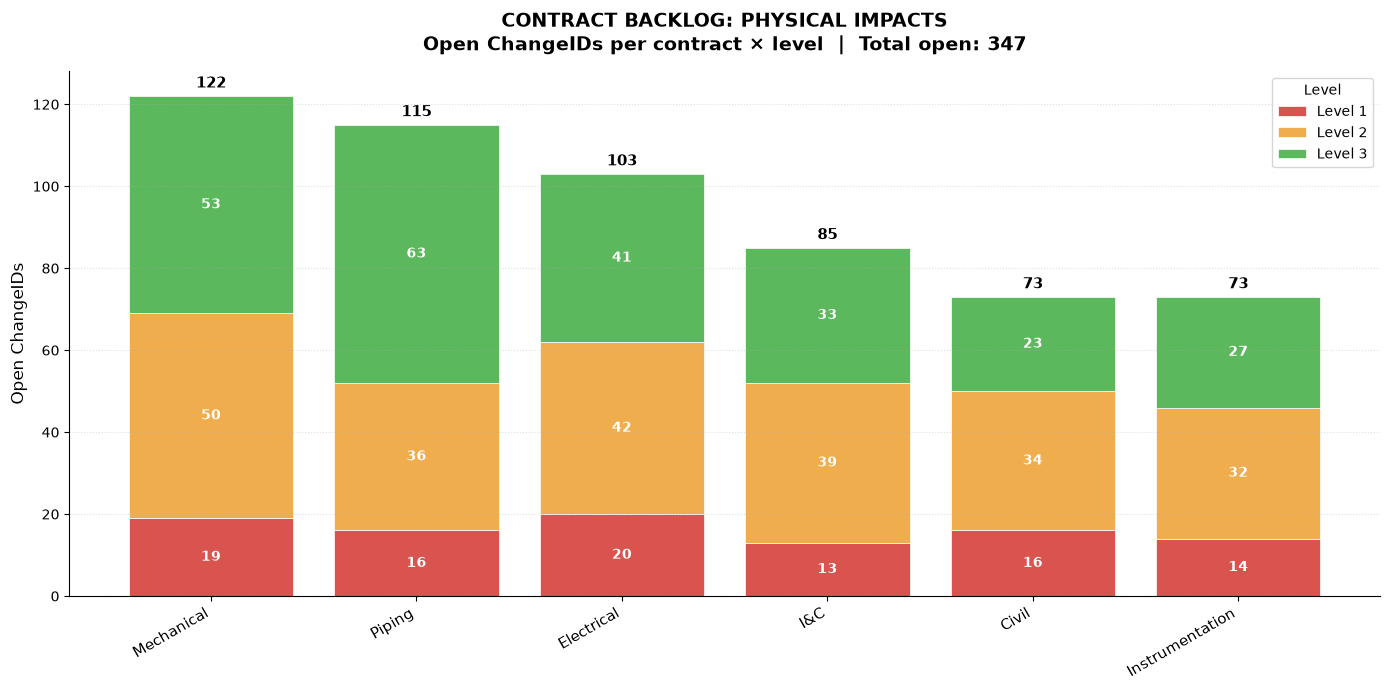

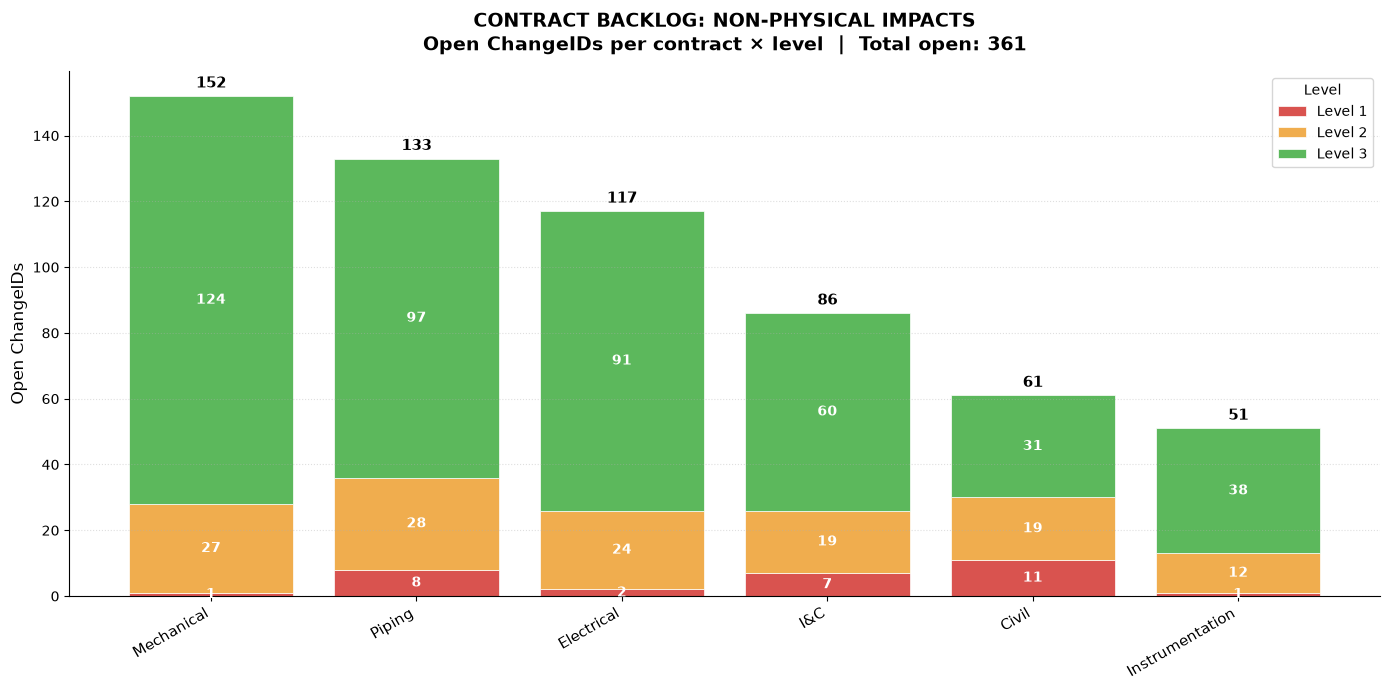


── CONTRACT LEAD TIME ───────────────────────────────────────────────
wrote gold_contract_leadtime_physical      6 rows -> data/gold/gold_contract_leadtime_physical.parquet  (from: fact_enriched, contract_dim)


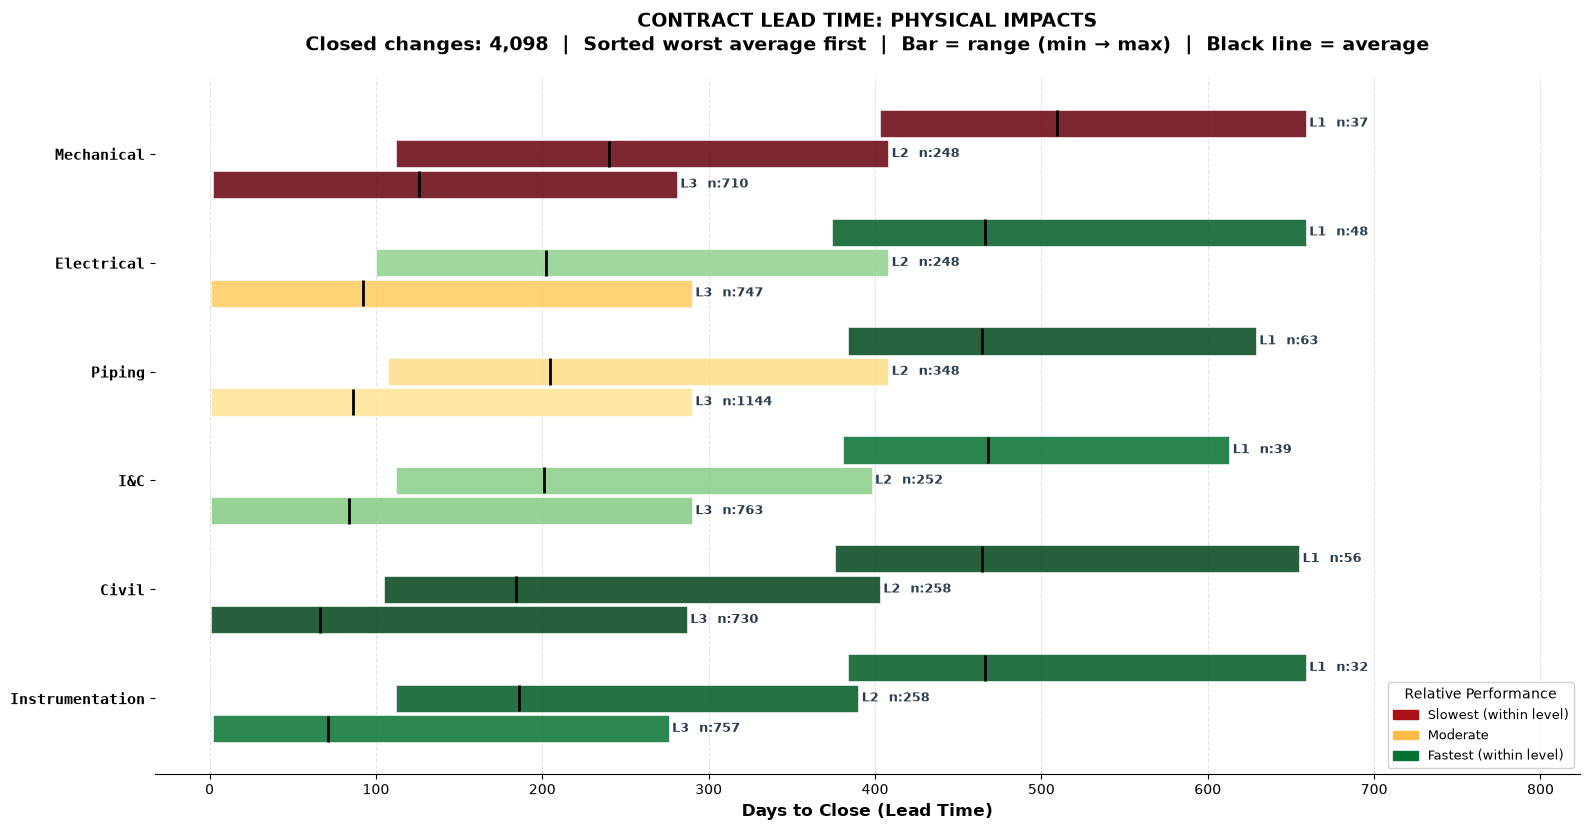

,Contract,Avg Lead Time (d),Closed Changes
4,Mechanical,168,995
1,Electrical,135,1043
5,Piping,128,1555
2,I&C,126,1054
0,Civil,117,1044
3,Instrumentation,112,1047


wrote gold_contract_leadtime_non_physical      6 rows -> data/gold/gold_contract_leadtime_non_physical.parquet  (from: fact_enriched, contract_dim)


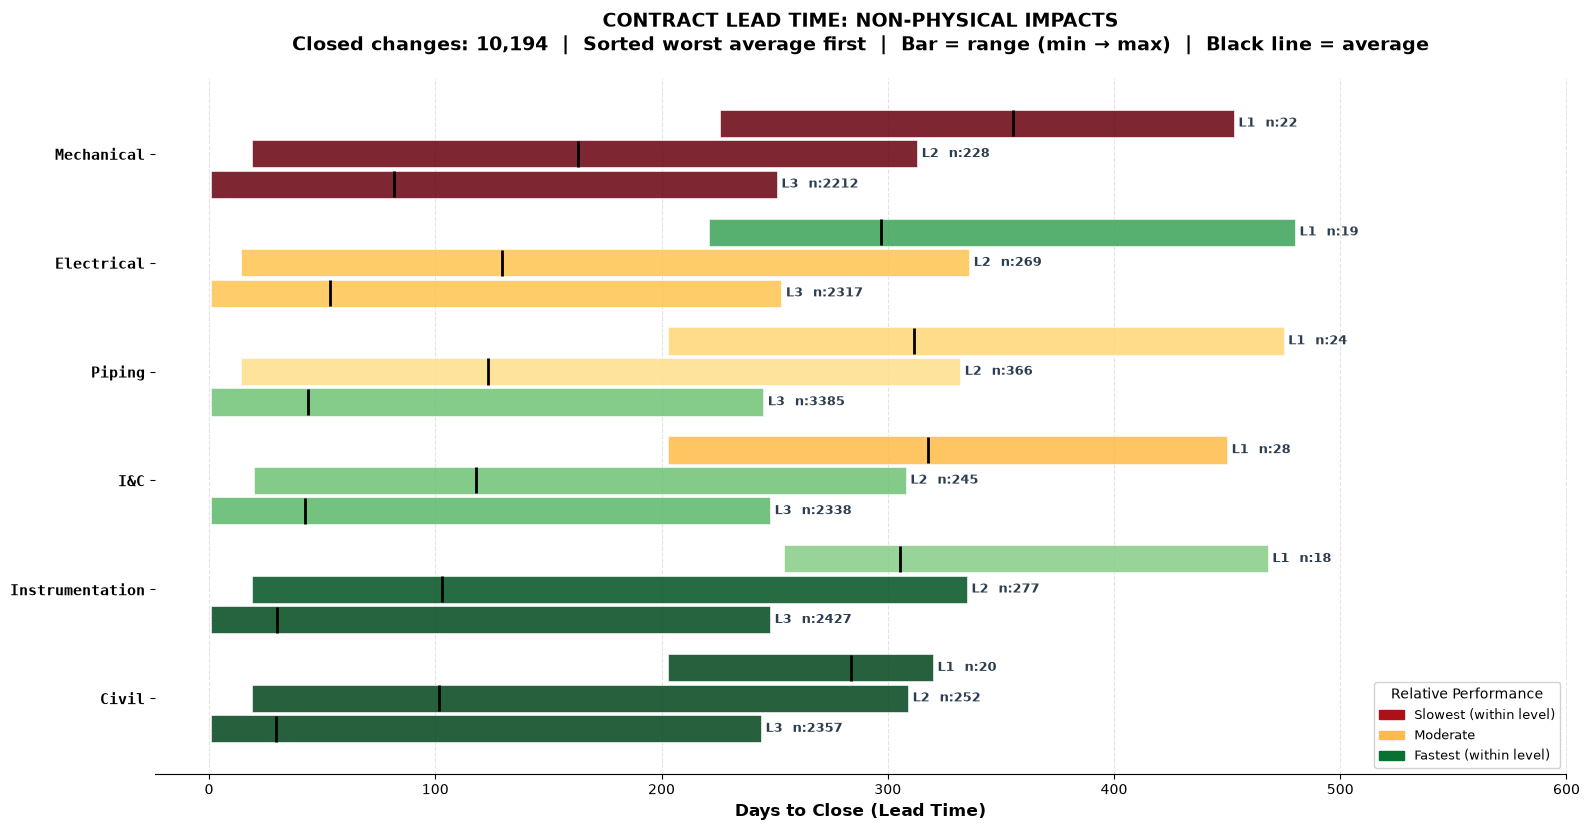

,Contract,Avg Lead Time (d),Closed Changes
4,Mechanical,92,2462
1,Electrical,63,2605
5,Piping,53,3775
2,I&C,52,2611
3,Instrumentation,39,2722
0,Civil,39,2629



── CONTRACT STAGNATION ──────────────────────────────────────────────
wrote gold_contract_stagnation_physical      6 rows -> data/gold/gold_contract_stagnation_physical.parquet  (from: fact_enriched, contract_dim)


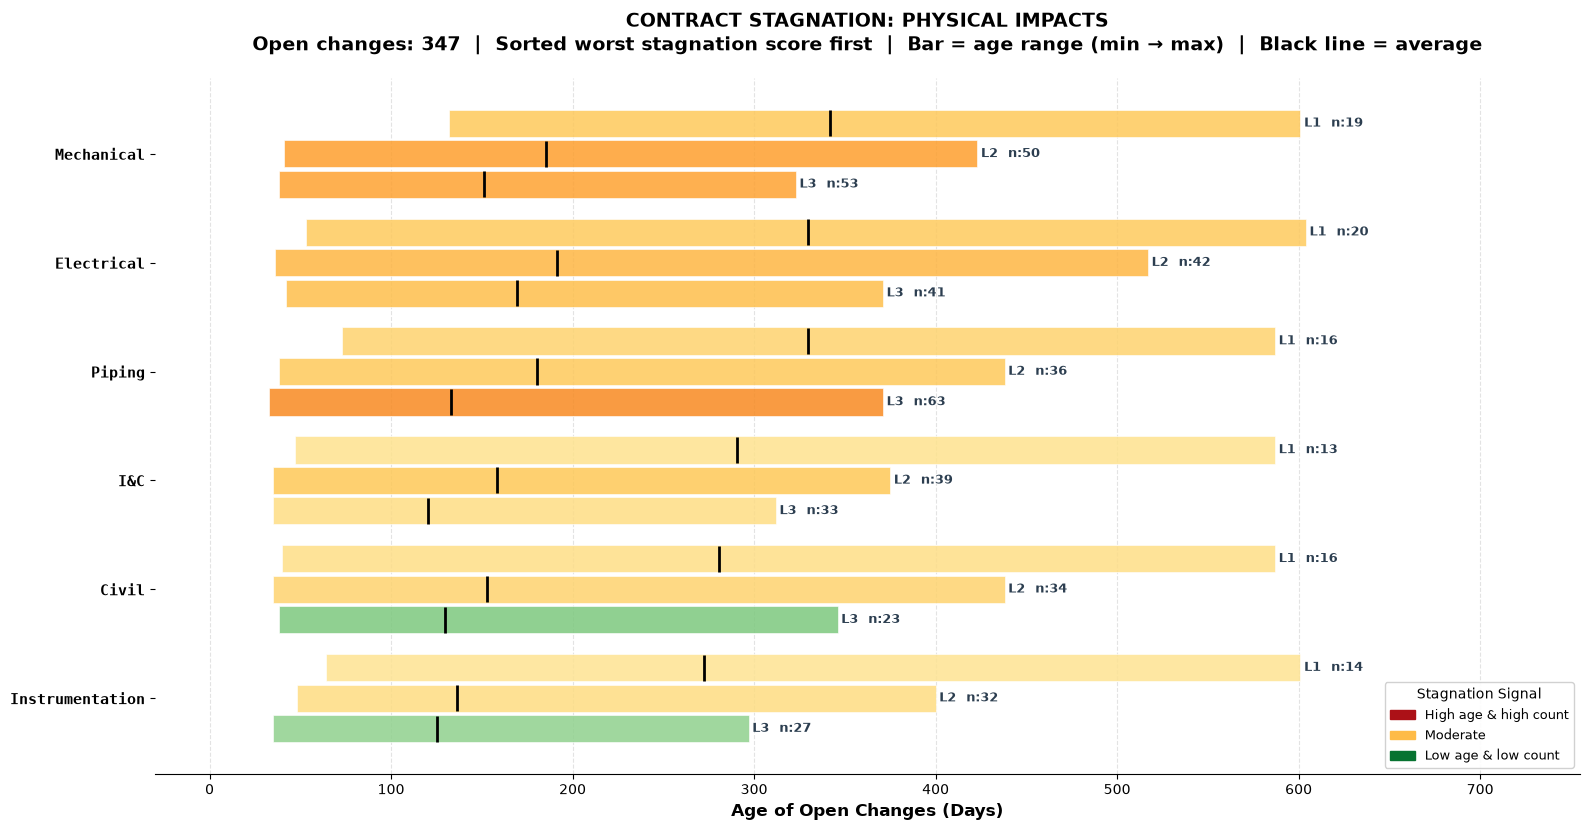

,Contract,Stagnation Score,Open Changes,Avg Age (d)
4,Mechanical,23789,122,226
1,Electrical,21587,103,230
5,Piping,20145,115,214
2,I&C,13929,85,190
0,Civil,12678,73,188
3,Instrumentation,11555,73,178


wrote gold_contract_stagnation_non_physical      6 rows -> data/gold/gold_contract_stagnation_non_physical.parquet  (from: fact_enriched, contract_dim)


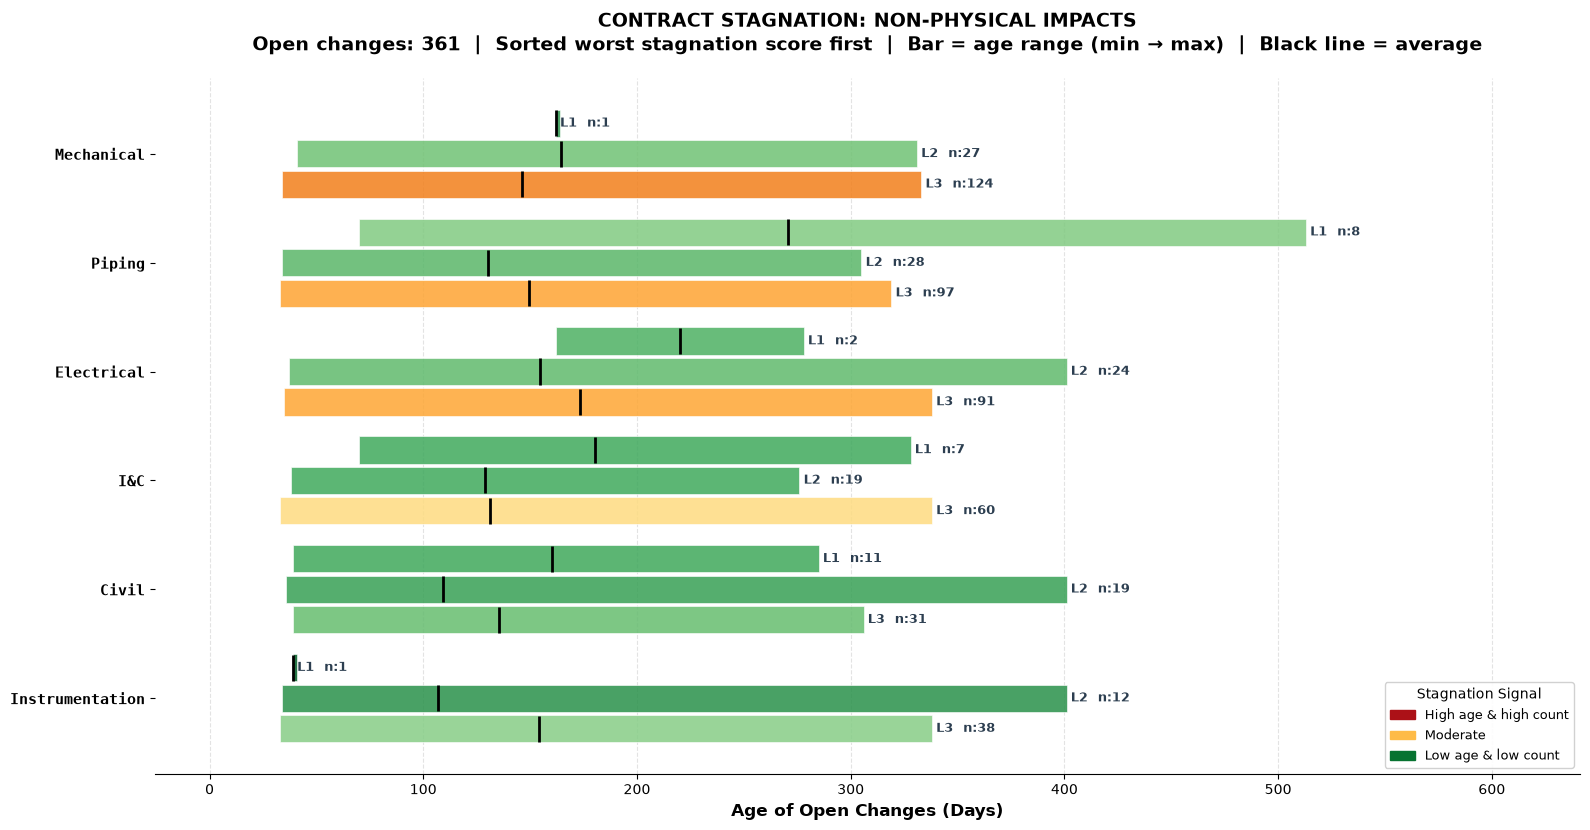

,Contract,Stagnation Score,Open Changes,Avg Age (d)
4,Mechanical,22709,152,158
5,Piping,20286,133,183
1,Electrical,19937,117,183
2,I&C,11586,86,147
0,Civil,8033,61,135
3,Instrumentation,7175,51,100


✅ Contract grain analysis complete.


In [15]:
# ==============================================================================
# CELL 14 — CONTRACT GRAIN ANALYSIS
#
# Join chain:
#   fact_enriched
#     LEFT JOIN systems_bridge   ON ChangeID    (explodes to ChangeID × SystemCode)
#     LEFT JOIN contract_dim     ON SystemCode   (maps SystemCode → Contract)
#   drop_duplicates(['ChangeID', 'Contract'])    (collapses multi-system fan-out)
#
# A change impacting systems in two different contracts counts once per
# contract. A change impacting two systems in the same contract counts once.
#
# Outputs:
#   CHART 1: Contract Backlog         — open changes per contract × level (stacked bar)
#   CHART 2: Contract Lead Time       — closed changes, range bars min→max, avg line
#   CHART 3: Contract Stagnation      — open changes, age range bars, stagnation score
#   CHART 4: Contract Readiness Widget — % closed RAG bars with drilldown
#   GOLD TABLE: contract grain summary with risk flags
#
# Grain reference:
#   df_contract_base      ChangeID × Contract    full population
#   df_closed_contracts   ChangeID × Contract    closed changes only
#   df_active_contracts   ChangeID × Contract    open changes only
#   All deduplicated on ['ChangeID', 'Contract'] before aggregation.
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

import sys
sys.path.insert(0, str(ROOT / "src"))
from lineage import write_layer
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── CONFIG ────────────────────────────────────────────────────────────────────
LEVEL_COLORS  = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}
LEVEL_LABELS  = {1: 'Level 1 — Critical', 2: 'Level 2 — Medium', 3: 'Level 3 — Low'}
level_offsets = {1: -0.28, 2: 0, 3: 0.28}
RAG_RED, RAG_AMBER = 80, 95

def get_rag_color(pct):
    if pct < RAG_RED:   return '#c0392b'
    if pct < RAG_AMBER: return '#f39c12'
    return                     '#1e8449'

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '16px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

# ── COLOUR FUNCTIONS ──────────────────────────────────────────────────────────
def get_leadtime_color(avg_lt, min_lt, max_lt):
    """Min-max normalised within level. Worst = darkest red, best = darkest green."""
    rng   = max_lt - min_lt
    score = (avg_lt - min_lt) / rng if rng > 0 else 0.5
    if score >= 0.66:
        return plt.get_cmap('Reds')(0.4 + 0.6 * ((score - 0.66) / 0.34))
    elif score >= 0.33:
        return plt.get_cmap('YlOrBr')(0.4 * 0.6 + 0.6 * ((score - 0.33) / 0.33) * 0.6)
    else:
        return plt.get_cmap('Greens')(0.4 + 0.6 * (1 - (score / 0.33)))

def get_stagnation_color(avg_age, id_count, max_age, max_count):
    """Age × count score. High age + high count = darkest red."""
    age_ratio   = avg_age  / max_age   if max_age   > 0 else 0
    count_ratio = id_count / max_count if max_count > 0 else 0
    score       = (age_ratio + count_ratio) / 2
    if score >= 0.66:
        return plt.get_cmap('Reds')(0.4 + 0.6 * ((score - 0.66) / 0.34))
    elif score >= 0.33:
        return plt.get_cmap('YlOrBr')((0.4 + 0.6 * ((score - 0.33) / 0.33)) * 0.6)
    else:
        return plt.get_cmap('Greens')(0.4 + 0.6 * (1 - (score / 0.33)))


# ── SILVER TABLES ─────────────────────────────────────────────────────────────
# Join chain: fact_enriched → systems_bridge → contract_dim
# LEFT JOIN throughout — unassigned changes appear as 'Unassigned'
# Deduplicate on ['ChangeID', 'Contract'] to collapse multi-system fan-out

contract_lookup = pd.read_sql(
    "SELECT SystemCode, Contract FROM contract_dim", conn
)

df_contract_base = (
    fact_enriched[['ChangeID', 'Level', 'Physical_Impacts', 'Status',
                   'Days_to_Close', 'Current_Age_Days', 'Days_Overdue',
                   'Driving_Milestone']]
    .merge(systems_bridge[['ChangeID', 'SystemCode']], on='ChangeID', how='left')
    .merge(contract_lookup, on='SystemCode', how='left')
    .drop_duplicates(['ChangeID', 'Contract'])
    .copy()
)

# Fill NULLs — unresolvable changes shown explicitly
df_contract_base['Contract'] = df_contract_base['Contract'].fillna('Unassigned')

# Cast Physical_Impacts to int — SQLite may return floats
df_contract_base['Physical_Impacts'] = df_contract_base['Physical_Impacts'].astype(int)

# Split into closed and open populations
df_closed_contracts = df_contract_base[df_contract_base['Status'] == 'Closed'].copy()
df_active_contracts = df_contract_base[df_contract_base['Status'] != 'Closed'].copy()

print(f"✅ df_contract_base:    {len(df_contract_base):,} rows | "
      f"{df_contract_base['ChangeID'].nunique():,} unique ChangeIDs | "
      f"{df_contract_base['Contract'].nunique()} contracts")
print(f"   df_closed_contracts: {len(df_closed_contracts):,} rows | "
      f"{df_closed_contracts['ChangeID'].nunique():,} unique closed")
print(f"   df_active_contracts: {len(df_active_contracts):,} rows | "
      f"{df_active_contracts['ChangeID'].nunique():,} unique open")


# ==============================================================================
# CHART 1 — CONTRACT BACKLOG (open changes)
# ==============================================================================

def plot_contract_backlog(df, impact_val, title_suffix):
    subset = df[df['Physical_Impacts'] == impact_val]
    if subset.empty:
        print(f'No data for {title_suffix}')
        return

    counts = (
        subset.groupby(['Contract', 'Level'])['ChangeID']
        .nunique()
        .unstack(fill_value=0)
    )
    for lvl in [1, 2, 3]:
        if lvl not in counts.columns:
            counts[lvl] = 0
    counts['Total'] = counts[[1, 2, 3]].sum(axis=1)
    counts = counts.sort_values('Total', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 7))
    colors  = ['#d9534f', '#f0ad4e', '#5cb85c']
    bottom  = np.zeros(len(counts))
    x_pos   = np.arange(len(counts))

    for lvl, color in zip([1, 2, 3], colors):
        vals = counts[lvl].values
        ax.bar(x_pos, vals, bottom=bottom, color=color,
               label=f'Level {lvl}', edgecolor='white', linewidth=0.5)
        for i, (val, bot) in enumerate(zip(vals, bottom)):
            if val > 0:
                ax.text(i, bot + val / 2, str(int(val)),
                        ha='center', va='center', fontsize=10,
                        fontweight='bold', color='white')
        bottom += vals

    for i, total in enumerate(counts['Total']):
        ax.text(i, total + counts['Total'].max() * 0.01, f'{int(total):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=11)
    ax.set_title(
        f'CONTRACT BACKLOG: {title_suffix}\n'
        f'Open ChangeIDs per contract × level  |  '
        f'Total open: {subset["ChangeID"].nunique():,}',
        fontsize=14, fontweight='bold', pad=15
    )
    ax.set_ylabel('Open ChangeIDs', fontsize=12)
    ax.legend(title='Level', loc='upper right', fontsize=10)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

print('\n── CONTRACT BACKLOG ─────────────────────────────────────────────────')
plot_contract_backlog(df_active_contracts, 1, 'PHYSICAL IMPACTS')
plot_contract_backlog(df_active_contracts, 0, 'NON-PHYSICAL IMPACTS')


# ==============================================================================
# CHART 2 — CONTRACT LEAD TIME (historical — closed changes)
# ==============================================================================

def plot_contract_leadtime(df, impact_val, title_suffix):
    df = df[df['Physical_Impacts'] == impact_val]
    df = df[df['Days_to_Close'].notna()].copy()
    df['Days_to_Close'] = df['Days_to_Close'].astype(float)

    if df.empty:
        print(f'No closed data for {title_suffix}')
        return

    agg = (
        df.groupby(['Contract', 'Level'])
        .agg(
            Closed_Count  = ('ChangeID',      'nunique'),
            Avg_Lead_Time = ('Days_to_Close', 'mean'),
            Min_Lead_Time = ('Days_to_Close', 'min'),
            Max_Lead_Time = ('Days_to_Close', 'max'),
        )
        .reset_index()
    )

    contract_agg = (
        df.groupby('Contract')
        .agg(
            Avg_Lead_Time = ('Days_to_Close', 'mean'),
            Closed_Count  = ('ChangeID',      'nunique'),
        )
        .reset_index()
        .sort_values('Avg_Lead_Time', ascending=False)
    )
    _suffix = "physical" if impact_val == 1 else "non_physical"
    write_layer(contract_agg, f"gold_contract_leadtime_{_suffix}", ROOT / "data" / "gold",
                sources=["fact_enriched", "contract_dim"])

    contract_order = contract_agg['Contract'].tolist()
    n_con          = len(contract_order)

    level_ranges = {}
    for lvl, grp in agg.groupby('Level'):
        level_ranges[int(lvl)] = {
            'min_lt': float(grp['Avg_Lead_Time'].min()),
            'max_lt': float(grp['Avg_Lead_Time'].max()),
        }

    fig, ax = plt.subplots(figsize=(16, max(6, n_con * 1.4)))

    for i, con in enumerate(contract_order):
        con_rows = agg[agg['Contract'] == con]
        for _, row in con_rows.iterrows():
            lvl   = int(row['Level'])
            y_pos = i + level_offsets.get(lvl, 0)
            rng   = level_ranges.get(lvl, {})
            color = get_leadtime_color(
                float(row['Avg_Lead_Time']),
                float(rng.get('min_lt', 0)),
                float(rng.get('max_lt', 1)),
            )
            bar_width = max(2, row['Max_Lead_Time'] - row['Min_Lead_Time'])
            ax.barh(y_pos, bar_width, left=row['Min_Lead_Time'],
                    height=0.25, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, zorder=3)
            ax.vlines(row['Avg_Lead_Time'], y_pos - 0.12, y_pos + 0.12,
                      color='black', linewidth=2, zorder=5)
            ax.text(row['Max_Lead_Time'] + 2, y_pos,
                    f"L{lvl}  n:{int(row['Closed_Count'])}",
                    va='center', ha='left', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(n_con))
    ax.set_yticklabels(contract_order, fontsize=11, fontweight='bold',
                       fontfamily='monospace')
    ax.invert_yaxis()
    ax.set_xlim(-agg['Max_Lead_Time'].max() * 0.05,
                 agg['Max_Lead_Time'].max() * 1.25)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Days to Close (Lead Time)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'CONTRACT LEAD TIME: {title_suffix}\n'
        f'Closed changes: {df["ChangeID"].nunique():,}  |  '
        f'Sorted worst average first  |  '
        f'Bar = range (min → max)  |  Black line = average',
        fontsize=14, fontweight='bold', pad=20
    )
    patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),   label='Slowest (within level)'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.4),  label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85), label='Fastest (within level)'),
    ]
    ax.legend(handles=patches, loc='lower right', framealpha=0.9,
              fontsize=9, title='Relative Performance')
    plt.tight_layout()
    plt.show()

    display(
        contract_agg.rename(columns={
            'Contract':     'Contract',
            'Avg_Lead_Time':'Avg Lead Time (d)',
            'Closed_Count': 'Closed Changes',
        }).style
        .background_gradient(subset=['Avg Lead Time (d)'], cmap='RdYlGn_r', vmin=0)
        .set_caption(f'Contract Lead Time: {title_suffix}')
        .format({'Avg Lead Time (d)': '{:.0f}'})
        .set_table_styles(TABLE_STYLES)
    )

print('\n── CONTRACT LEAD TIME ───────────────────────────────────────────────')
plot_contract_leadtime(df_closed_contracts, 1, 'PHYSICAL IMPACTS')
plot_contract_leadtime(df_closed_contracts, 0, 'NON-PHYSICAL IMPACTS')


# ==============================================================================
# CHART 3 — CONTRACT STAGNATION (current — open changes)
# ==============================================================================

def plot_contract_stagnation(df, impact_val, title_suffix):
    df = df[df['Physical_Impacts'] == impact_val]
    df = df[df['Current_Age_Days'].notna()].copy()
    df['Current_Age_Days'] = df['Current_Age_Days'].astype(float)

    if df.empty:
        print(f'No open data for {title_suffix}')
        return

    agg = (
        df.groupby(['Contract', 'Level'])
        .agg(
            ID_Count = ('ChangeID',         'nunique'),
            Avg_Age  = ('Current_Age_Days', 'mean'),
            Min_Age  = ('Current_Age_Days', 'min'),
            Max_Age  = ('Current_Age_Days', 'max'),
        )
        .reset_index()
    )
    agg['Score'] = agg['Avg_Age'] * agg['ID_Count']

    contract_scores = (
        agg.groupby('Contract')
        .agg(
            Total_Score = ('Score',    'sum'),
            Total_Open  = ('ID_Count', 'sum'),
            Avg_Age     = ('Avg_Age',  'mean'),
        )
        .reset_index()
        .sort_values('Total_Score', ascending=False)
    )
    _suffix = "physical" if impact_val == 1 else "non_physical"
    write_layer(contract_scores, f"gold_contract_stagnation_{_suffix}", ROOT / "data" / "gold",
                sources=["fact_enriched", "contract_dim"])

    contract_order = contract_scores['Contract'].tolist()
    n_con          = len(contract_order)
    max_age_glob   = float(agg['Max_Age'].max()) or 1
    max_count_glob = float(agg['ID_Count'].max()) or 1

    fig, ax = plt.subplots(figsize=(16, max(6, n_con * 1.4)))

    for i, con in enumerate(contract_order):
        con_rows = agg[agg['Contract'] == con]
        for _, row in con_rows.iterrows():
            lvl   = int(row['Level'])
            y_pos = i + level_offsets.get(lvl, 0)
            color = get_stagnation_color(
                float(row['Avg_Age']), float(row['ID_Count']),
                max_age_glob, max_count_glob
            )
            bar_width = max(2, row['Max_Age'] - row['Min_Age'])
            ax.barh(y_pos, bar_width, left=row['Min_Age'],
                    height=0.25, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, zorder=3)
            ax.vlines(row['Avg_Age'], y_pos - 0.12, y_pos + 0.12,
                      color='black', linewidth=2, zorder=5)
            ax.text(row['Max_Age'] + 2, y_pos,
                    f"L{lvl}  n:{int(row['ID_Count'])}",
                    va='center', ha='left', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(n_con))
    ax.set_yticklabels(contract_order, fontsize=11, fontweight='bold',
                       fontfamily='monospace')
    ax.invert_yaxis()
    ax.set_xlim(-max_age_glob * 0.05, max_age_glob * 1.25)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Age of Open Changes (Days)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'CONTRACT STAGNATION: {title_suffix}\n'
        f'Open changes: {df["ChangeID"].nunique():,}  |  '
        f'Sorted worst stagnation score first  |  '
        f'Bar = age range (min → max)  |  Black line = average',
        fontsize=14, fontweight='bold', pad=20
    )
    patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),   label='High age & high count'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.4),  label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85), label='Low age & low count'),
    ]
    ax.legend(handles=patches, loc='lower right', framealpha=0.9,
              fontsize=9, title='Stagnation Signal')
    plt.tight_layout()
    plt.show()

    display(
        contract_scores.rename(columns={
            'Contract':     'Contract',
            'Total_Score':  'Stagnation Score',
            'Total_Open':   'Open Changes',
            'Avg_Age':      'Avg Age (d)',
        }).style
        .background_gradient(subset=['Stagnation Score'], cmap='RdYlGn_r')
        .set_caption(f'Contract Stagnation: {title_suffix}')
        .format({'Stagnation Score': '{:.0f}', 'Avg Age (d)': '{:.0f}'})
        .set_table_styles(TABLE_STYLES)
    )

print('\n── CONTRACT STAGNATION ──────────────────────────────────────────────')
plot_contract_stagnation(df_active_contracts, 1, 'PHYSICAL IMPACTS')
plot_contract_stagnation(df_active_contracts, 0, 'NON-PHYSICAL IMPACTS')


# ==============================================================================
# CHART 4 — CONTRACT READINESS WIDGET
# ==============================================================================

# Full population — open and closed — for readiness %
df_readiness_con = df_contract_base.copy()
df_readiness_con['Is_Closed'] = (df_readiness_con['Status'] == 'Closed').astype(int)

contract_list    = sorted([c for c in df_readiness_con['Contract'].unique() if c != 'Unassigned'])
dropdown_options = ['ALL CONTRACTS'] + contract_list + (
    ['Unassigned'] if 'Unassigned' in df_readiness_con['Contract'].values else []
)

dropdown = widgets.Dropdown(
    options=dropdown_options,
    value='ALL CONTRACTS',
    description='Contract:',
    style={'description_width': 'initial'},
    layout={'width': '350px'}
)
output = widgets.Output()

def update_contract_dashboard(change):
    selected = change['new']
    with output:
        clear_output(wait=True)

        if selected == 'ALL CONTRACTS':
            summary = (
                df_readiness_con
                .groupby('Contract')
                .agg(
                    Total_Changes  = ('ChangeID',  'nunique'),
                    Closed_Changes = ('Is_Closed', 'sum')
                )
                .reset_index()
            )
            summary['Readiness_Pct'] = (
                summary['Closed_Changes'] / summary['Total_Changes'] * 100
            ).round(1)
            summary = summary.sort_values('Readiness_Pct', ascending=True)

            fig, ax = plt.subplots(figsize=(12, max(4, len(summary) * 0.8 + 2)))
            y_pos = np.arange(len(summary))

            ax.barh(y_pos, 100, color='#eeeeee', height=0.6, zorder=1)
            ax.barh(y_pos, summary['Readiness_Pct'],
                    color=[get_rag_color(p) for p in summary['Readiness_Pct']],
                    height=0.6, zorder=2)

            for i, (pct, total, closed) in enumerate(zip(
                summary['Readiness_Pct'],
                summary['Total_Changes'],
                summary['Closed_Changes']
            )):
                ax.text(pct + 1, i,
                        f"{pct}%  ({int(closed)}/{int(total)})",
                        va='center', fontweight='bold', fontsize=10)

            ax.set_yticks(y_pos)
            ax.set_yticklabels(summary['Contract'],
                               fontfamily='monospace', fontsize=11)
            ax.set_xlim(0, 125)
            ax.set_xlabel('Readiness %', fontsize=11)
            ax.set_title(
                f'CONTRACT READINESS SUMMARY  |  {ts_sim_today.date()}',
                fontsize=15, fontweight='bold', loc='left'
            )
            ax.text(0.99, 1.01,
                    f'Red < {RAG_RED}%  |  Amber {RAG_RED}–{RAG_AMBER}%  |  Green ≥ {RAG_AMBER}%',
                    transform=ax.transAxes, ha='right',
                    fontsize=9, color='gray', style='italic')
            ax.grid(axis='x', linestyle=':', alpha=0.4)
            ax.spines[['top', 'right']].set_visible(False)
            plt.tight_layout()
            plt.show()

            group_cols = ['Contract', 'Level', 'Physical_Impacts']

        else:
            con_data = df_readiness_con[df_readiness_con['Contract'] == selected]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

            # Readiness by level
            l_stats = (
                con_data.groupby('Level')
                .agg(T=('ChangeID', 'nunique'), C=('Is_Closed', 'sum'))
                .reset_index()
            )
            l_stats['P'] = (l_stats['C'] / l_stats['T'] * 100).round(1)
            bars1 = ax1.bar(
                l_stats['Level'].astype(str), l_stats['P'],
                color=[LEVEL_COLORS.get(l, '#7f8c8d') for l in l_stats['Level']]
            )
            ax1.set_ylim(0, 115)
            ax1.set_title('Readiness by Priority Level', fontweight='bold')
            ax1.set_xlabel('Level')
            ax1.set_ylabel('Readiness %')
            for bar in bars1:
                ax1.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 2,
                         f'{bar.get_height():.0f}%',
                         ha='center', fontweight='bold', fontsize=10)

            # Readiness by impact type
            i_stats = (
                con_data.groupby('Physical_Impacts')
                .agg(T=('ChangeID', 'nunique'), C=('Is_Closed', 'sum'))
                .reset_index()
            )
            i_stats['P']     = (i_stats['C'] / i_stats['T'] * 100).round(1)
            i_stats['Label'] = i_stats['Physical_Impacts'].map(
                {1: 'Physical', 0: 'Documentary'}
            )
            bars2 = ax2.bar(
                i_stats['Label'], i_stats['P'],
                color=['#34495e', '#95a5a6']
            )
            ax2.set_ylim(0, 115)
            ax2.set_title('Physical vs Documentary', fontweight='bold')
            ax2.set_ylabel('Readiness %')
            for bar in bars2:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 2,
                         f'{bar.get_height():.0f}%',
                         ha='center', fontweight='bold', fontsize=10)

            plt.suptitle(
                f'DRILL-DOWN: {selected}  |  {ts_sim_today.date()}',
                fontsize=14, fontweight='bold', y=1.02
            )
            plt.tight_layout()
            plt.show()

            group_cols = ['Level', 'Physical_Impacts']

        # ── SHARED TABLE ──────────────────────────────────────────────────────
        data = (
            df_readiness_con if selected == 'ALL CONTRACTS'
            else df_readiness_con[df_readiness_con['Contract'] == selected]
        )
        table = (
            data.groupby(group_cols)
            .agg(Total=('ChangeID', 'nunique'), Closed=('Is_Closed', 'sum'))
            .reset_index()
        )
        table['Open']    = table['Total'] - table['Closed']
        table['Ready %'] = (table['Closed'] / table['Total'] * 100).round(1)

        if 'Physical_Impacts' in table.columns:
            table['Physical_Impacts'] = table['Physical_Impacts'].map(
                {1: 'Physical', 0: 'Documentary'}
            )

        display(
            table.style
            .background_gradient(subset=['Ready %'], cmap='RdYlGn', vmin=70, vmax=100)
            .set_caption(
                f'Contract Readiness Detail: {selected}  |  '
                f'Total changes: {data["ChangeID"].nunique():,}'
            )
            .format({'Ready %': '{:.1f}%'})
            .set_table_styles(TABLE_STYLES)
        )

dropdown.observe(update_contract_dashboard, names='value')
display(widgets.VBox([dropdown, output]))
update_contract_dashboard({'new': dropdown.value})

print("✅ Contract grain analysis complete.")

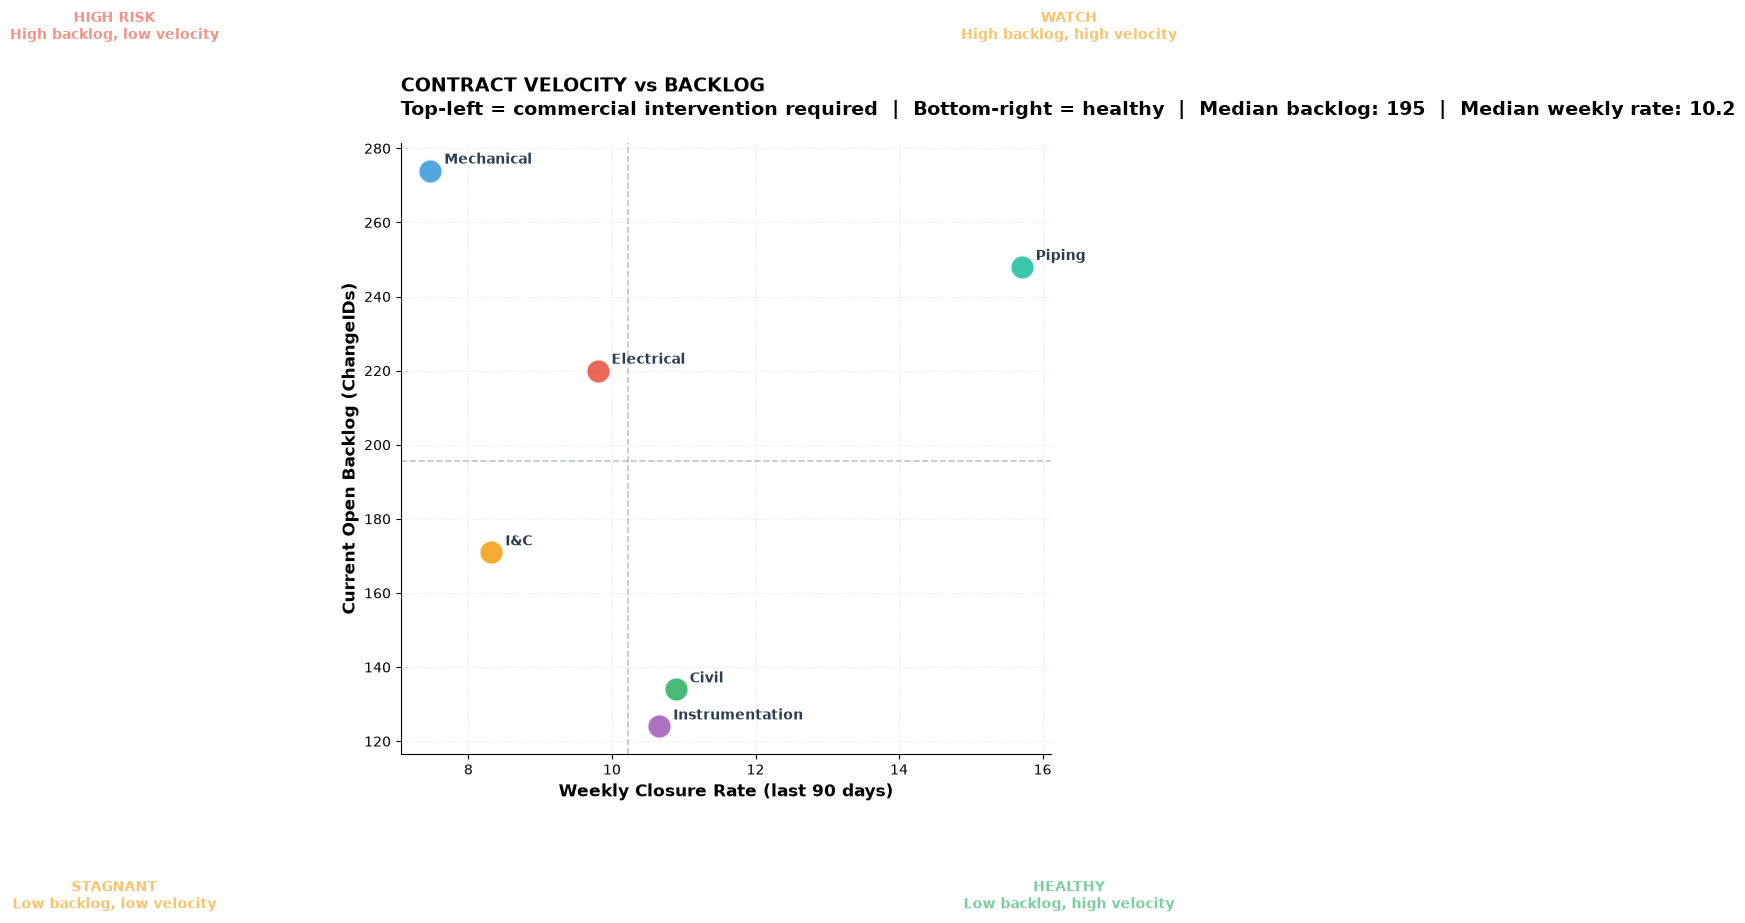

In [16]:
# ==============================================================================
# CELL 14b — CONTRACT GRAIN ANALYSIS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── CONFIG ────────────────────────────────────────────────────────────────────
CONTRACT_COLORS = {
    'Electrical':      '#e74c3c',
    'Mechanical':      '#3498db',
    'Civil':           '#27ae60',
    'I&C':             '#f39c12',
    'Instrumentation': '#9b59b6',
    'Piping':          '#1abc9c',
    'Unassigned':      '#7f8c8d',
}

# ── DATA PREP ─────────────────────────────────────────────────────────────────
lookback = ts_sim_today - pd.Timedelta(days=90)

contract_backlog = (
    df_active_contracts
    .groupby('Contract')['ChangeID']
    .nunique()
    .reset_index(name='Open_Backlog')
)

df_closed_con = (
    fact_enriched[
        (fact_enriched['Status'] == 'Closed') &
        (fact_enriched['DateClosed'] >= lookback) &
        (fact_enriched['DateClosed'] <= ts_sim_today)
    ][['ChangeID', 'DateClosed']]
    .merge(systems_bridge[['ChangeID', 'SystemCode']], on='ChangeID', how='left')
    .merge(contract_lookup, on='SystemCode', how='left')
    .drop_duplicates(['ChangeID', 'Contract'])
)
df_closed_con['Contract'] = df_closed_con['Contract'].fillna('Unassigned')

contract_velocity = (
    df_closed_con
    .groupby('Contract')['ChangeID']
    .nunique()
    .reset_index(name='Recent_Closures')
)
contract_velocity['Weekly_Rate'] = (
    contract_velocity['Recent_Closures'] / 90 * 7
).round(2)

scatter_df = (
    contract_backlog
    .merge(contract_velocity[['Contract', 'Weekly_Rate']], on='Contract', how='left')
)
scatter_df['Weekly_Rate'] = scatter_df['Weekly_Rate'].fillna(0)

# ── QUADRANT MEDIANS ──────────────────────────────────────────────────────────
median_backlog  = scatter_df['Open_Backlog'].median()
median_velocity = scatter_df['Weekly_Rate'].median()

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

for _, row in scatter_df.iterrows():
    color = CONTRACT_COLORS.get(row['Contract'], '#7f8c8d')
    ax.scatter(row['Weekly_Rate'], row['Open_Backlog'],
               color=color, s=300, alpha=0.85,
               edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(row['Contract'],
                (row['Weekly_Rate'], row['Open_Backlog']),
                textcoords='offset points', xytext=(10, 5),
                fontsize=10, fontweight='bold', color='#2c3e50')

ax.axvline(median_velocity, color='#7f8c8d',
           linestyle='--', linewidth=1.2, alpha=0.5)
ax.axhline(median_backlog, color='#7f8c8d',
           linestyle='--', linewidth=1.2, alpha=0.5)

quadrant_labels = [
    (median_velocity * 0.3,  median_backlog * 1.6,
     'HIGH RISK\nHigh backlog, low velocity',  '#e74c3c'),
    (median_velocity * 1.6,  median_backlog * 1.6,
     'WATCH\nHigh backlog, high velocity',     '#f39c12'),
    (median_velocity * 0.3,  median_backlog * 0.4,
     'STAGNANT\nLow backlog, low velocity',    '#f39c12'),
    (median_velocity * 1.6,  median_backlog * 0.4,
     'HEALTHY\nLow backlog, high velocity',    '#27ae60'),
]

for x, y, label, color in quadrant_labels:
    ax.text(x, y, label, fontsize=10, color=color,
            fontweight='bold', alpha=0.6, ha='center', va='center')

ax.set_xlabel('Weekly Closure Rate (last 90 days)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Current Open Backlog (ChangeIDs)',
              fontsize=12, fontweight='bold')
ax.set_title(
    'CONTRACT VELOCITY vs BACKLOG\n'
    'Top-left = commercial intervention required  |  '
    'Bottom-right = healthy  |  '
    f'Median backlog: {int(median_backlog)}  |  '
    f'Median weekly rate: {median_velocity:.1f}',
    fontsize=14, fontweight='bold', loc='left', pad=20
)
ax.grid(linestyle=':', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

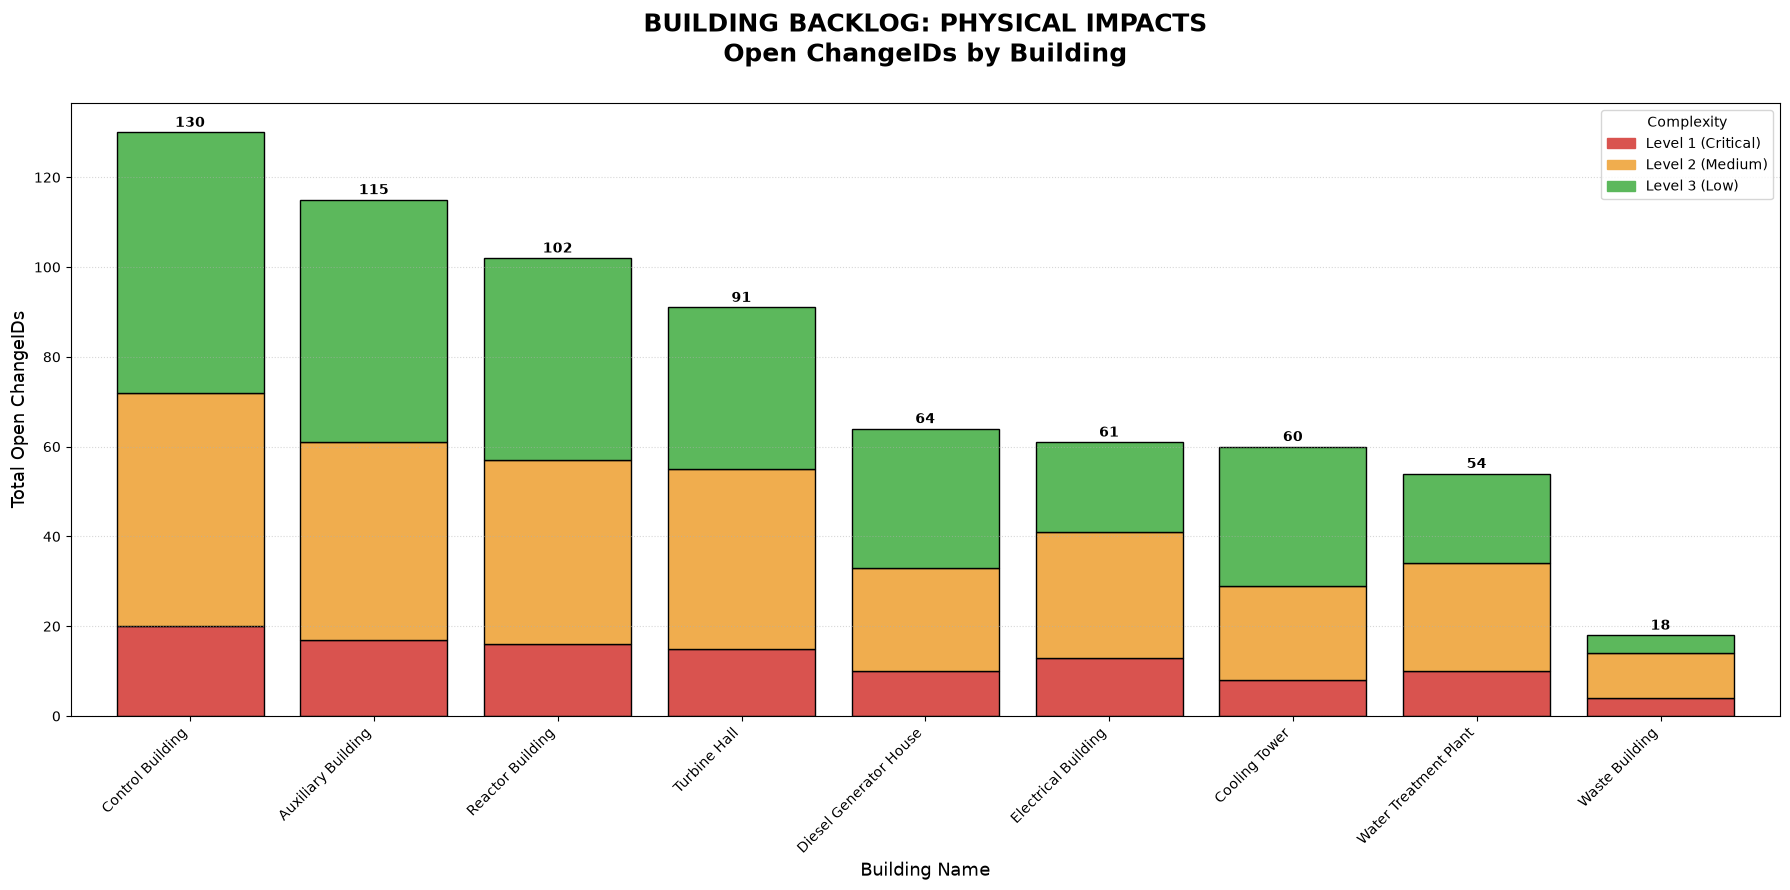

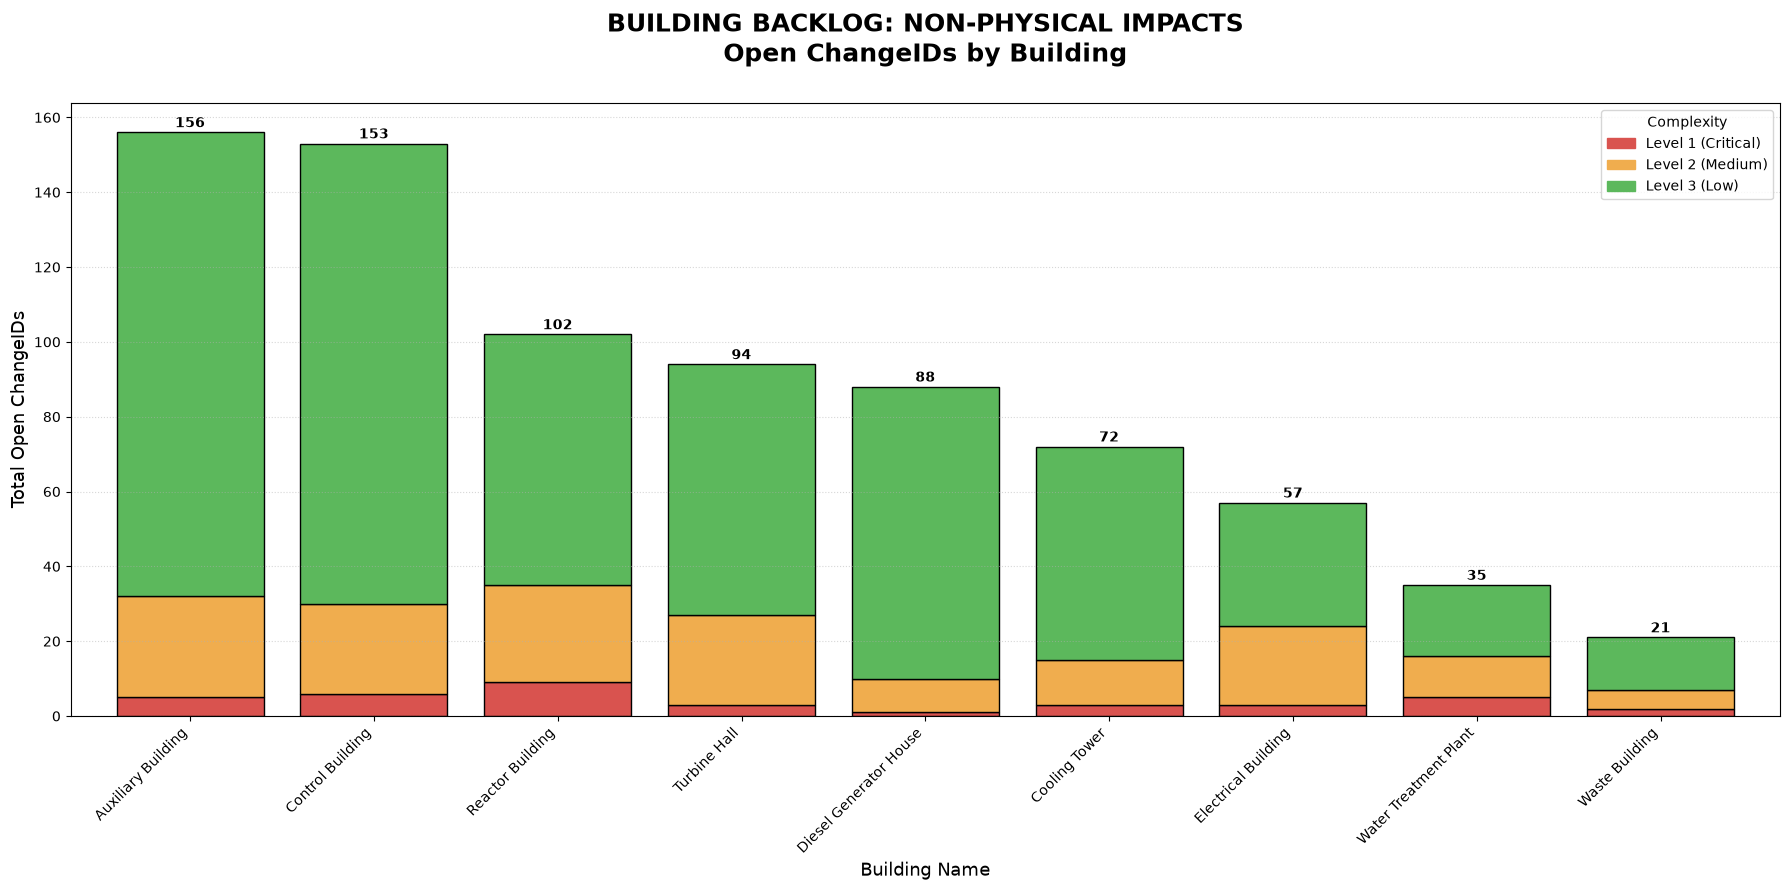

In [17]:
# ==============================================================================
# CELL 15 — BUILDING BACKLOG
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_building_backlog(df_source, impact_bool, title_label):
    subset = df_source[
        (df_source['Status'].str.upper() != 'CLOSED') &
        (df_source['Physical_Impacts'] == impact_bool)
    ].copy()

    if subset.empty:
        print(f'No data for {title_label}')
        return

    counts = (
        subset.groupby(['Building_Name', 'Level'])['ChangeID']
        .nunique()
        .unstack(fill_value=0)
    )
    for lvl in [1, 2, 3]:
        if lvl not in counts.columns:
            counts[lvl] = 0
    counts['Total'] = counts[1] + counts[2] + counts[3]
    counts = counts.sort_values('Total', ascending=False)

    fig, ax = plt.subplots(figsize=(18, 9))
    colors = ['#d9534f', '#f0ad4e', '#5cb85c']
    counts[[1, 2, 3]].plot(
        kind='bar', stacked=True, ax=ax,
        color=colors, edgecolor='black', width=0.8
    )
    for i, total in enumerate(counts['Total']):
        ax.text(i, total + 0.5, int(total),
                ha='center', va='bottom',
                fontweight='bold', fontsize=10)

    plt.title(f'BUILDING BACKLOG: {title_label}\nOpen ChangeIDs by Building',
              fontsize=18, fontweight='bold', pad=30)
    plt.ylabel('Total Open ChangeIDs', fontsize=13)
    plt.xlabel('Building Name', fontsize=13)

    patch1 = mpatches.Patch(color='#d9534f', label='Level 1 (Critical)')
    patch2 = mpatches.Patch(color='#f0ad4e', label='Level 2 (Medium)')
    patch3 = mpatches.Patch(color='#5cb85c', label='Level 3 (Low)')
    plt.legend(handles=[patch1, patch2, patch3], title='Complexity', loc='upper right')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_building_backlog(fact_location_exploded, True,  'PHYSICAL IMPACTS')
plot_building_backlog(fact_location_exploded, False, 'NON-PHYSICAL IMPACTS')

✅ df_closed_buildings: 26,581 rows | 14,292 unique closed changes | 9 buildings
✅ df_active_buildings: 1,473 rows | 708 unique open changes | 9 buildings

── BUILDING LEAD TIME ───────────────────────────────────────────────
wrote gold_building_leadtime_physical      9 rows -> data/gold/gold_building_leadtime_physical.parquet  (from: fact_location_exploded)


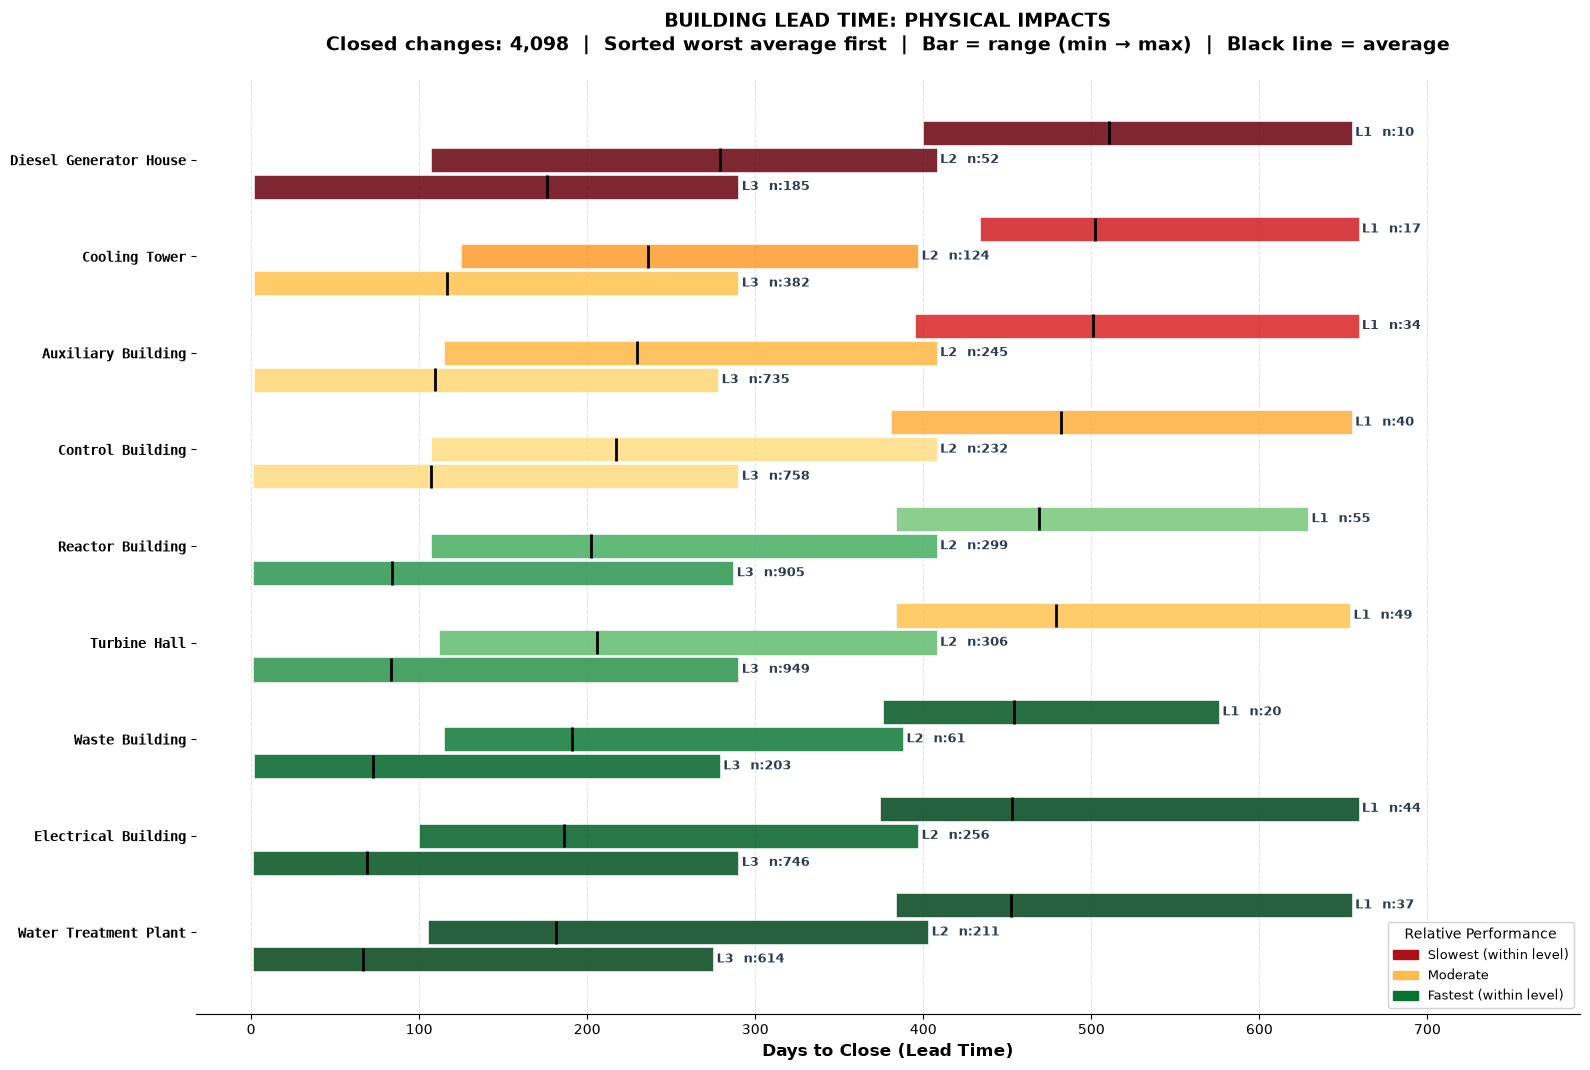

,Building,Avg Lead Time (d),Closed Changes
3,Diesel Generator House,211,247
2,Cooling Tower,158,523
0,Auxiliary Building,152,1014
1,Control Building,146,1030
5,Reactor Building,129,1259
6,Turbine Hall,127,1304
7,Waste Building,125,284
4,Electrical Building,114,1046
8,Water Treatment Plant,111,862


wrote gold_building_leadtime_non_physical      9 rows -> data/gold/gold_building_leadtime_non_physical.parquet  (from: fact_location_exploded)


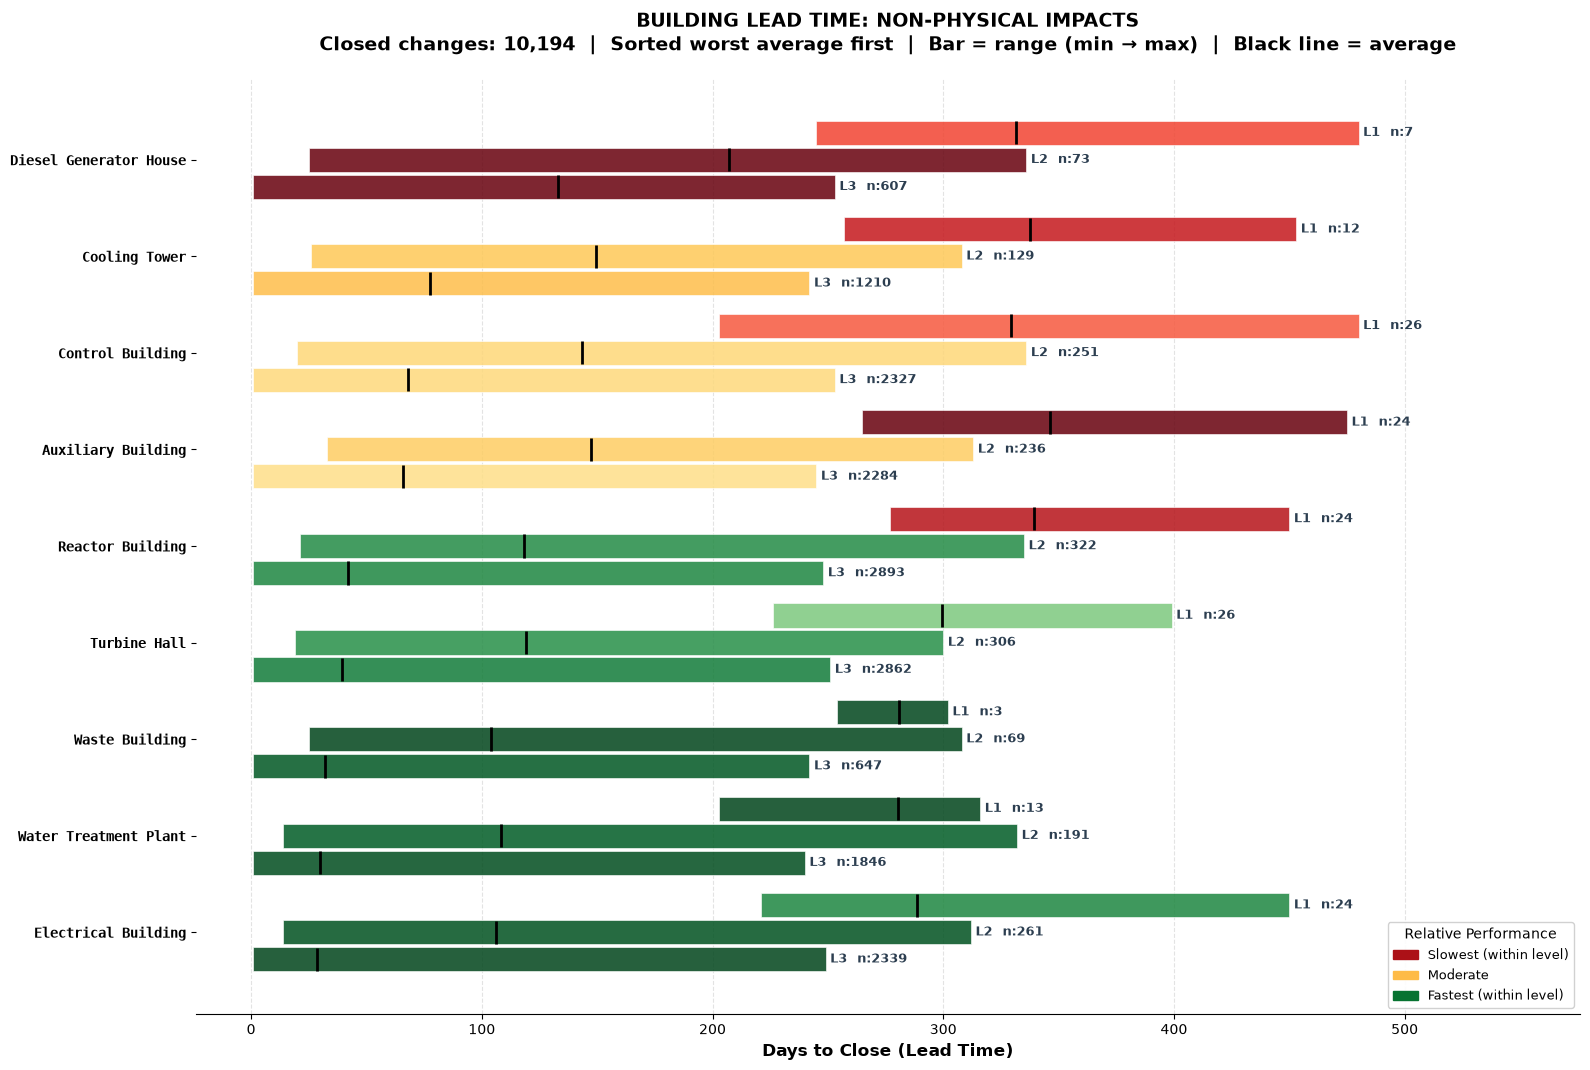

,Building,Avg Lead Time (d),Closed Changes
3,Diesel Generator House,143,687
2,Cooling Tower,87,1351
1,Control Building,78,2604
0,Auxiliary Building,76,2544
5,Reactor Building,52,3239
6,Turbine Hall,49,3194
7,Waste Building,40,719
8,Water Treatment Plant,39,2050
4,Electrical Building,39,2624



── BUILDING STAGNATION ──────────────────────────────────────────────
wrote gold_building_stagnation_physical      9 rows -> data/gold/gold_building_stagnation_physical.parquet  (from: fact_location_exploded)


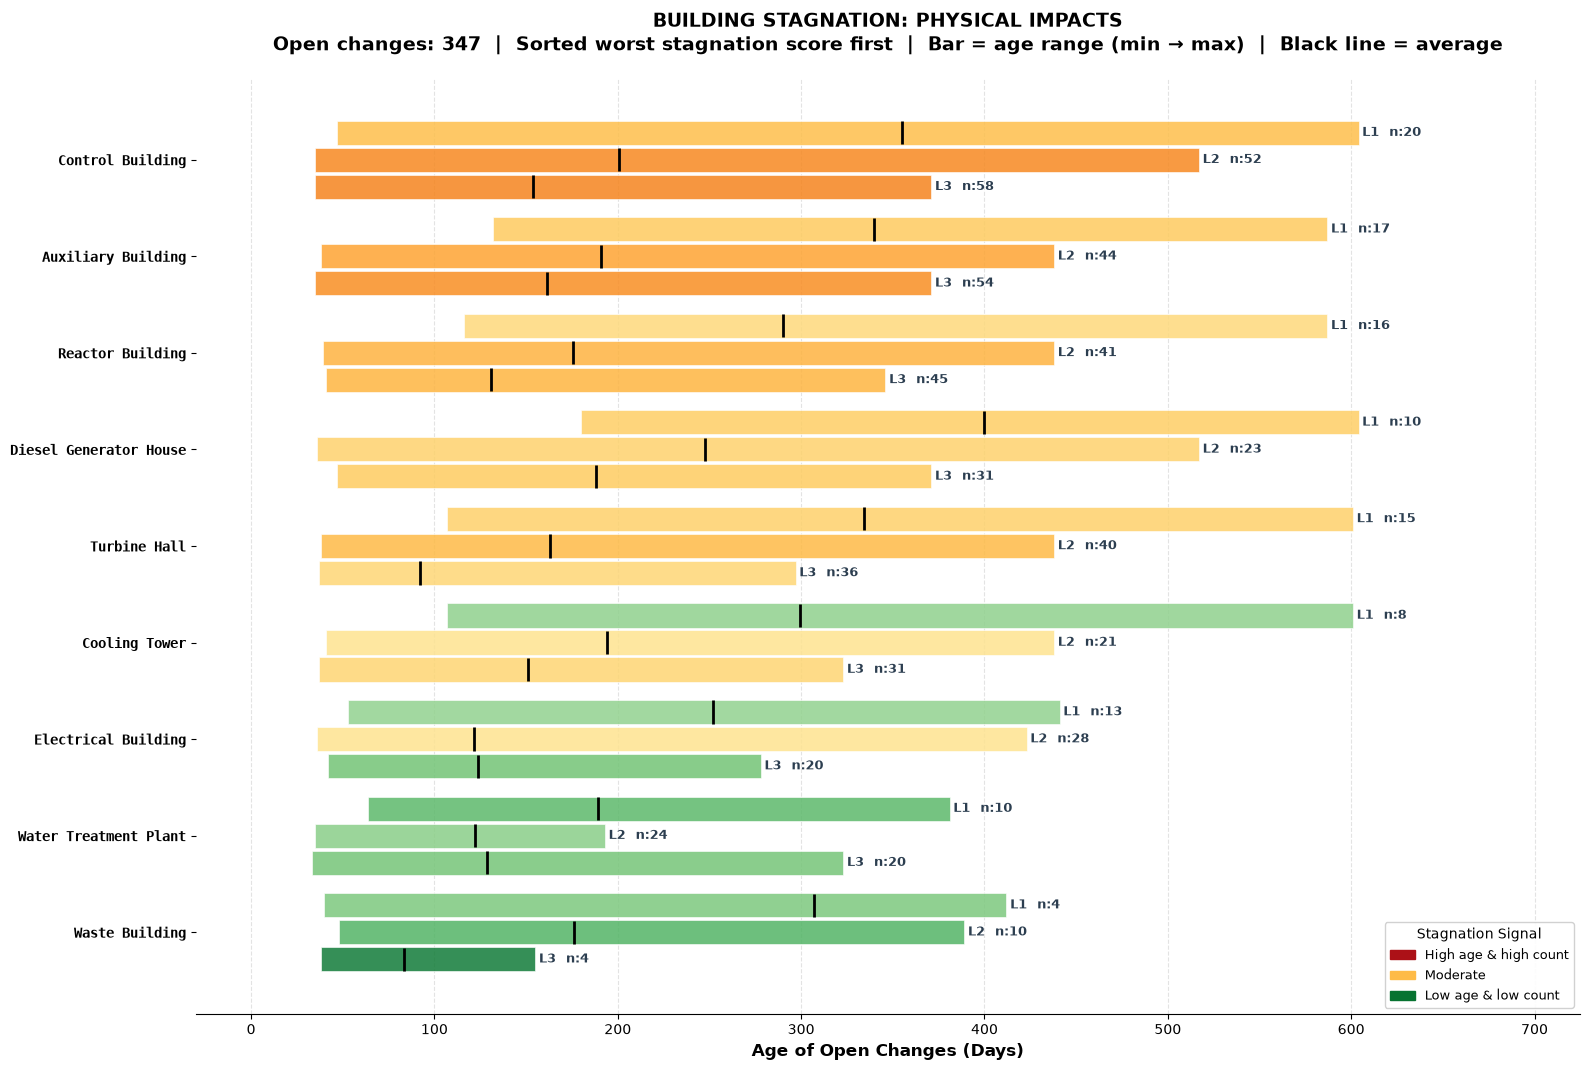

,Building,Stagnation Score,Open Changes,Avg Age (d)
1,Control Building,26457,130,236
0,Auxiliary Building,22894,115,231
5,Reactor Building,17715,102,199
3,Diesel Generator House,15522,64,278
6,Turbine Hall,14844,91,196
2,Cooling Tower,11154,60,215
4,Electrical Building,9147,61,166
8,Water Treatment Plant,7393,54,147
7,Waste Building,3321,18,189


wrote gold_building_stagnation_non_physical      9 rows -> data/gold/gold_building_stagnation_non_physical.parquet  (from: fact_location_exploded)


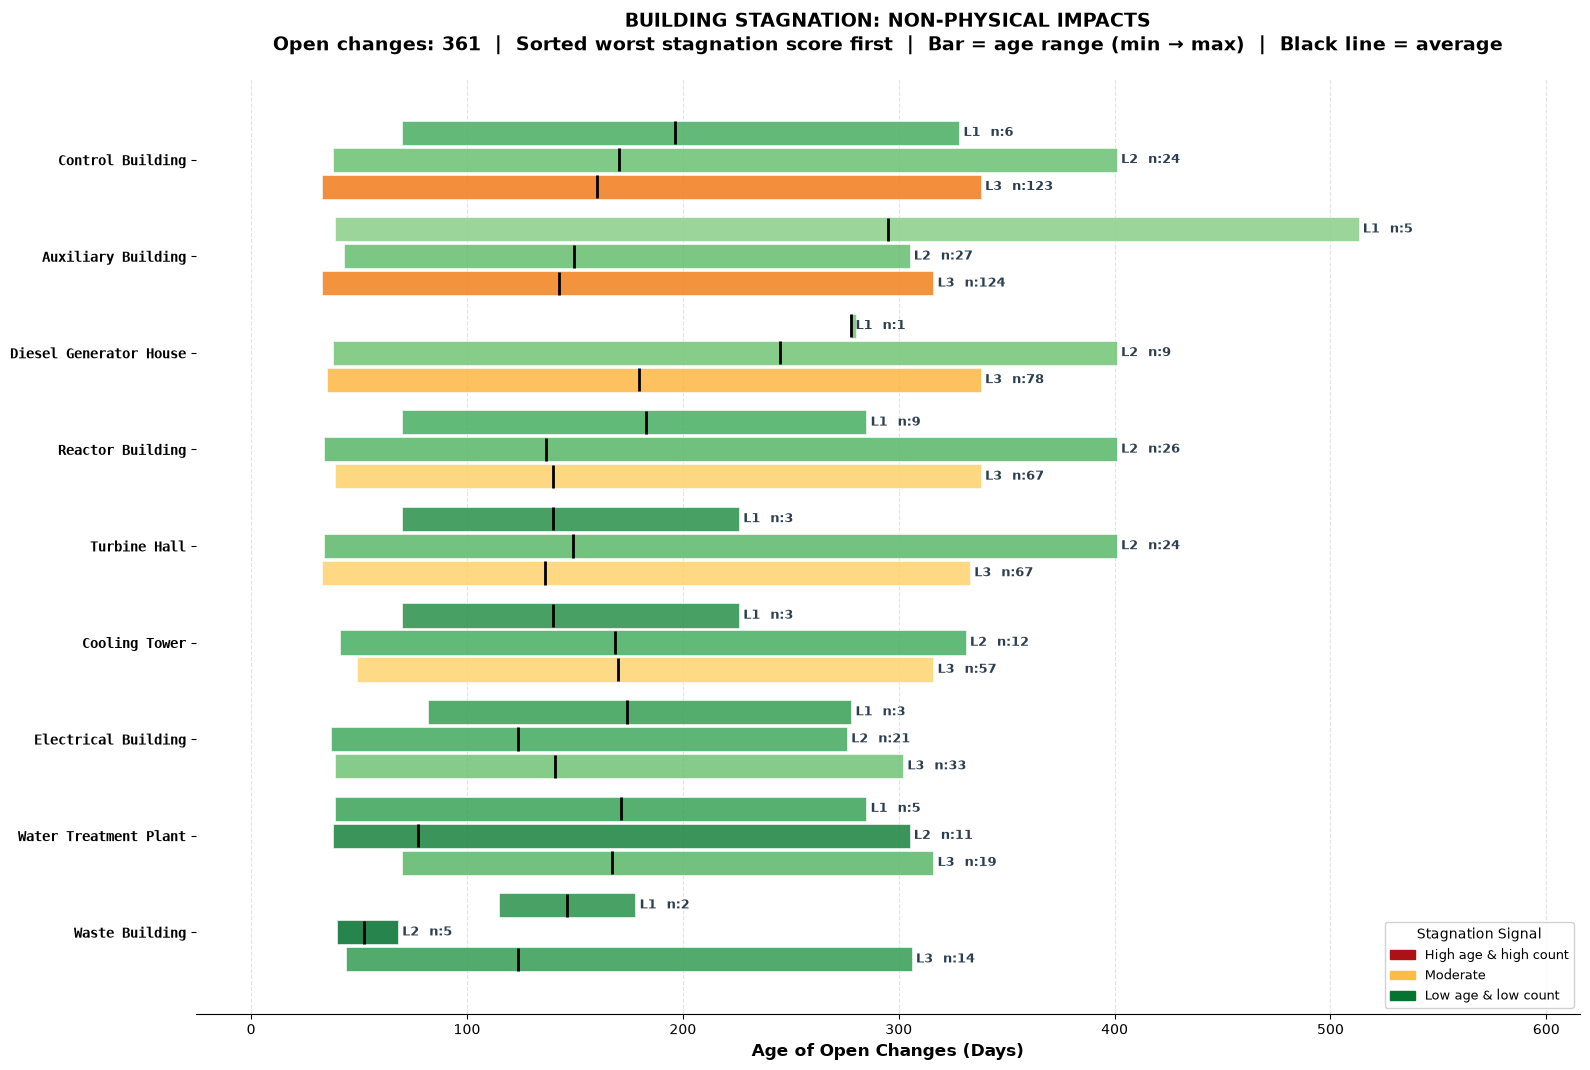

,Building,Stagnation Score,Open Changes,Avg Age (d)
1,Control Building,25003,153,176
0,Auxiliary Building,23186,156,196
3,Diesel Generator House,16512,88,234
5,Reactor Building,14583,102,153
6,Turbine Hall,13131,94,142
2,Cooling Tower,12122,72,159
4,Electrical Building,7765,57,146
8,Water Treatment Plant,4883,35,139
7,Waste Building,2286,21,108


In [18]:
# ==============================================================================
# CELL 16 — BUILDING ANALYSIS
# Two charts mirroring Cell 11 and Cell 12 at building grain.
#
# Chart 1: BUILDING LEAD TIME (historical — closed changes)
#   - Days_to_Close per building × level
#   - Range bars min → max, black line = average
#   - Colour = relative performance within level (darkest red = slowest)
#   - Sorted worst average lead time first
#
# Chart 2: BUILDING STAGNATION (current — open changes)
#   - Current_Age_Days per building × level
#   - Range bars min → max, black line = average
#   - Colour = age × count score (darkest red = worst stagnation)
#   - Sorted worst stagnation score first
#
# Grain reference:
#   df_closed_buildings    ChangeID × Building    closed changes only
#   df_active_buildings    ChangeID × Building    open changes only
#   Both deduplicated on ['ChangeID', 'Building_Name'] before aggregation
#   to collapse zone fan-out — a change in 3 zones of same building = 1 row.
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

import sys
sys.path.insert(0, str(ROOT / "src"))
from lineage import write_layer

# ── CONFIG ────────────────────────────────────────────────────────────────────
LEVEL_COLORS  = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}
level_offsets = {1: -0.28, 2: 0, 3: 0.28}

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '16px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

# ── COLOUR FUNCTIONS ──────────────────────────────────────────────────────────
def get_leadtime_color(avg_lt, min_lt, max_lt):
    """Min-max normalised within level. Best = darkest green, worst = darkest red."""
    rng   = max_lt - min_lt
    score = (avg_lt - min_lt) / rng if rng > 0 else 0.5
    if score >= 0.66:
        return plt.get_cmap('Reds')(0.4 + 0.6 * ((score - 0.66) / 0.34))
    elif score >= 0.33:
        return plt.get_cmap('YlOrBr')(0.4 * 0.6 + 0.6 * ((score - 0.33) / 0.33) * 0.6)
    else:
        return plt.get_cmap('Greens')(0.4 + 0.6 * (1 - (score / 0.33)))

def get_stagnation_color(avg_age, id_count, max_age, max_count):
    """Age × count score. High age + high count = darkest red."""
    age_ratio   = avg_age  / max_age   if max_age   > 0 else 0
    count_ratio = id_count / max_count if max_count > 0 else 0
    score       = (age_ratio + count_ratio) / 2
    if score >= 0.66:
        return plt.get_cmap('Reds')(0.4 + 0.6 * ((score - 0.66) / 0.34))
    elif score >= 0.33:
        return plt.get_cmap('YlOrBr')((0.4 + 0.6 * ((score - 0.33) / 0.33)) * 0.6)
    else:
        return plt.get_cmap('Greens')(0.4 + 0.6 * (1 - (score / 0.33)))


# ── SILVER TABLES ─────────────────────────────────────────────────────────────
# Deduplicate on ChangeID × Building_Name to collapse zone fan-out.
# A change touching 3 zones in the same building counts once per building.

df_closed_buildings = (
    fact_location_exploded[fact_location_exploded['Status'] == 'Closed']
    [['ChangeID', 'Level', 'Physical_Impacts', 'Building_Name',
      'Building_Type', 'Days_to_Close']]
    .drop_duplicates(['ChangeID', 'Building_Name'])
    .copy()
)
df_closed_buildings['Level'] = pd.to_numeric(
    df_closed_buildings['Level'], errors='coerce'
).fillna(0).astype(int)

df_active_buildings = (
    fact_location_exploded[fact_location_exploded['Status'] != 'Closed']
    [['ChangeID', 'Level', 'Physical_Impacts', 'Building_Name',
      'Building_Type', 'Current_Age_Days']]
    .drop_duplicates(['ChangeID', 'Building_Name'])
    .copy()
)
df_active_buildings['Level'] = pd.to_numeric(
    df_active_buildings['Level'], errors='coerce'
).fillna(0).astype(int)

print(f'✅ df_closed_buildings: {len(df_closed_buildings):,} rows | '
      f'{df_closed_buildings["ChangeID"].nunique():,} unique closed changes | '
      f'{df_closed_buildings["Building_Name"].nunique()} buildings')
print(f'✅ df_active_buildings: {len(df_active_buildings):,} rows | '
      f'{df_active_buildings["ChangeID"].nunique():,} unique open changes | '
      f'{df_active_buildings["Building_Name"].nunique()} buildings')


# ==============================================================================
# CHART 1 — BUILDING LEAD TIME (historical)
# Grain: ChangeID × Building (closed) → aggregated to Building × Level
# ==============================================================================

def plot_building_leadtime(df, impact_filter=None, title_suffix='ALL IMPACTS'):
    """
    Range bar chart of historical closure lead time per building × level.
    impact_filter: True = physical, False = non-physical, None = all
    """
    if impact_filter is not None:
        df = df[df['Physical_Impacts'] == impact_filter]

    df = df[df['Days_to_Close'].notna()]

    if df.empty:
        print(f'No closed data for {title_suffix}')
        return

    # Aggregate to building × level grain
    agg = (
        df.groupby(['Building_Name', 'Level'])
        .agg(
            Closed_Count  = ('ChangeID',      'nunique'),
            Avg_Lead_Time = ('Days_to_Close', 'mean'),
            Min_Lead_Time = ('Days_to_Close', 'min'),
            Max_Lead_Time = ('Days_to_Close', 'max'),
        )
        .reset_index()
    )

    # System-level summary for sort order
    bld_agg = (
        df.groupby('Building_Name')
        .agg(
            Avg_Lead_Time = ('Days_to_Close', 'mean'),
            Closed_Count  = ('ChangeID',      'nunique'),
        )
        .reset_index()
        .sort_values('Avg_Lead_Time', ascending=False)
    )

    _suffix = "physical" if impact_filter is True else "non_physical" if impact_filter is False else "all"
    write_layer(bld_agg, f"gold_building_leadtime_{_suffix}", ROOT / "data" / "gold",
                sources=["fact_location_exploded"])

    building_order = bld_agg['Building_Name'].tolist()
    n_bld          = len(building_order)

    # Per-level min/max for normalised colouring
    level_ranges = {}
    for lvl, grp in agg.groupby('Level'):
        level_ranges[int(lvl)] = {
            'min_lt': float(grp['Avg_Lead_Time'].min()),
            'max_lt': float(grp['Avg_Lead_Time'].max()),
        }

    fig, ax = plt.subplots(figsize=(16, max(8, n_bld * 1.2)))

    for i, bld in enumerate(building_order):
        bld_rows = agg[agg['Building_Name'] == bld]
        for _, row in bld_rows.iterrows():
            lvl   = int(row['Level'])
            y_pos = i + level_offsets.get(lvl, 0)
            rng   = level_ranges.get(lvl, {})
            color = get_leadtime_color(
                float(row['Avg_Lead_Time']),
                float(rng.get('min_lt', 0)),
                float(rng.get('max_lt', 1)),
            )
            bar_width = max(2, row['Max_Lead_Time'] - row['Min_Lead_Time'])
            ax.barh(y_pos, bar_width, left=row['Min_Lead_Time'],
                    height=0.25, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, zorder=3)
            ax.vlines(row['Avg_Lead_Time'], y_pos - 0.12, y_pos + 0.12,
                      color='black', linewidth=2, zorder=5)
            ax.text(row['Max_Lead_Time'] + 2, y_pos,
                    f"L{lvl}  n:{int(row['Closed_Count'])}",
                    va='center', ha='left', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(n_bld))
    ax.set_yticklabels(building_order, fontsize=10, fontweight='bold',
                       fontfamily='monospace')
    ax.invert_yaxis()
    ax.set_xlim(-agg['Max_Lead_Time'].max() * 0.05,
                 agg['Max_Lead_Time'].max() * 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Days to Close (Lead Time)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'BUILDING LEAD TIME: {title_suffix}\n'
        f'Closed changes: {df["ChangeID"].nunique():,}  |  '
        f'Sorted worst average first  |  '
        f'Bar = range (min → max)  |  Black line = average',
        fontsize=14, fontweight='bold', pad=20
    )

    patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),   label='Slowest (within level)'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.4),  label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85), label='Fastest (within level)'),
    ]
    ax.legend(handles=patches, loc='lower right', framealpha=0.9,
              fontsize=9, title='Relative Performance')
    plt.tight_layout()
    plt.show()

    # Gold table
    display(
        bld_agg.rename(columns={
            'Building_Name':  'Building',
            'Avg_Lead_Time':  'Avg Lead Time (d)',
            'Closed_Count':   'Closed Changes',
        }).style
        .background_gradient(subset=['Avg Lead Time (d)'], cmap='RdYlGn_r', vmin=0)
        .set_caption(f'🥇 Building Lead Time: {title_suffix}')
        .format({'Avg Lead Time (d)': '{:.0f}'})
        .set_table_styles(TABLE_STYLES)
    )


# ==============================================================================
# CHART 2 — BUILDING STAGNATION (current)
# Grain: ChangeID × Building (open) → aggregated to Building × Level
# ==============================================================================

def plot_building_stagnation(df, impact_filter=None, title_suffix='ALL IMPACTS'):
    """
    Range bar chart of current open change age per building × level.
    impact_filter: True = physical, False = non-physical, None = all
    """
    if impact_filter is not None:
        df = df[df['Physical_Impacts'] == impact_filter]

    df = df[df['Current_Age_Days'].notna()]

    if df.empty:
        print(f'No open data for {title_suffix}')
        return

    # Aggregate to building × level grain
    agg = (
        df.groupby(['Building_Name', 'Level'])
        .agg(
            ID_Count = ('ChangeID',         'nunique'),
            Avg_Age  = ('Current_Age_Days', 'mean'),
            Min_Age  = ('Current_Age_Days', 'min'),
            Max_Age  = ('Current_Age_Days', 'max'),
        )
        .reset_index()
    )
    agg['Score'] = agg['Avg_Age'] * agg['ID_Count']

    # Building-level stagnation score for sort order
    bld_scores = (
        agg.groupby('Building_Name')
        .agg(
            Total_Score  = ('Score',    'sum'),
            Total_Open   = ('ID_Count', 'sum'),
            Avg_Age      = ('Avg_Age',  'mean'),
        )
        .reset_index()
        .sort_values('Total_Score', ascending=False)
    )

    _suffix = "physical" if impact_filter is True else "non_physical" if impact_filter is False else "all"
    write_layer(bld_scores, f"gold_building_stagnation_{_suffix}", ROOT / "data" / "gold",
                sources=["fact_location_exploded"])

    building_order = bld_scores['Building_Name'].tolist()
    n_bld          = len(building_order)
    max_age_glob   = float(agg['Max_Age'].max()) or 1
    max_count_glob = float(agg['ID_Count'].max()) or 1

    fig, ax = plt.subplots(figsize=(16, max(8, n_bld * 1.2)))

    for i, bld in enumerate(building_order):
        bld_rows = agg[agg['Building_Name'] == bld]
        for _, row in bld_rows.iterrows():
            lvl   = int(row['Level'])
            y_pos = i + level_offsets.get(lvl, 0)
            color = get_stagnation_color(
                float(row['Avg_Age']), float(row['ID_Count']),
                max_age_glob, max_count_glob
            )
            bar_width = max(2, row['Max_Age'] - row['Min_Age'])
            ax.barh(y_pos, bar_width, left=row['Min_Age'],
                    height=0.25, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, zorder=3)
            ax.vlines(row['Avg_Age'], y_pos - 0.12, y_pos + 0.12,
                      color='black', linewidth=2, zorder=5)
            ax.text(row['Max_Age'] + 2, y_pos,
                    f"L{lvl}  n:{int(row['ID_Count'])}",
                    va='center', ha='left', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(n_bld))
    ax.set_yticklabels(building_order, fontsize=10, fontweight='bold',
                       fontfamily='monospace')
    ax.invert_yaxis()
    ax.set_xlim(-max_age_glob * 0.05, max_age_glob * 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Age of Open Changes (Days)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'BUILDING STAGNATION: {title_suffix}\n'
        f'Open changes: {df["ChangeID"].nunique():,}  |  '
        f'Sorted worst stagnation score first  |  '
        f'Bar = age range (min → max)  |  Black line = average',
        fontsize=14, fontweight='bold', pad=20
    )

    patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),   label='High age & high count'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.4),  label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85), label='Low age & low count'),
    ]
    ax.legend(handles=patches, loc='lower right', framealpha=0.9,
              fontsize=9, title='Stagnation Signal')
    plt.tight_layout()
    plt.show()

    # Gold table
    display(
        bld_scores.rename(columns={
            'Building_Name': 'Building',
            'Total_Score':   'Stagnation Score',
            'Total_Open':    'Open Changes',
            'Avg_Age':       'Avg Age (d)',
        }).style
        .background_gradient(subset=['Stagnation Score'], cmap='RdYlGn_r')
        .set_caption(f'🥇 Building Stagnation: {title_suffix}')
        .format({'Stagnation Score': '{:.0f}', 'Avg Age (d)': '{:.0f}'})
        .set_table_styles(TABLE_STYLES)
    )


# ── RUN ───────────────────────────────────────────────────────────────────────
print('\n── BUILDING LEAD TIME ───────────────────────────────────────────────')
plot_building_leadtime(df_closed_buildings, impact_filter=True,  title_suffix='PHYSICAL IMPACTS')
plot_building_leadtime(df_closed_buildings, impact_filter=False, title_suffix='NON-PHYSICAL IMPACTS')

print('\n── BUILDING STAGNATION ──────────────────────────────────────────────')
plot_building_stagnation(df_active_buildings, impact_filter=True,  title_suffix='PHYSICAL IMPACTS')
plot_building_stagnation(df_active_buildings, impact_filter=False, title_suffix='NON-PHYSICAL IMPACTS')

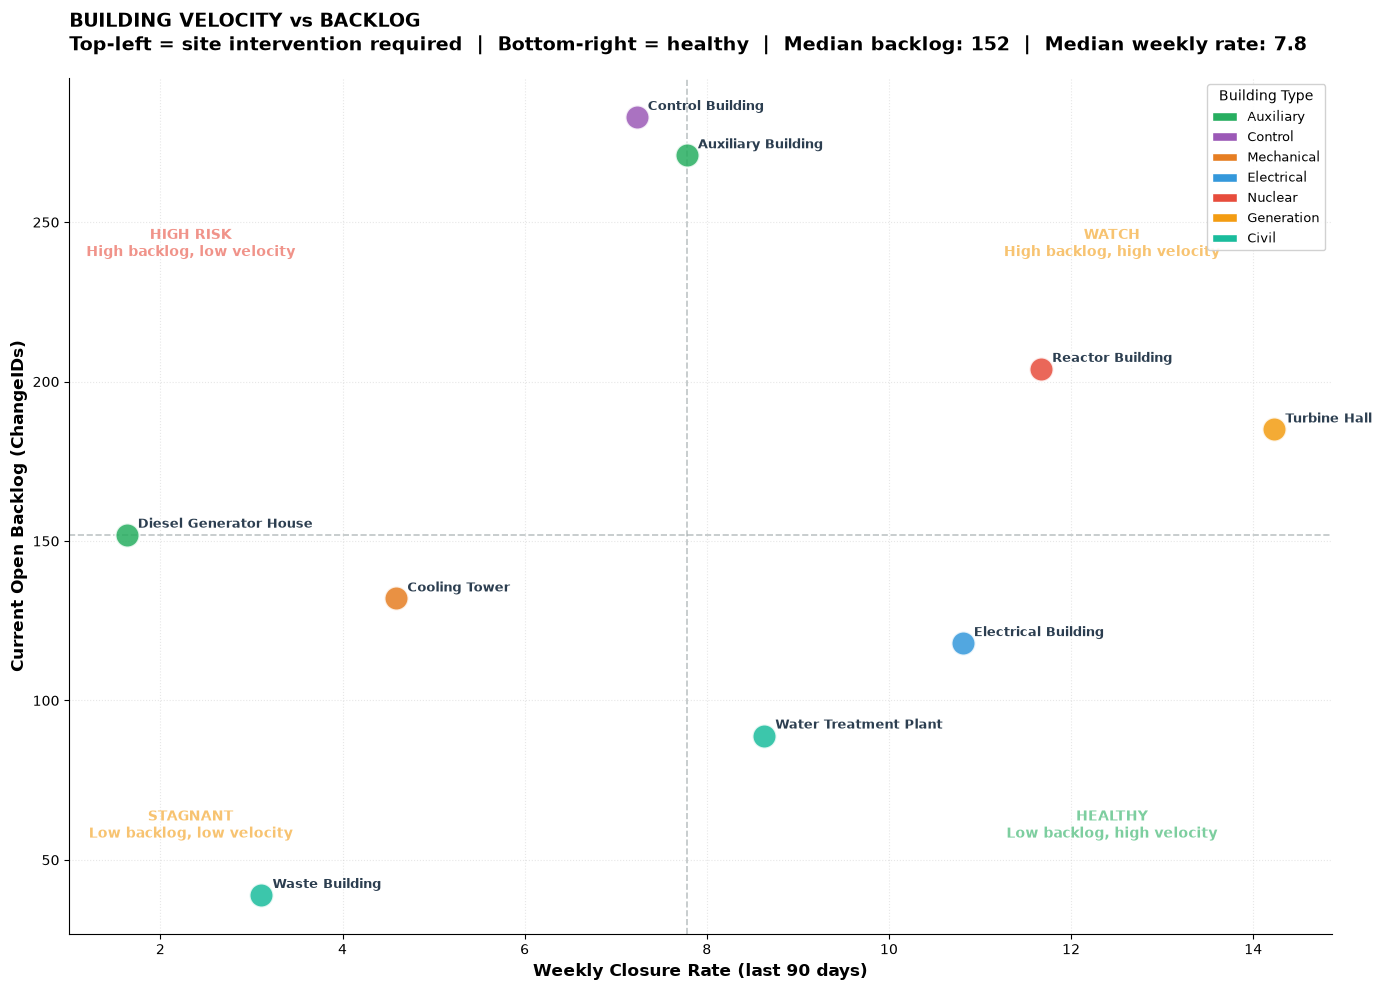

In [19]:
# ==============================================================================
# CELL 16b — BUILDING ANALYSIS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── CONFIG ────────────────────────────────────────────────────────────────────
BUILDING_TYPE_COLORS = {
    'Nuclear':      '#e74c3c',
    'Generation':   '#f39c12',
    'Control':      '#9b59b6',
    'Electrical':   '#3498db',
    'Auxiliary':    '#27ae60',
    'Civil':        '#1abc9c',
    'Mechanical':   '#e67e22',
    'Admin':        '#7f8c8d',
}

# ── DATA PREP ─────────────────────────────────────────────────────────────────
lookback = ts_sim_today - pd.Timedelta(days=90)

building_backlog = (
    fact_location_exploded[fact_location_exploded['Status'] != 'Closed']
    [['ChangeID', 'Building_Name', 'Building_Type']]
    .drop_duplicates(['ChangeID', 'Building_Name'])
    .groupby(['Building_Name', 'Building_Type'])['ChangeID']
    .nunique()
    .reset_index(name='Open_Backlog')
)

building_velocity = (
    fact_location_exploded[
        (fact_location_exploded['Status'] == 'Closed') &
        (pd.to_datetime(fact_location_exploded['DateClosed']) >= lookback) &
        (pd.to_datetime(fact_location_exploded['DateClosed']) <= ts_sim_today)
    ]
    [['ChangeID', 'Building_Name']]
    .drop_duplicates(['ChangeID', 'Building_Name'])
    .groupby('Building_Name')['ChangeID']
    .nunique()
    .reset_index(name='Recent_Closures')
)
building_velocity['Weekly_Rate'] = (
    building_velocity['Recent_Closures'] / 90 * 7
).round(2)

scatter_df = (
    building_backlog
    .merge(building_velocity[['Building_Name', 'Weekly_Rate']],
           on='Building_Name', how='left')
)
scatter_df['Weekly_Rate'] = scatter_df['Weekly_Rate'].fillna(0)

# ── QUADRANT MEDIANS ──────────────────────────────────────────────────────────
median_backlog  = scatter_df['Open_Backlog'].median()
median_velocity = scatter_df['Weekly_Rate'].median()

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

for _, row in scatter_df.iterrows():
    color = BUILDING_TYPE_COLORS.get(row['Building_Type'], '#7f8c8d')
    ax.scatter(row['Weekly_Rate'], row['Open_Backlog'],
               color=color, s=300, alpha=0.85,
               edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(row['Building_Name'],
                (row['Weekly_Rate'], row['Open_Backlog']),
                textcoords='offset points', xytext=(8, 5),
                fontsize=9, fontweight='bold', color='#2c3e50')

ax.axvline(median_velocity, color='#7f8c8d',
           linestyle='--', linewidth=1.2, alpha=0.5)
ax.axhline(median_backlog, color='#7f8c8d',
           linestyle='--', linewidth=1.2, alpha=0.5)

quadrant_labels = [
    (median_velocity * 0.3,  median_backlog * 1.6,
     'HIGH RISK\nHigh backlog, low velocity',  '#e74c3c'),
    (median_velocity * 1.6,  median_backlog * 1.6,
     'WATCH\nHigh backlog, high velocity',     '#f39c12'),
    (median_velocity * 0.3,  median_backlog * 0.4,
     'STAGNANT\nLow backlog, low velocity',    '#f39c12'),
    (median_velocity * 1.6,  median_backlog * 0.4,
     'HEALTHY\nLow backlog, high velocity',    '#27ae60'),
]

for x, y, label, color in quadrant_labels:
    ax.text(x, y, label, fontsize=10, color=color,
            fontweight='bold', alpha=0.6, ha='center', va='center')

type_patches = [
    mpatches.Patch(facecolor=BUILDING_TYPE_COLORS.get(bt, '#7f8c8d'),
                   edgecolor='white', label=bt)
    for bt in scatter_df['Building_Type'].unique()
]
ax.legend(handles=type_patches, loc='upper right',
          fontsize=9, title='Building Type', framealpha=0.9)

ax.set_xlabel('Weekly Closure Rate (last 90 days)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Current Open Backlog (ChangeIDs)',
              fontsize=12, fontweight='bold')
ax.set_title(
    'BUILDING VELOCITY vs BACKLOG\n'
    'Top-left = site intervention required  |  '
    'Bottom-right = healthy  |  '
    f'Median backlog: {int(median_backlog)}  |  '
    f'Median weekly rate: {median_velocity:.1f}',
    fontsize=14, fontweight='bold', loc='left', pad=20
)
ax.grid(linestyle=':', alpha=0.3, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
# ==============================================================================
# CELL 17 — BUILDING READINESS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── 1. CONFIG ─────────────────────────────────────────────────────────────────
SIM_TODAY = ts_sim_today 
LEVEL_COLORS = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}
RAG_RED, RAG_AMBER = 80, 95

def get_rag_color(pct):
    if pct < RAG_RED:   return '#c0392b'
    if pct < RAG_AMBER: return '#f39c12'
    return                   '#1e8449'

TABLE_STYLES = [
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', '#b8860b')]},
    {'selector': 'th', 'props': [('background-color', '#b8860b'), ('color', 'white')]}
]

# ── 2. DATA PREPARATION (UPDATED TO INCLUDE SYSTEM/MILESTONE) ─────────────────
df_readiness = (
    fact_enriched[['ChangeID', 'Level', 'Physical_Impacts', 'Status', 'Driving_System', 'Driving_Milestone']]
    .merge(fact_location_exploded[['ChangeID', 'Building_Name']].drop_duplicates(), on='ChangeID', how='left')
)

# Rename to match your expected 'SystemCode' if necessary
df_readiness = df_readiness.rename(columns={'Driving_System': 'SystemCode', 'Driving_Milestone': 'Milestone_ID'})

df_readiness['Building_Name'] = df_readiness['Building_Name'].fillna('No Location')
df_readiness['Is_Closed'] = (df_readiness['Status'] == 'Closed').astype(int)

# Crucial: Drop duplicates ONLY on ChangeID + Building to avoid overcounting 
# if a change is linked to multiple systems in the same building
df_readiness = df_readiness.drop_duplicates(['ChangeID', 'Building_Name'])



# ── 3. WIDGET SETUP ───────────────────────────────────────────────────────────
building_list = sorted([b for b in df_readiness['Building_Name'].unique() if b != 'No Location'])
dropdown_options = ['ALL BUILDINGS'] + building_list + (['No Location'] if 'No Location' in df_readiness['Building_Name'].values else [])

dropdown = widgets.Dropdown(options=dropdown_options, value='ALL BUILDINGS', description='Building Scope:', layout={'width': '350px'})
output = widgets.Output()

# ── 4. DASHBOARD LOGIC ────────────────────────────────────────────────────────
def update_dashboard(change):
    selected_scope = change['new']
    with output:
        clear_output(wait=True)

        if selected_scope == 'ALL BUILDINGS':
            # --- VIEW: ALL BUILDINGS (Simplified, no Milestone bands) ---
            summary = df_readiness.groupby('Building_Name').agg(
                Total_Changes=('ChangeID', 'nunique'),
                Closed_Changes=('Is_Closed', 'sum')
            ).reset_index()

            summary['Readiness_Pct'] = (summary['Closed_Changes'] / summary['Total_Changes'] * 100).round(1)
            summary = summary.sort_values('Readiness_Pct', ascending=True) # Sort by progress

            fig, ax = plt.subplots(figsize=(12, len(summary) * 0.4 + 2))
            
            y_pos = np.arange(len(summary))
            ax.barh(y_pos, 100, color='#eeeeee', height=0.7) # Background
            ax.barh(y_pos, summary['Readiness_Pct'], color=[get_rag_color(p) for p in summary['Readiness_Pct']], height=0.7)

            for i, (pct, total, closed) in enumerate(zip(summary['Readiness_Pct'], summary['Total_Changes'], summary['Closed_Changes'])):
                ax.text(pct + 1, i, f"{pct}% ({int(closed)}/{int(total)})", va='center', fontweight='bold', fontsize=9)

            ax.set_yticks(y_pos)
            ax.set_yticklabels(summary['Building_Name'], fontfamily='monospace')
            ax.set_title(f"BUILDING READINESS SUMMARY | {SIM_TODAY.date()}", fontsize=15, fontweight='bold', loc='left')
            ax.set_xlim(0, 120)
            plt.show()
            group_cols = ['Building_Name', 'Level', 'Physical_Impacts']

        else:
            # --- VIEW: SINGLE BUILDING DRILLDOWN ---
            bld_data = df_readiness[df_readiness['Building_Name'] == selected_scope]
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

            # Priority Stats
            l_stats = bld_data.groupby('Level').agg(T=('ChangeID', 'nunique'), C=('Is_Closed', 'sum')).reset_index()
            l_stats['P'] = (l_stats['C'] / l_stats['T'] * 100).round(1)
            ax1.bar(l_stats['Level'].astype(str), l_stats['P'], color=[LEVEL_COLORS.get(l, 'grey') for l in l_stats['Level']])
            ax1.set_title("Readiness by Level"), ax1.set_ylim(0, 115)

            # Impact Stats
            i_stats = bld_data.groupby('Physical_Impacts').agg(T=('ChangeID', 'nunique'), C=('Is_Closed', 'sum')).reset_index()
            i_stats['P'] = (i_stats['C'] / i_stats['T'] * 100).round(1)
            ax2.bar(i_stats['Physical_Impacts'].map({True:'Phys', False:'Doc'}), i_stats['P'], color=['#34495e', '#95a5a6'])
            ax2.set_title("Physical vs Doc"), ax2.set_ylim(0, 115)

            plt.suptitle(f"DRILL-DOWN: {selected_scope}", fontsize=14, fontweight='bold')
            plt.show()
            group_cols = ['Level', 'Physical_Impacts']

        # --- SHARED TABLE ---
        data = df_readiness if selected_scope == 'ALL BUILDINGS' else df_readiness[df_readiness['Building_Name'] == selected_scope]
        table = data.groupby(group_cols).agg(Total=('ChangeID', 'nunique'), Closed=('Is_Closed', 'sum')).reset_index()
        table['Ready %'] = (table['Closed'] / table['Total'] * 100).round(1)
        
        display(table.style.background_gradient(subset=['Ready %'], cmap='RdYlGn', vmin=70, vmax=100)
                .set_caption(f"Detailed Data: {selected_scope}").set_table_styles(TABLE_STYLES))

# ── 5. EXECUTION ──────────────────────────────────────────────────────────────
dropdown.observe(update_dashboard, names='value')
display(widgets.VBox([dropdown, output]))
update_dashboard({'new': dropdown.value})

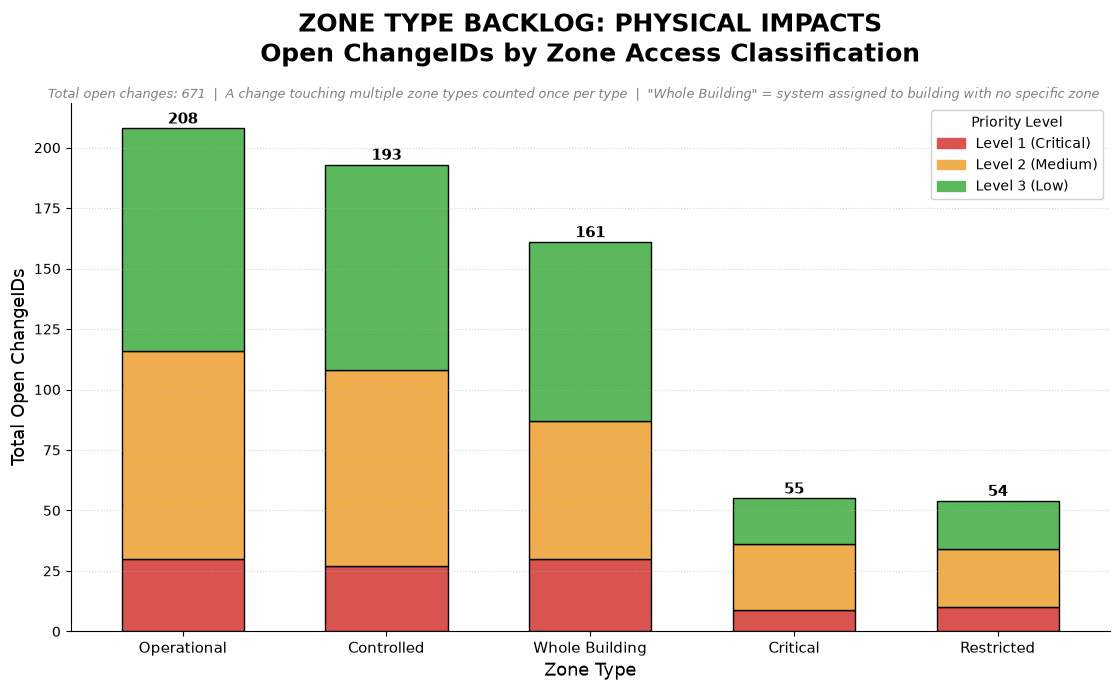

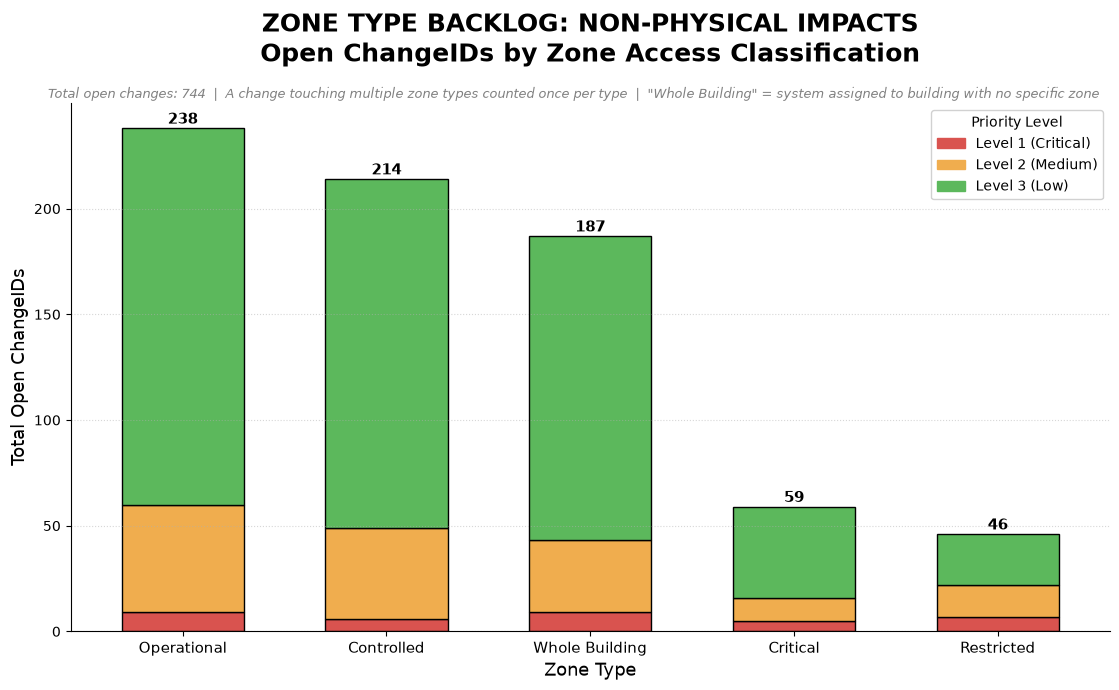

In [21]:
# ==============================================================================
# CELL 18 — ZONE TYPE BACKLOG CHART
# Stacked bar chart: open ChangeIDs per zone type × level
#
# Grain journey:
#   fact_location_exploded    ChangeID × System × Building × Zone  (raw)
#       ↓ drop_duplicates(['ChangeID', 'Zone_Type'])
#                             ChangeID × Zone_Type                 (silver)
#       ↓ groupby Zone_Type × Level + nunique(ChangeID)
#                             Zone_Type                            (gold)
#
# Zone types: Restricted, Controlled, Operational, Critical
# Whole-building assignments (Zone_ID = None) have no Zone_Type —
# shown as 'Whole Building' rather than dropped.
#
# Use case: risk profile by access classification — useful for safety
# and access planning rather than construction management.
#
# Two charts produced:
#   Physical Impacts
#   Non-Physical Impacts
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


def plot_zone_type_backlog(df_source, impact_bool, title_label):
    """
    Stacked bar chart of open change backlog per zone type × level.

    Parameters
    ----------
    df_source   : fact_location_exploded
                  Grain: ChangeID × System × Building × Zone
    impact_bool : True = physical impacts, False = non-physical
    title_label : string for chart title
    """

    # ── 1. Collapse to ChangeID × Zone_Type grain ─────────────────────────────
    # Whole-building assignments (Zone_ID = None) have no Zone_Type.
    # Label as 'Whole Building' so they remain visible.
    df_zt = df_source.copy()
    df_zt['Zone_Type'] = df_zt['Zone_Type'].fillna('Whole Building')
    df_zt = df_zt.drop_duplicates(['ChangeID', 'Zone_Type'])

    # ── 2. Filter: open changes of the requested impact type ──────────────────
    subset = df_zt[
        (df_zt['Status'].str.upper() != 'CLOSED') &
        (df_zt['Physical_Impacts'] == impact_bool)
    ].copy()

    if subset.empty:
        print(f'No data for {title_label}')
        return

    # ── 3. Aggregate to Zone_Type × Level grain ───────────────────────────────
    counts = (
        subset
        .groupby(['Zone_Type', 'Level'])['ChangeID']
        .nunique()
        .unstack(fill_value=0)
    )

    for lvl in [1, 2, 3]:
        if lvl not in counts.columns:
            counts[lvl] = 0

    counts['Total'] = counts[1] + counts[2] + counts[3]
    counts = counts.sort_values('Total', ascending=False)

    # ── 4. Plot ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 7))

    colors = ['#d9534f', '#f0ad4e', '#5cb85c']
    counts[[1, 2, 3]].plot(
        kind='bar', stacked=True, ax=ax,
        color=colors, edgecolor='black', width=0.6
    )

    # Total labels above each bar
    for i, total in enumerate(counts['Total']):
        ax.text(i, total + 0.5, int(total),
                ha='center', va='bottom',
                fontweight='bold', fontsize=11)

    # Subtitle note
    total_open = int(counts['Total'].sum())
    ax.text(0.99, 1.01,
            f'Total open changes: {total_open:,}  |  '
            f'A change touching multiple zone types counted once per type  |  '
            f'"Whole Building" = system assigned to building with no specific zone',
            transform=ax.transAxes, ha='right',
            fontsize=9, color='gray', style='italic')

    ax.set_title(
        f'ZONE TYPE BACKLOG: {title_label}\nOpen ChangeIDs by Zone Access Classification',
        fontsize=18, fontweight='bold', pad=30
    )
    ax.set_ylabel('Total Open ChangeIDs', fontsize=13)
    ax.set_xlabel('Zone Type', fontsize=13)
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', rotation=0, labelsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.spines[['top', 'right']].set_visible(False)

    patch1 = mpatches.Patch(color='#d9534f', label='Level 1 (Critical)')
    patch2 = mpatches.Patch(color='#f0ad4e', label='Level 2 (Medium)')
    patch3 = mpatches.Patch(color='#5cb85c', label='Level 3 (Low)')
    ax.legend(handles=[patch1, patch2, patch3],
              title='Priority Level', loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.show()


# ── RUN ───────────────────────────────────────────────────────────────────────
plot_zone_type_backlog(fact_location_exploded, True,  'PHYSICAL IMPACTS')
plot_zone_type_backlog(fact_location_exploded, False, 'NON-PHYSICAL IMPACTS')

✅ df_closed_zonetypes: 25,121 rows | 14,292 unique closed changes | 5 zone types
✅ df_active_zonetypes: 1,415 rows | 708 unique open changes | 5 zone types

── ZONE TYPE LEAD TIME ──────────────────────────────────────────────
wrote gold_zonetype_leadtime_physical      5 rows -> data/gold/gold_zonetype_leadtime_physical.parquet  (from: fact_location_exploded)


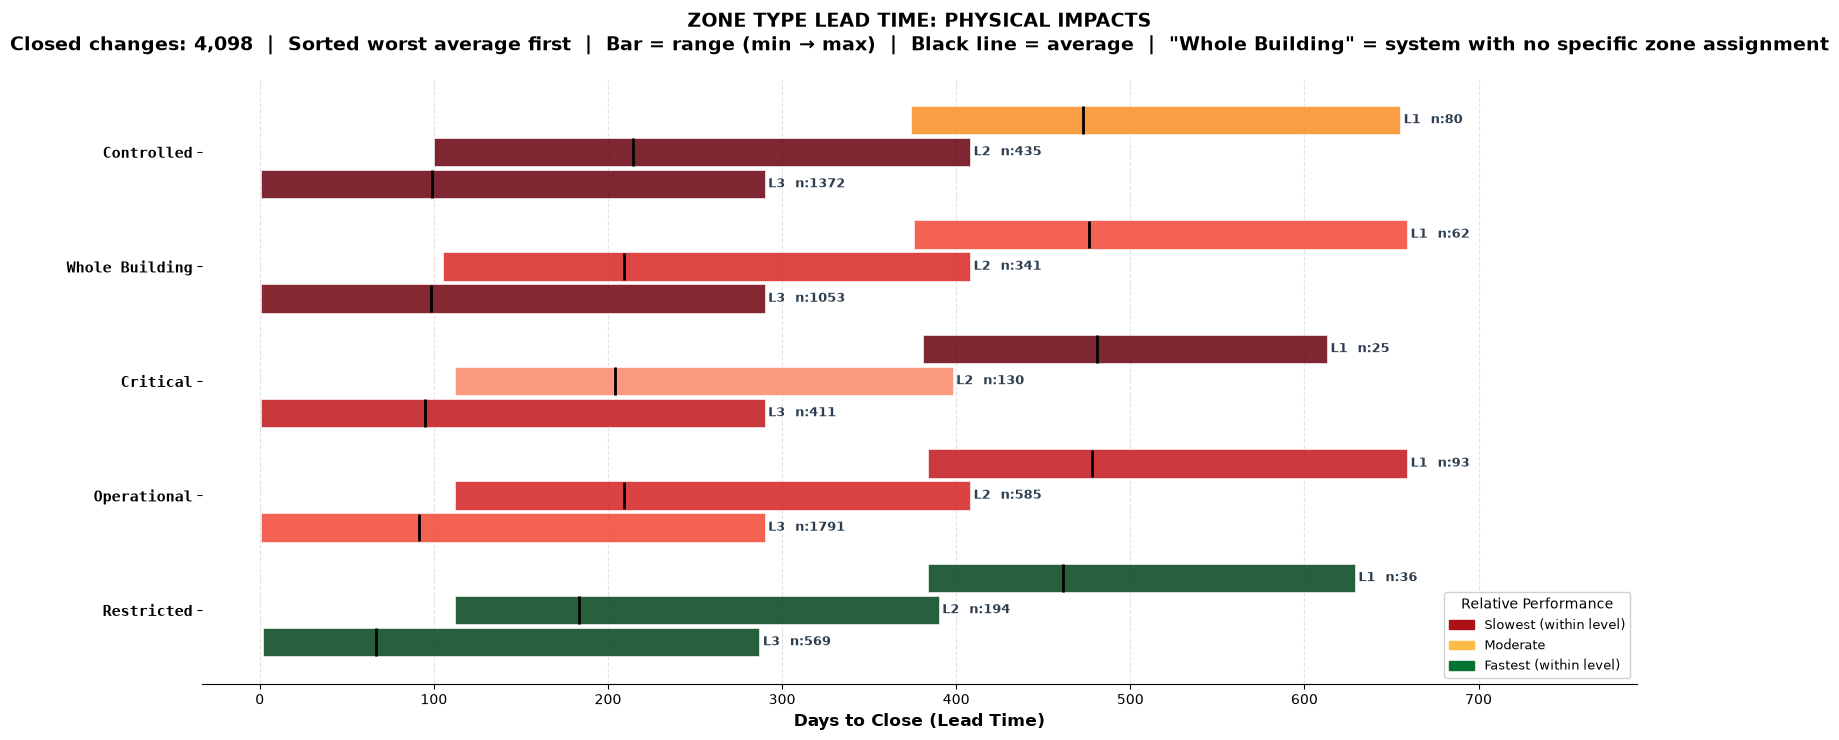

,Zone Type,Avg Lead Time (d),Closed Changes
0,Controlled,141,1887
4,Whole Building,140,1456
1,Critical,137,566
2,Operational,134,2469
3,Restricted,113,799


wrote gold_zonetype_leadtime_non_physical      5 rows -> data/gold/gold_zonetype_leadtime_non_physical.parquet  (from: fact_location_exploded)


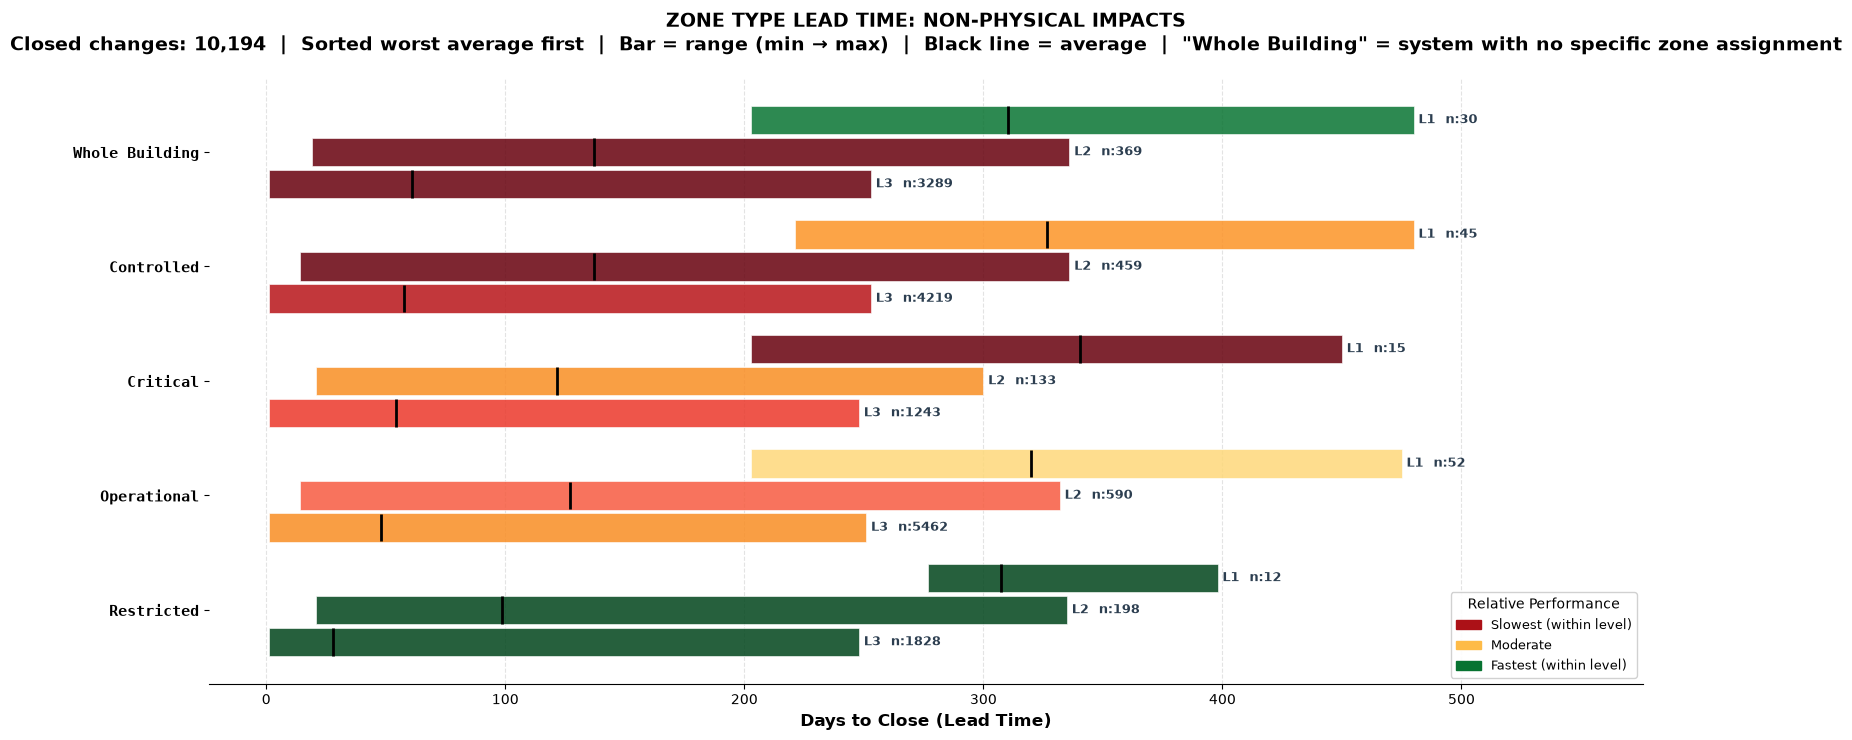

,Zone Type,Avg Lead Time (d),Closed Changes
4,Whole Building,71,3688
0,Controlled,68,4723
1,Critical,64,1391
2,Operational,58,6104
3,Restricted,36,2038



── ZONE TYPE STAGNATION ─────────────────────────────────────────────
wrote gold_zonetype_stagnation_physical      5 rows -> data/gold/gold_zonetype_stagnation_physical.parquet  (from: fact_location_exploded)


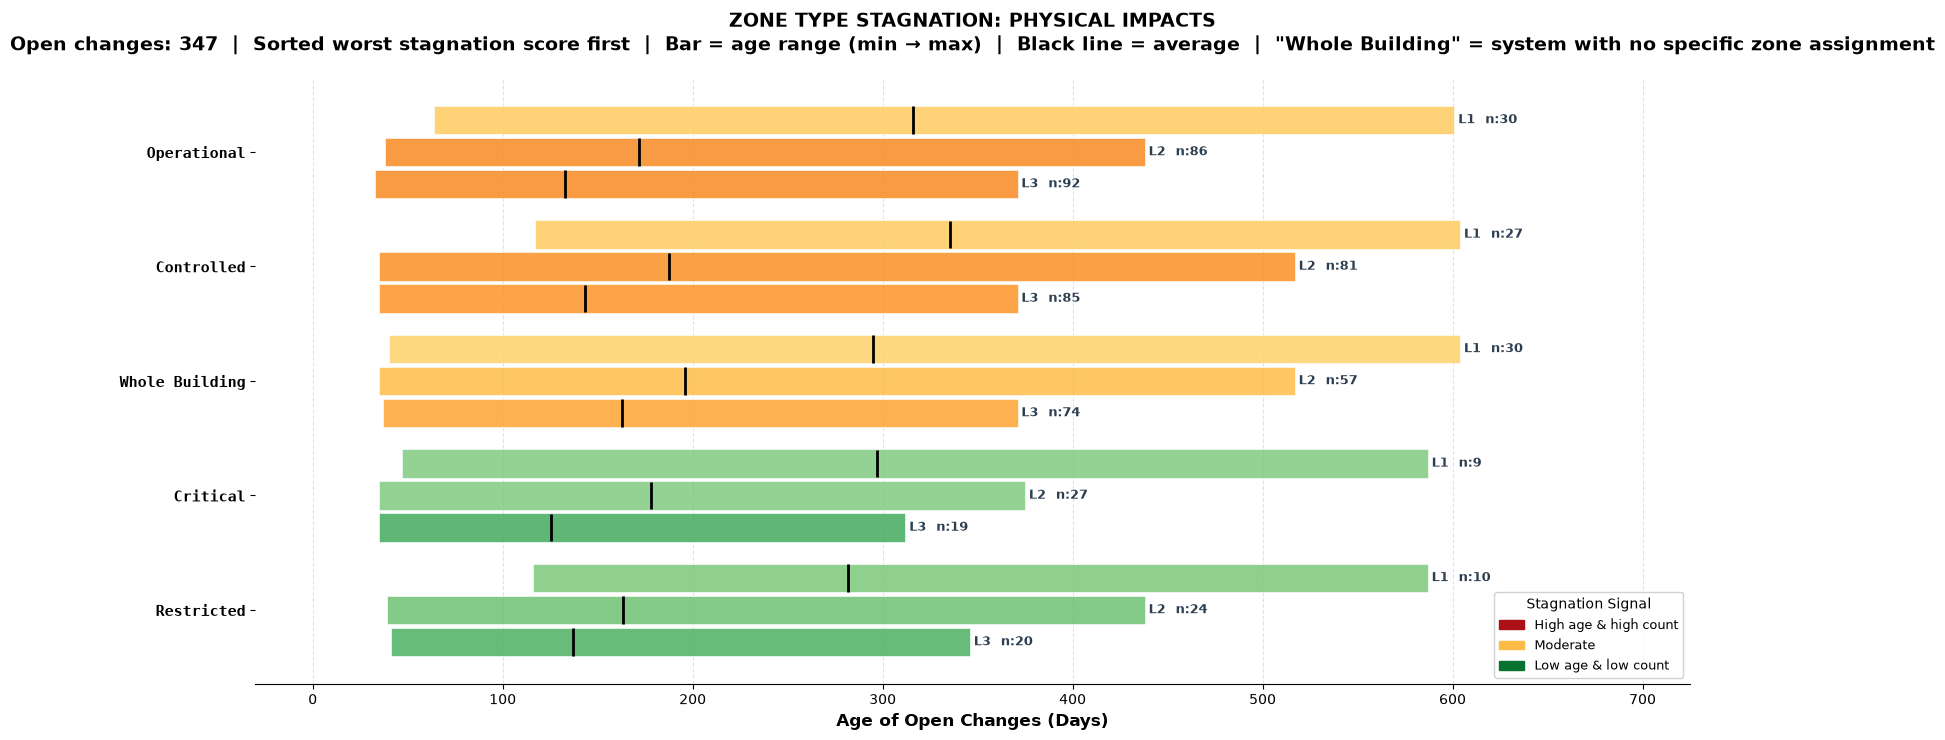

,Zone Type,Stagnation Score,Open Changes,Avg Age (d)
2,Operational,36450,208,207
0,Controlled,36401,193,222
4,Whole Building,32079,161,218
1,Critical,9870,55,200
3,Restricted,9474,54,194


wrote gold_zonetype_stagnation_non_physical      5 rows -> data/gold/gold_zonetype_stagnation_non_physical.parquet  (from: fact_location_exploded)


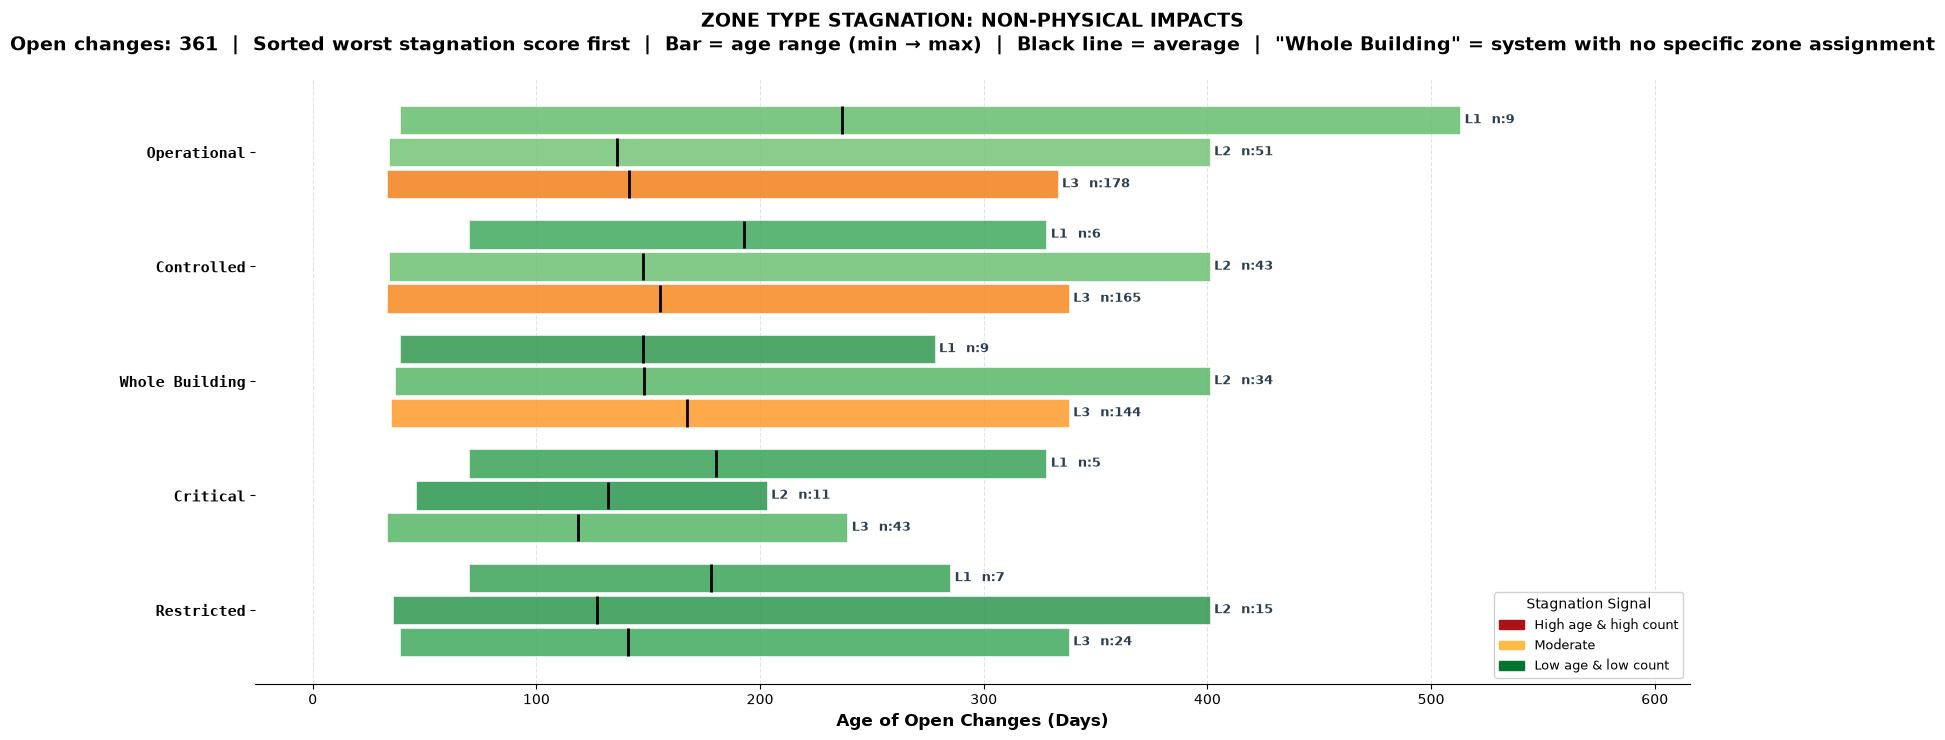

,Zone Type,Stagnation Score,Open Changes,Avg Age (d)
2,Operational,34219,238,171
0,Controlled,33102,214,165
4,Whole Building,30441,187,154
1,Critical,7458,59,144
3,Restricted,6536,46,149


In [22]:
# ==============================================================================
# CELL 19 — ZONE TYPE ANALYSIS
# Two charts mirroring the building analysis at zone type grain.
# No milestone grouping — zone types span multiple milestones.
#
# Chart 1: ZONE TYPE LEAD TIME (historical — closed changes)
#   - Days_to_Close per zone type × level
#   - Range bars min → max, black line = average
#   - Colour = relative performance within level (darkest red = slowest)
#   - Sorted worst average lead time first
#
# Chart 2: ZONE TYPE STAGNATION (current — open changes)
#   - Current_Age_Days per zone type × level
#   - Range bars min → max, black line = average
#   - Colour = age × count score (darkest red = worst stagnation)
#   - Sorted worst stagnation score first
#
# Grain reference:
#   df_closed_zonetypes    ChangeID × Zone_Type    closed changes only
#   df_active_zonetypes    ChangeID × Zone_Type    open changes only
#   Both deduplicated on ['ChangeID', 'Zone_Type'] before aggregation.
#   Whole-building assignments (Zone_ID = None) shown as 'Whole Building'.
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

import sys
sys.path.insert(0, str(ROOT / "src"))
from lineage import write_layer

# ── CONFIG ────────────────────────────────────────────────────────────────────
LEVEL_COLORS  = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}
level_offsets = {1: -0.28, 2: 0, 3: 0.28}

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '16px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

# ── COLOUR FUNCTIONS ──────────────────────────────────────────────────────────
def get_leadtime_color(avg_lt, min_lt, max_lt):
    """Min-max normalised within level. Best = darkest green, worst = darkest red."""
    rng   = max_lt - min_lt
    score = (avg_lt - min_lt) / rng if rng > 0 else 0.5
    if score >= 0.66:
        return plt.get_cmap('Reds')(0.4 + 0.6 * ((score - 0.66) / 0.34))
    elif score >= 0.33:
        return plt.get_cmap('YlOrBr')(0.4 * 0.6 + 0.6 * ((score - 0.33) / 0.33) * 0.6)
    else:
        return plt.get_cmap('Greens')(0.4 + 0.6 * (1 - (score / 0.33)))

def get_stagnation_color(avg_age, id_count, max_age, max_count):
    """Age × count score. High age + high count = darkest red."""
    age_ratio   = avg_age  / max_age   if max_age   > 0 else 0
    count_ratio = id_count / max_count if max_count > 0 else 0
    score       = (age_ratio + count_ratio) / 2
    if score >= 0.66:
        return plt.get_cmap('Reds')(0.4 + 0.6 * ((score - 0.66) / 0.34))
    elif score >= 0.33:
        return plt.get_cmap('YlOrBr')((0.4 + 0.6 * ((score - 0.33) / 0.33)) * 0.6)
    else:
        return plt.get_cmap('Greens')(0.4 + 0.6 * (1 - (score / 0.33)))


# ── SILVER TABLES ─────────────────────────────────────────────────────────────
# Deduplicate on ChangeID × Zone_Type to collapse zone fan-out.
# A change touching Restricted and Controlled zones counts once per type.
# Whole-building assignments (Zone_ID = None) have no Zone_Type — shown
# as 'Whole Building' rather than dropped.

df_zt_base = fact_location_exploded.copy()
df_zt_base['Zone_Type'] = df_zt_base['Zone_Type'].fillna('Whole Building')

df_closed_zonetypes = (
    df_zt_base[df_zt_base['Status'] == 'Closed']
    [['ChangeID', 'Level', 'Physical_Impacts', 'Zone_Type', 'Days_to_Close']]
    .drop_duplicates(['ChangeID', 'Zone_Type'])
    .copy()
)
df_closed_zonetypes['Level'] = pd.to_numeric(
    df_closed_zonetypes['Level'], errors='coerce'
).fillna(0).astype(int)

df_active_zonetypes = (
    df_zt_base[df_zt_base['Status'] != 'Closed']
    [['ChangeID', 'Level', 'Physical_Impacts', 'Zone_Type', 'Current_Age_Days']]
    .drop_duplicates(['ChangeID', 'Zone_Type'])
    .copy()
)
df_active_zonetypes['Level'] = pd.to_numeric(
    df_active_zonetypes['Level'], errors='coerce'
).fillna(0).astype(int)

print(f'✅ df_closed_zonetypes: {len(df_closed_zonetypes):,} rows | '
      f'{df_closed_zonetypes["ChangeID"].nunique():,} unique closed changes | '
      f'{df_closed_zonetypes["Zone_Type"].nunique()} zone types')
print(f'✅ df_active_zonetypes: {len(df_active_zonetypes):,} rows | '
      f'{df_active_zonetypes["ChangeID"].nunique():,} unique open changes | '
      f'{df_active_zonetypes["Zone_Type"].nunique()} zone types')


# ==============================================================================
# CHART 1 — ZONE TYPE LEAD TIME (historical)
# Grain: ChangeID × Zone_Type (closed) → aggregated to Zone_Type × Level
# ==============================================================================

def plot_zonetype_leadtime(df, impact_filter=None, title_suffix='ALL IMPACTS'):
    """
    Range bar chart of historical closure lead time per zone type × level.
    impact_filter: True = physical, False = non-physical, None = all
    """
    if impact_filter is not None:
        df = df[df['Physical_Impacts'] == impact_filter]

    df = df[df['Days_to_Close'].notna()]

    if df.empty:
        print(f'No closed data for {title_suffix}')
        return

    # Aggregate to zone type × level grain
    agg = (
        df.groupby(['Zone_Type', 'Level'])
        .agg(
            Closed_Count  = ('ChangeID',      'nunique'),
            Avg_Lead_Time = ('Days_to_Close', 'mean'),
            Min_Lead_Time = ('Days_to_Close', 'min'),
            Max_Lead_Time = ('Days_to_Close', 'max'),
        )
        .reset_index()
    )

    # Zone type summary for sort order
    zt_agg = (
        df.groupby('Zone_Type')
        .agg(
            Avg_Lead_Time = ('Days_to_Close', 'mean'),
            Closed_Count  = ('ChangeID',      'nunique'),
        )
        .reset_index()
        .sort_values('Avg_Lead_Time', ascending=False)
    )

    _suffix = "physical" if impact_filter is True else "non_physical" if impact_filter is False else "all"
    write_layer(zt_agg, f"gold_zonetype_leadtime_{_suffix}", ROOT / "data" / "gold",
                sources=["fact_location_exploded"])

    zonetype_order = zt_agg['Zone_Type'].tolist()
    n_zt           = len(zonetype_order)

    # Per-level min/max for normalised colouring
    level_ranges = {}
    for lvl, grp in agg.groupby('Level'):
        level_ranges[int(lvl)] = {
            'min_lt': float(grp['Avg_Lead_Time'].min()),
            'max_lt': float(grp['Avg_Lead_Time'].max()),
        }

    fig, ax = plt.subplots(figsize=(16, max(6, n_zt * 1.5)))

    for i, zt in enumerate(zonetype_order):
        zt_rows = agg[agg['Zone_Type'] == zt]
        for _, row in zt_rows.iterrows():
            lvl   = int(row['Level'])
            y_pos = i + level_offsets.get(lvl, 0)
            rng   = level_ranges.get(lvl, {})
            color = get_leadtime_color(
                float(row['Avg_Lead_Time']),
                float(rng.get('min_lt', 0)),
                float(rng.get('max_lt', 1)),
            )
            bar_width = max(2, row['Max_Lead_Time'] - row['Min_Lead_Time'])
            ax.barh(y_pos, bar_width, left=row['Min_Lead_Time'],
                    height=0.25, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, zorder=3)
            ax.vlines(row['Avg_Lead_Time'], y_pos - 0.12, y_pos + 0.12,
                      color='black', linewidth=2, zorder=5)
            ax.text(row['Max_Lead_Time'] + 2, y_pos,
                    f"L{lvl}  n:{int(row['Closed_Count'])}",
                    va='center', ha='left', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(n_zt))
    ax.set_yticklabels(zonetype_order, fontsize=11, fontweight='bold',
                       fontfamily='monospace')
    ax.invert_yaxis()
    ax.set_xlim(-agg['Max_Lead_Time'].max() * 0.05,
                 agg['Max_Lead_Time'].max() * 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Days to Close (Lead Time)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'ZONE TYPE LEAD TIME: {title_suffix}\n'
        f'Closed changes: {df["ChangeID"].nunique():,}  |  '
        f'Sorted worst average first  |  '
        f'Bar = range (min → max)  |  Black line = average  |  '
        f'"Whole Building" = system with no specific zone assignment',
        fontsize=14, fontweight='bold', pad=20
    )

    patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),   label='Slowest (within level)'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.4),  label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85), label='Fastest (within level)'),
    ]
    ax.legend(handles=patches, loc='lower right', framealpha=0.9,
              fontsize=9, title='Relative Performance')
    plt.tight_layout()
    plt.show()

    # Gold table
    display(
        zt_agg.rename(columns={
            'Zone_Type':    'Zone Type',
            'Avg_Lead_Time': 'Avg Lead Time (d)',
            'Closed_Count':  'Closed Changes',
        }).style
        .background_gradient(subset=['Avg Lead Time (d)'], cmap='RdYlGn_r', vmin=0)
        .set_caption(f'🥇 Zone Type Lead Time: {title_suffix}')
        .format({'Avg Lead Time (d)': '{:.0f}'})
        .set_table_styles(TABLE_STYLES)
    )


# ==============================================================================
# CHART 2 — ZONE TYPE STAGNATION (current)
# Grain: ChangeID × Zone_Type (open) → aggregated to Zone_Type × Level
# ==============================================================================

def plot_zonetype_stagnation(df, impact_filter=None, title_suffix='ALL IMPACTS'):
    """
    Range bar chart of current open change age per zone type × level.
    impact_filter: True = physical, False = non-physical, None = all
    """
    if impact_filter is not None:
        df = df[df['Physical_Impacts'] == impact_filter]

    df = df[df['Current_Age_Days'].notna()]

    if df.empty:
        print(f'No open data for {title_suffix}')
        return

    # Aggregate to zone type × level grain
    agg = (
        df.groupby(['Zone_Type', 'Level'])
        .agg(
            ID_Count = ('ChangeID',         'nunique'),
            Avg_Age  = ('Current_Age_Days', 'mean'),
            Min_Age  = ('Current_Age_Days', 'min'),
            Max_Age  = ('Current_Age_Days', 'max'),
        )
        .reset_index()
    )
    agg['Score'] = agg['Avg_Age'] * agg['ID_Count']

    # Zone type stagnation score for sort order
    zt_scores = (
        agg.groupby('Zone_Type')
        .agg(
            Total_Score = ('Score',    'sum'),
            Total_Open  = ('ID_Count', 'sum'),
            Avg_Age     = ('Avg_Age',  'mean'),
        )
        .reset_index()
        .sort_values('Total_Score', ascending=False)
    )

    _suffix = "physical" if impact_filter is True else "non_physical" if impact_filter is False else "all"
    write_layer(zt_scores, f"gold_zonetype_stagnation_{_suffix}", ROOT / "data" / "gold",
                sources=["fact_location_exploded"])

    zonetype_order = zt_scores['Zone_Type'].tolist()
    n_zt           = len(zonetype_order)
    max_age_glob   = float(agg['Max_Age'].max()) or 1
    max_count_glob = float(agg['ID_Count'].max()) or 1

    fig, ax = plt.subplots(figsize=(16, max(6, n_zt * 1.5)))

    for i, zt in enumerate(zonetype_order):
        zt_rows = agg[agg['Zone_Type'] == zt]
        for _, row in zt_rows.iterrows():
            lvl   = int(row['Level'])
            y_pos = i + level_offsets.get(lvl, 0)
            color = get_stagnation_color(
                float(row['Avg_Age']), float(row['ID_Count']),
                max_age_glob, max_count_glob
            )
            bar_width = max(2, row['Max_Age'] - row['Min_Age'])
            ax.barh(y_pos, bar_width, left=row['Min_Age'],
                    height=0.25, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, zorder=3)
            ax.vlines(row['Avg_Age'], y_pos - 0.12, y_pos + 0.12,
                      color='black', linewidth=2, zorder=5)
            ax.text(row['Max_Age'] + 2, y_pos,
                    f"L{lvl}  n:{int(row['ID_Count'])}",
                    va='center', ha='left', fontsize=9,
                    fontweight='bold', color='#2c3e50')

    ax.set_yticks(range(n_zt))
    ax.set_yticklabels(zonetype_order, fontsize=11, fontweight='bold',
                       fontfamily='monospace')
    ax.invert_yaxis()
    ax.set_xlim(-max_age_glob * 0.05, max_age_glob * 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Age of Open Changes (Days)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'ZONE TYPE STAGNATION: {title_suffix}\n'
        f'Open changes: {df["ChangeID"].nunique():,}  |  '
        f'Sorted worst stagnation score first  |  '
        f'Bar = age range (min → max)  |  Black line = average  |  '
        f'"Whole Building" = system with no specific zone assignment',
        fontsize=14, fontweight='bold', pad=20
    )

    patches = [
        mpatches.Patch(color=plt.get_cmap('Reds')(0.85),   label='High age & high count'),
        mpatches.Patch(color=plt.get_cmap('YlOrBr')(0.4),  label='Moderate'),
        mpatches.Patch(color=plt.get_cmap('Greens')(0.85), label='Low age & low count'),
    ]
    ax.legend(handles=patches, loc='lower right', framealpha=0.9,
              fontsize=9, title='Stagnation Signal')
    plt.tight_layout()
    plt.show()

    # Gold table
    display(
        zt_scores.rename(columns={
            'Zone_Type':    'Zone Type',
            'Total_Score':  'Stagnation Score',
            'Total_Open':   'Open Changes',
            'Avg_Age':      'Avg Age (d)',
        }).style
        .background_gradient(subset=['Stagnation Score'], cmap='RdYlGn_r')
        .set_caption(f'🥇 Zone Type Stagnation: {title_suffix}')
        .format({'Stagnation Score': '{:.0f}', 'Avg Age (d)': '{:.0f}'})
        .set_table_styles(TABLE_STYLES)
    )


# ── RUN ───────────────────────────────────────────────────────────────────────
print('\n── ZONE TYPE LEAD TIME ──────────────────────────────────────────────')
plot_zonetype_leadtime(df_closed_zonetypes, impact_filter=True,  title_suffix='PHYSICAL IMPACTS')
plot_zonetype_leadtime(df_closed_zonetypes, impact_filter=False, title_suffix='NON-PHYSICAL IMPACTS')

print('\n── ZONE TYPE STAGNATION ─────────────────────────────────────────────')
plot_zonetype_stagnation(df_active_zonetypes, impact_filter=True,  title_suffix='PHYSICAL IMPACTS')
plot_zonetype_stagnation(df_active_zonetypes, impact_filter=False, title_suffix='NON-PHYSICAL IMPACTS')

In [23]:
# ==============================================================================
# CELL 20 — ZONE TYPE READINESS WIDGET
#
# Dropdown with two views:
#   ALL ZONE TYPES  — horizontal RAG bars, readiness % per zone type
#   Single zone type — drilldown by level and physical/documentary split
#
# Grain reference:
#   df_readiness_zt    ChangeID × Zone_Type
#   Built from fact_location_exploded deduplicated on ['ChangeID', 'Zone_Type']
#   Whole-building assignments (Zone_Type = None) shown as 'Whole Building'
#   Is_Closed = 1 flag used for readiness % — sum(Is_Closed) / nunique(ChangeID)
# ==============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── 1. CONFIG ─────────────────────────────────────────────────────────────────
SIM_TODAY    = ts_sim_today
LEVEL_COLORS = {1: '#e74c3c', 2: '#f1c40f', 3: '#3498db'}
RAG_RED, RAG_AMBER = 80, 95

def get_rag_color(pct):
    if pct < RAG_RED:   return '#c0392b'
    if pct < RAG_AMBER: return '#f39c12'
    return                     '#1e8449'

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('font-size', '16px'), ('font-weight', 'bold'),
               ('color', '#b8860b'), ('padding', '10px 0')]},
    {'selector': 'th',
     'props': [('background-color', '#b8860b'), ('color', 'white'),
               ('font-weight', 'bold'), ('padding', '8px 12px'),
               ('border', '1px solid #a07800')]},
    {'selector': 'td',
     'props': [('padding', '6px 12px'), ('border', '1px solid #e8d88a')]},
]

# ── 2. DATA PREPARATION ───────────────────────────────────────────────────────
# Build df_readiness_zt directly from fact_location_exploded.
# Deduplicate on ChangeID × Zone_Type to collapse zone fan-out.
# A change touching Restricted + Controlled counts once per type — correct.
# Whole-building assignments (Zone_Type = None) shown as 'Whole Building'.

df_readiness_zt = (
    fact_location_exploded[
        ['ChangeID', 'Level', 'Physical_Impacts', 'Status', 'Zone_Type']
    ]
    .copy()
)

df_readiness_zt['Zone_Type'] = df_readiness_zt['Zone_Type'].fillna('Whole Building')
df_readiness_zt = df_readiness_zt.drop_duplicates(['ChangeID', 'Zone_Type'])
df_readiness_zt['Is_Closed'] = (df_readiness_zt['Status'] == 'Closed').astype(int)
df_readiness_zt['Level']     = pd.to_numeric(
    df_readiness_zt['Level'], errors='coerce'
).fillna(0).astype(int)

print(f"✅ df_readiness_zt: {len(df_readiness_zt):,} rows | "
      f"{df_readiness_zt['ChangeID'].nunique():,} unique changes | "
      f"{df_readiness_zt['Zone_Type'].nunique()} zone types")
print(f"   Zone types: {sorted(df_readiness_zt['Zone_Type'].unique().tolist())}")

# ── 3. WIDGET SETUP ───────────────────────────────────────────────────────────
zonetype_list    = sorted(df_readiness_zt['Zone_Type'].unique().tolist())
dropdown_options = ['ALL ZONE TYPES'] + zonetype_list

dropdown = widgets.Dropdown(
    options=dropdown_options,
    value='ALL ZONE TYPES',
    description='Zone Type:',
    style={'description_width': 'initial'},
    layout={'width': '350px'}
)
output = widgets.Output()

# ── 4. DASHBOARD LOGIC ────────────────────────────────────────────────────────
def update_dashboard(change):
    selected_scope = change['new']

    with output:
        clear_output(wait=True)

        if selected_scope == 'ALL ZONE TYPES':
            # ── VIEW A: ALL ZONE TYPES ─────────────────────────────────────
            summary = (
                df_readiness_zt
                .groupby('Zone_Type')
                .agg(
                    Total_Changes  = ('ChangeID',  'nunique'),
                    Closed_Changes = ('Is_Closed', 'sum')
                )
                .reset_index()
            )
            summary['Readiness_Pct'] = (
                summary['Closed_Changes'] / summary['Total_Changes'] * 100
            ).round(1)
            summary = summary.sort_values('Readiness_Pct', ascending=True)

            fig, ax = plt.subplots(figsize=(12, max(4, len(summary) * 0.8 + 2)))
            y_pos = np.arange(len(summary))

            ax.barh(y_pos, 100, color='#eeeeee', height=0.6, zorder=1)
            ax.barh(y_pos, summary['Readiness_Pct'],
                    color=[get_rag_color(p) for p in summary['Readiness_Pct']],
                    height=0.6, zorder=2)

            for i, (pct, total, closed) in enumerate(zip(
                summary['Readiness_Pct'],
                summary['Total_Changes'],
                summary['Closed_Changes']
            )):
                ax.text(pct + 1, i,
                        f"{pct}%  ({int(closed)}/{int(total)})",
                        va='center', fontweight='bold', fontsize=10)

            ax.set_yticks(y_pos)
            ax.set_yticklabels(summary['Zone_Type'],
                               fontfamily='monospace', fontsize=11)
            ax.set_xlim(0, 125)
            ax.set_xlabel('Readiness %', fontsize=11)
            ax.set_title(
                f'ZONE TYPE READINESS SUMMARY  |  {SIM_TODAY.date()}',
                fontsize=15, fontweight='bold', loc='left'
            )
            ax.text(0.99, 1.01,
                    f'Red < {RAG_RED}%  |  Amber {RAG_RED}–{RAG_AMBER}%  |  Green ≥ {RAG_AMBER}%  |  '
                    f'"Whole Building" = system with no specific zone assignment',
                    transform=ax.transAxes, ha='right',
                    fontsize=9, color='gray', style='italic')
            ax.grid(axis='x', linestyle=':', alpha=0.4)
            ax.spines[['top', 'right']].set_visible(False)
            plt.tight_layout()
            plt.show()

            group_cols = ['Zone_Type', 'Level', 'Physical_Impacts']

        else:
            # ── VIEW B: SINGLE ZONE TYPE DRILLDOWN ────────────────────────
            zt_data = df_readiness_zt[df_readiness_zt['Zone_Type'] == selected_scope]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

            # Readiness by level
            l_stats = (
                zt_data.groupby('Level')
                .agg(T=('ChangeID', 'nunique'), C=('Is_Closed', 'sum'))
                .reset_index()
            )
            l_stats['P'] = (l_stats['C'] / l_stats['T'] * 100).round(1)
            bars1 = ax1.bar(
                l_stats['Level'].astype(str), l_stats['P'],
                color=[LEVEL_COLORS.get(l, '#7f8c8d') for l in l_stats['Level']]
            )
            ax1.set_ylim(0, 115)
            ax1.set_title('Readiness by Priority Level', fontweight='bold')
            ax1.set_xlabel('Level')
            ax1.set_ylabel('Readiness %')
            for bar in bars1:
                ax1.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 2,
                         f'{bar.get_height():.0f}%',
                         ha='center', fontweight='bold', fontsize=10)

            # Readiness by impact type
            i_stats = (
                zt_data.groupby('Physical_Impacts')
                .agg(T=('ChangeID', 'nunique'), C=('Is_Closed', 'sum'))
                .reset_index()
            )
            
            i_stats['P']     = (i_stats['C'] / i_stats['T'] * 100).round(1)
            i_stats['Physical_Impacts'] = i_stats['Physical_Impacts'].astype(int)
            i_stats['Label'] = i_stats['Physical_Impacts'].map(
                {1: 'Physical', 0: 'Documentary'}
            )
            bars2 = ax2.bar(
                i_stats['Label'], i_stats['P'],
                color=['#34495e', '#95a5a6']
            )
            ax2.set_ylim(0, 115)
            ax2.set_title('Physical vs Documentary', fontweight='bold')
            ax2.set_ylabel('Readiness %')
            for bar in bars2:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 2,
                         f'{bar.get_height():.0f}%',
                         ha='center', fontweight='bold', fontsize=10)

            plt.suptitle(
                f'DRILL-DOWN: {selected_scope}  |  {SIM_TODAY.date()}',
                fontsize=14, fontweight='bold', y=1.02
            )
            plt.tight_layout()
            plt.show()

            group_cols = ['Level', 'Physical_Impacts']

        # ── SHARED TABLE ──────────────────────────────────────────────────
        data = (
            df_readiness_zt if selected_scope == 'ALL ZONE TYPES'
            else df_readiness_zt[df_readiness_zt['Zone_Type'] == selected_scope]
        )
        table = (
            data.groupby(group_cols)
            .agg(Total=('ChangeID', 'nunique'), Closed=('Is_Closed', 'sum'))
            .reset_index()
        )
        table['Open']    = table['Total'] - table['Closed']
        table['Ready %'] = (table['Closed'] / table['Total'] * 100).round(1)

        if 'Physical_Impacts' in table.columns:
            table['Physical_Impacts'] = table['Physical_Impacts'].map(
                {1: 'Physical', 0: 'Documentary'}
            )

        display(
            table.style
                .background_gradient(subset=['Ready %'], cmap='RdYlGn', vmin=70, vmax=100)
                .set_caption(f'Zone Type Readiness Detail: {selected_scope}  |  '
                             f'Total changes: {data["ChangeID"].nunique():,}')
                .format({'Ready %': '{:.1f}%'})
                .set_table_styles(TABLE_STYLES)
        )


# ── 5. EXECUTION ──────────────────────────────────────────────────────────────
dropdown.observe(update_dashboard, names='value')
display(widgets.VBox([dropdown, output]))
update_dashboard({'new': dropdown.value})

✅ df_readiness_zt: 26,536 rows | 15,000 unique changes | 5 zone types
   Zone types: ['Controlled', 'Critical', 'Operational', 'Restricted', 'Whole Building']


In [24]:
# ==============================================================================
# FINAL CELL — REGENERATE LINEAGE VIEWER
#
# Refreshes docs/lineage.html from whatever's currently in data/{bronze,silver,gold}/.
# Runs every time this notebook is executed top to bottom, so the lineage page
# never goes stale relative to the tables this run just built.
# ==============================================================================

from lineage import read_lineage, render_html

_manifests = read_lineage(ROOT / "data")
_html = render_html(_manifests, ROOT.name)
(ROOT / "docs" / "lineage.html").write_text(_html)
print(f"lineage viewer updated: {len(_manifests)} tables -> docs/lineage.html")


lineage viewer updated: 26 tables -> docs/lineage.html
